# 🎬 Movies Dataset — Insights

This notebook builds the **insights part** on top of the EDA + preprocessing notebook.

**How it is organised**
- **Section 0–1:** setup and loading.
- **Section 2 (⭐ EXTRA):** extra cells added to make the insights trustworthy (early de-duplication, cleaning for insights, a vote-count reliability filter, a corrected correlation heatmap). Every extra cell starts with a comment saying so.
- **Section 3:** insights A (ratings & quality), B (money), C (people), D (content & audience), E (genre chemistry & creative views).
- **Section 4:** key findings summary.

Every insight has a chart/table cell followed by a short written takeaway.

## 0) Setup

In [ ]:
# ======================================================================
# Import the libraries, set plot style, and define one small helper:
# explode_list() splits a comma-separated column (genres, cast, keywords...)
# into one row per item, so each item can be counted on its own.
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from itertools import combinations
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 50)

def explode_list(frame, col, new_name):
    out = frame.copy()
    out[new_name] = out[col].str.split(", ")
    return out.explode(new_name).dropna(subset=[new_name])


## 1) Load

In [ ]:
# ======================================================================
# Read the CSV (change the path if the file is stored somewhere else).
# ======================================================================
df_raw = pd.read_csv("df_sampled.csv")
print("Shape:", df_raw.shape)
df_raw.head(5)


Shape: (49994, 29)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,tconst,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,44341,Life of an American Fireman,6.123,106,Released,1903-01-21,0,6,False,/nMRJjCTrwvtzEYGLuQTtph3jXqu.jpg,0,NaN,tt0000447,en,Life of an American Fireman,Porter's sequential continuity editing links s...,4.403,/fEGJ6hwsjwB844f9CMRjzHjZF0P.jpg,NaN,Action,Edison Studios,United States of America,"English, No Language",NaN,"George S. Fleming, Edwin S. Porter",Edwin S. Porter,6.4,3019,"Vivian Vaughan, Arthur White"
1,179546,Attack on a China Mission,5.100,23,Released,1900-11-01,0,1,False,NaN,0,NaN,tt0000273,en,Attack on a China Mission,The titles tell us this film is based on an in...,1.895,/2zzTE2p1tEAQmy9ppYP2Da10nQF.jpg,NaN,"Action, Drama, History, War",Williamson Kinematograph Company,United Kingdom,No Language,"based on true story, silent film",James Williamson,James Williamson,5.5,790,"Mr. James, Mr. Lepard, Florence Williamson"
2,76951,Tarzan of the Apes,5.200,19,Released,1918-01-27,0,60,False,/k6pIZczOD0u8K8Scow1aqFiLmhM.jpg,0,NaN,tt0009682,en,Tarzan of the Apes,A female ape takes to mothering the orphaned b...,3.426,/jj7Jjd4Q4LaKXmhmprxumesSLbn.jpg,Tarzan did not know why he caressed her... He ...,"Action, Adventure",National Film Corporation of America,United States of America,No Language,"tarzan, silent film",Scott Sidney,"Edgar Rice Burroughs, Fred Miller, Lois Weber",5.8,1021,"Elmo Lincoln, Enid Markey, Gordon Griffith, Tr..."
3,115012,The Grey Automobile,6.400,13,Released,1919-12-11,0,223,False,/m2TEji8noA3fge4mOsDOO9TV608.jpg,0,NaN,tt0009894,es,El automóvil gris,A gang terrorizes Mexico City's high society o...,1.401,/xXhWCA2sCrqhbKoWCnhMrBy7if4.jpg,Admire the new fully spoken version. A true hi...,"Action, Crime",NaN,Mexico,No Language,NaN,Enrique Rosas,"Juan Manuel Cabrera, Miguel Necoechea, José Ma...",7.1,268,"Joaquín Coss, Juan de Homs, Manuel de los Ríos..."
4,193902,The Massacre,6.100,18,Released,1912-12-19,0,30,False,/aKDjgoczgS1dN0FUKOVQKhKVAEm.jpg,0,NaN,tt0002350,en,The Massacre,The story of the massacre of an Indian village...,1.302,/uEY2zLoDMThiwdtVQVRgrQjPHGE.jpg,A TRAGI-DRAMA OF AMERICA'S PAST IN TWO UNFORGE...,"Action, War, Western",American Mutoscope & Biograph,United States of America,No Language,"indian territory, tragedy, attack, massacre, s...",D.W. Griffith,D.W. Griffith,6.4,402,"Wilfred Lucas, Blanche Sweet, Charles West, Al..."


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49994 entries, 0 to 49993
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    49994 non-null  int64  
 1   title                 49994 non-null  object 
 2   vote_average          49994 non-null  float64
 3   vote_count            49994 non-null  int64  
 4   status                49994 non-null  object 
 5   release_date          49994 non-null  object 
 6   revenue               49994 non-null  int64  
 7   runtime               49994 non-null  int64  
 8   adult                 49994 non-null  bool   
 9   backdrop_path         45969 non-null  object 
 10  budget                49994 non-null  int64  
 11  homepage              10951 non-null  object 
 12  tconst                49994 non-null  object 
 13  original_language     49994 non-null  object 
 14  original_title        49994 non-null  object 
 15  overview           

In [ ]:
# ======================================================================
# Summary statistics for the numeric columns (mean, std, min, max,
# quartiles). We look at min/max to spot odd values (e.g. runtime = 0 or
# budget/revenue = 0) and at the gap between mean and median, which
# hints at skewness.
# ======================================================================
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
id,49994.0,2.223601e+05,2.498491e+05,2.000,37512.250,93913.000,372213.000,1.181678e+06
vote_average,49994.0,6.155084e+00,1.003589e+00,1.179,5.564,6.235,6.850,1.000000e+01
vote_count,49994.0,2.997741e+02,1.255417e+03,11.000,18.000,35.000,111.000,3.449500e+04
revenue,49994.0,1.031398e+07,6.505195e+07,0.000,0.000,0.000,0.000,2.923706e+09
runtime,49994.0,9.455901e+01,3.179117e+01,0.000,86.000,95.000,107.000,9.600000e+02
budget,49994.0,3.893541e+06,1.706818e+07,0.000,0.000,0.000,0.000,4.600000e+08
popularity,49994.0,8.253250e+00,2.660725e+01,0.600,2.625,4.543,8.842,2.680593e+03
averageRating,49994.0,6.132086e+00,1.187769e+00,1.000,5.500,6.300,7.000,9.600000e+00
numVotes,49994.0,1.789422e+04,8.379895e+04,6.000,775.000,1797.000,5776.500,3.232666e+06


## 2) Data Quality Checks

,missing_count,missing_%
homepage,39043,78.10
tagline,25714,51.43
keywords,12986,25.98
production_companies,4775,9.55
backdrop_path,4025,8.05
writers,1845,3.69
production_countries,1682,3.36
spoken_languages,606,1.21
poster_path,148,0.30


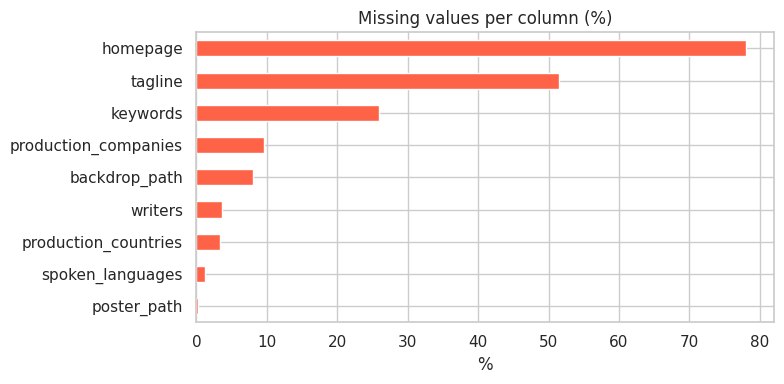

In [ ]:
# ======================================================================
# Count missing values (NaN) in each column along with their percentage,
# and plot them to see which columns need handling.
# ======================================================================
missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)

display(pd.DataFrame({"missing_count": missing, "missing_%": missing_pct}))

plt.figure(figsize=(8, 4))
missing_pct.sort_values().plot(kind="barh", color="tomato")
plt.title("Missing values per column (%)")
plt.xlabel("%")
plt.tight_layout()
plt.show()

In [ ]:
# ======================================================================
# Look for "hidden" missing values that are not NaN but really mean
# "no data": budget / revenue / runtime equal to 0. We also check for
# duplicated movies (by full row, IMDb id, and TMDB id).
# ======================================================================
for c in ["budget", "revenue", "runtime"]:
    zeros = (df_raw[c] == 0).sum()
    print(f"{c:8s} -> zeros: {zeros:6d} ({zeros / len(df_raw) * 100:.1f}%)")

print()
print("Full duplicate rows      :", df_raw.duplicated().sum())
print("Duplicate tconst (IMDb)  :", df_raw["tconst"].duplicated().sum())
print("Duplicate id (TMDB)      :", df_raw["id"].duplicated().sum())

budget   -> zeros:  39643 (79.3%)
revenue  -> zeros:  40316 (80.6%)
runtime  -> zeros:    279 (0.6%)

Full duplicate rows      : 0
Duplicate tconst (IMDb)  : 66
Duplicate id (TMDB)      : 66


## 3) EDA

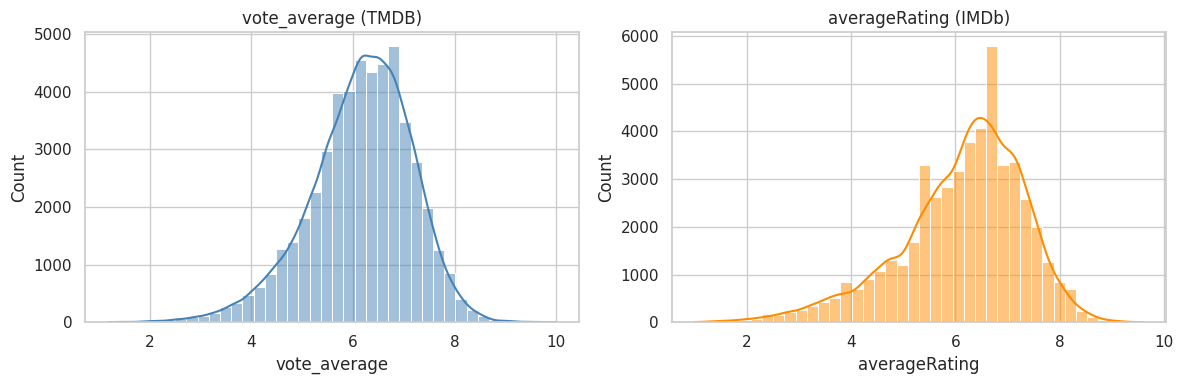

In [ ]:
# ======================================================================
# Plot the distribution of the two ratings in the data:
# vote_average (from TMDB) and averageRating (from IMDb).
# Both look roughly normal and are centered around 6.
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_raw["vote_average"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("vote_average (TMDB)")

sns.histplot(df_raw["averageRating"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("averageRating (IMDb)")

plt.tight_layout()
plt.show()

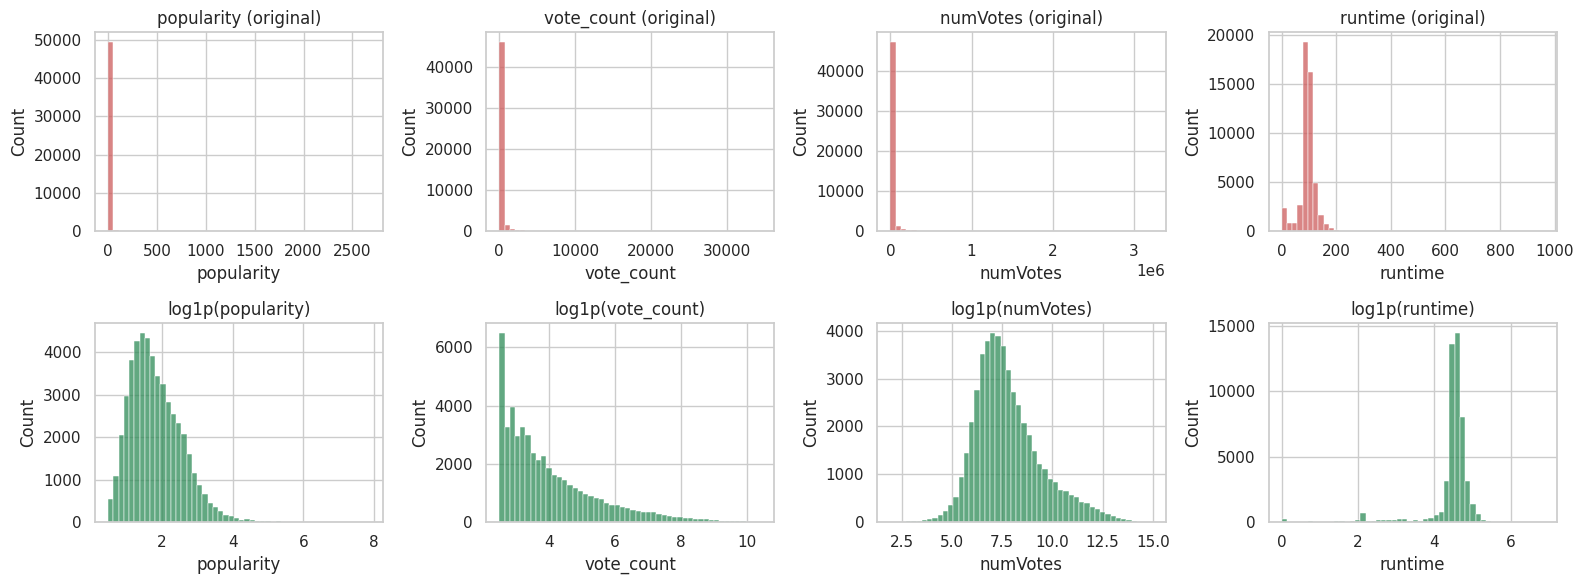

In [ ]:
# ======================================================================
# Compare the original distribution (top row) with the log1p-transformed
# one (bottom row) for highly skewed columns. If the original is piled up
# on the left with a long right tail, the log makes it much closer to a
# normal shape, which we will use in the preprocessing section.
# ======================================================================
skewed_cols = ["popularity", "vote_count", "numVotes", "runtime"]

fig, axes = plt.subplots(2, len(skewed_cols), figsize=(16, 6))
for i, c in enumerate(skewed_cols):
    sns.histplot(df_raw[c], bins=50, ax=axes[0, i], color="indianred")
    axes[0, i].set_title(f"{c} (original)")
    sns.histplot(np.log1p(df_raw[c]), bins=50, ax=axes[1, i], color="seagreen")
    axes[1, i].set_title(f"log1p({c})")

plt.tight_layout()
plt.show()

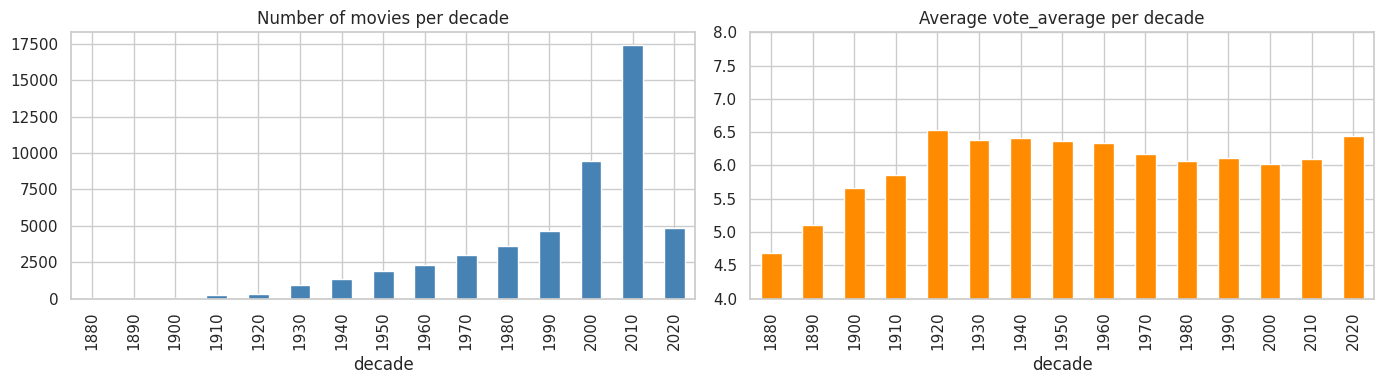

In [ ]:
# ======================================================================
# Show the number of movies per decade and the average rating per decade.
# We first convert release_date to a real datetime, then derive the
# decade. This shows that most movies are recent and that the average
# rating changes over time.
# ======================================================================
tmp = df_raw.copy()
tmp["release_date"] = pd.to_datetime(tmp["release_date"], errors="coerce")
tmp["decade"] = (tmp["release_date"].dt.year // 10 * 10).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tmp["decade"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Number of movies per decade")
axes[0].set_xlabel("decade")

tmp.groupby("decade")["vote_average"].mean().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Average vote_average per decade")
axes[1].set_xlabel("decade")
axes[1].set_ylim(4, 8)

plt.tight_layout()
plt.show()

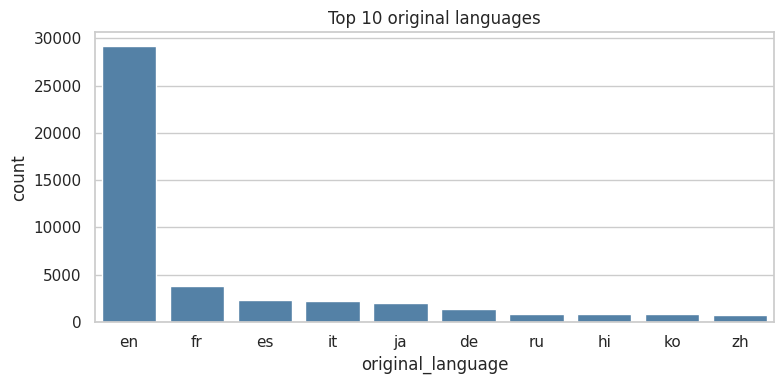

English share: 58.4%


In [ ]:
# ======================================================================
# Show the top 10 original languages of the movies. English clearly
# dominates, so in preprocessing we will group the remaining languages
# into an "other" category.
# ======================================================================
top_lang = df_raw["original_language"].value_counts().head(10)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_lang.index, y=top_lang.values, color="steelblue")
plt.title("Top 10 original languages")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print(f"English share: {(df_raw['original_language'] == 'en').mean() * 100:.1f}%")

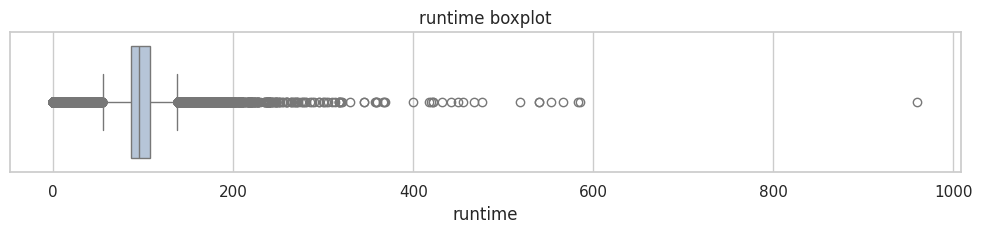

0.010      4.0
0.050     21.0
0.500     95.0
0.950    139.0
0.990    177.0
0.995    192.0
Name: runtime, dtype: float64
Movies with runtime > 300: 40


In [ ]:
# ======================================================================
# Take a closer look at runtime, because it contains impossible values
# (0 minutes) and extreme ones (up to 960 minutes). We draw a boxplot and
# print quantiles to decide where to clip the extreme values.
# ======================================================================
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=df_raw["runtime"], color="lightsteelblue")
plt.title("runtime boxplot")
plt.tight_layout()
plt.show()

print(df_raw["runtime"].quantile([0.01, 0.05, 0.5, 0.95, 0.99, 0.995]))
print("Movies with runtime > 300:", (df_raw["runtime"] > 300).sum())

### 📝 EDA Summary
- The data is **TMDB movies merged with IMDb**, and it contains **66 duplicated rows** (same `tconst` / `id`).
- `status` has a single value (Released) → a useless column.
- About **80% of `budget` and `revenue` are zero** (meaning "not recorded", not a real zero budget).
- `runtime` has 279 rows equal to 0 and extreme values (up to 960 minutes).
- `popularity`, `vote_count`, `numVotes`, `budget` and `revenue` are **highly skewed** → they need a log transform.
- Several text columns hold multiple values (genres, cast, keywords...) → we turn them into numeric features.
- Columns like `backdrop_path`, `poster_path` and `homepage` only matter as "exists or not".

## 2) ⭐ EXTRA — Preparing the data for insights
These cells were **not** in the original notebook. They fix the issues found when reviewing it:
duplicates, fake zeros in budget/revenue/runtime, short films, ratings based on very few votes, and a heatmap distorted by zeros.

In [ ]:
# ======================================================================
# ⭐ EXTRA: this cell was added on top of the original EDA notebook (not part of the first version).
#
# Remove duplicated movies EARLY (same tconst / IMDb id), so every count and
# average in the insights uses the same clean set of movies.
# ======================================================================
df = df_raw.drop_duplicates(subset="tconst", keep="first").reset_index(drop=True)
print("Before:", df_raw.shape, "-> After:", df.shape)


Before: (49994, 29) -> After: (49928, 29)


In [ ]:
# ======================================================================
# ⭐ EXTRA: this cell was added on top of the original EDA notebook (not part of the first version).
#
# Build df_ins, the dataframe used for ALL insights.
# Unlike df_model in the original notebook, it keeps titles, directors, cast, genres
# and keywords. It also does NOT impute anything:
#  - runtime = 0 -> NaN (impossible value)
#  - budget / revenue below 1,000 (including 0) -> NaN (not recorded, or an entry error)
#  - is_short flag for movies under 40 minutes (shorts behave differently from films)
#  - release_year, decade, and has_tagline / has_homepage flags
# ======================================================================
MIN_MONEY = 1000     # budget / revenue below this is treated as missing
SHORT_LIMIT = 40     # minutes; below this we call it a short film

df_ins = df.copy()
df_ins["release_date"] = pd.to_datetime(df_ins["release_date"], errors="coerce")
df_ins["release_year"] = df_ins["release_date"].dt.year
df_ins["decade"] = (df_ins["release_year"] // 10 * 10).astype(int)

df_ins["runtime"] = df_ins["runtime"].replace(0, np.nan)
for c in ["budget", "revenue"]:
    df_ins[c] = df_ins[c].where(df_ins[c] >= MIN_MONEY)

df_ins["is_short"] = df_ins["runtime"] < SHORT_LIMIT
df_ins["has_tagline"] = df_ins["tagline"].notna()
df_ins["has_homepage"] = df_ins["homepage"].notna()
df_ins["n_cast"] = df_ins["cast"].str.split(", ").str.len().fillna(0).astype(int)

print("Movies                   :", len(df_ins))
print("With a usable budget     :", df_ins["budget"].notna().sum())
print("With a usable revenue    :", df_ins["revenue"].notna().sum())
print("With both budget+revenue :", (df_ins["budget"].notna() & df_ins["revenue"].notna()).sum())
print("Short films (<40 min)    :", df_ins["is_short"].sum())


Movies                   : 49928
With a usable budget     : 10168
With a usable revenue    : 9563
With both budget+revenue : 6490
Short films (<40 min)    : 2903


,n_movies,mean_rating,median_rating
vote_bucket,,,
<20,14740,5.89,6.00
20-49,14949,6.07,6.20
50-99,6921,6.21,6.30
100-499,8551,6.41,6.46
500+,4767,6.71,6.72


df_rel (vote_count >= 100): 13318 movies (27% of the data)


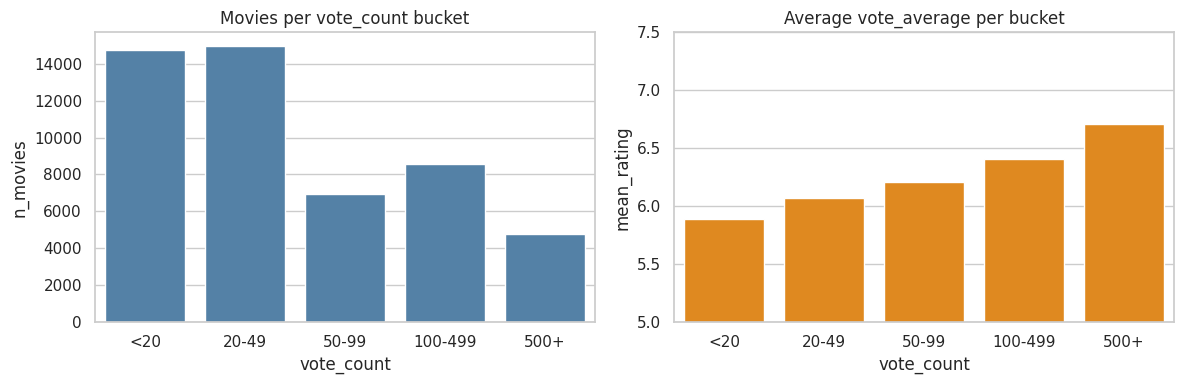

In [ ]:
# ======================================================================
# ⭐ EXTRA: this cell was added on top of the original EDA notebook (not part of the first version).
#
# Check how reliable the ratings are. A rating built on 11 votes is not the same as
# one built on 5,000 votes. We group movies by vote_count and compare their average
# rating, then define df_rel = movies with at least MIN_VOTES votes.
# Rating-based insights use df_rel; popularity/vote-based insights use df_ins.
# ======================================================================
bins = [0, 20, 50, 100, 500, np.inf]
labels = ["<20", "20-49", "50-99", "100-499", "500+"]
df_ins["vote_bucket"] = pd.cut(df_ins["vote_count"], bins=bins, labels=labels, right=False)

vote_tbl = df_ins.groupby("vote_bucket", observed=True).agg(
    n_movies=("id", "count"), mean_rating=("vote_average", "mean"), median_rating=("vote_average", "median"))
display(vote_tbl.round(2))

MIN_VOTES = 100
df_rel = df_ins[df_ins["vote_count"] >= MIN_VOTES].copy()
print(f"df_rel (vote_count >= {MIN_VOTES}): {len(df_rel)} movies ({len(df_rel)/len(df_ins)*100:.0f}% of the data)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=vote_tbl.index.astype(str), y=vote_tbl["n_movies"], color="steelblue", ax=axes[0])
axes[0].set_title("Movies per vote_count bucket"); axes[0].set_xlabel("vote_count")
sns.barplot(x=vote_tbl.index.astype(str), y=vote_tbl["mean_rating"], color="darkorange", ax=axes[1])
axes[1].set_title("Average vote_average per bucket"); axes[1].set_xlabel("vote_count"); axes[1].set_ylim(5, 7.5)
plt.tight_layout(); plt.show()


> 💡 **Insight (⭐ extra).** Ratings are not equally trustworthy: **59% of movies have fewer than 50 votes**, and the average rating rises steadily with the vote count, from **5.89** (under 20 votes) to **6.71** (500+ votes). Keeping only movies with at least 100 votes leaves **13,318 movies (27%)**. All rating-based insights below use this reliable set.

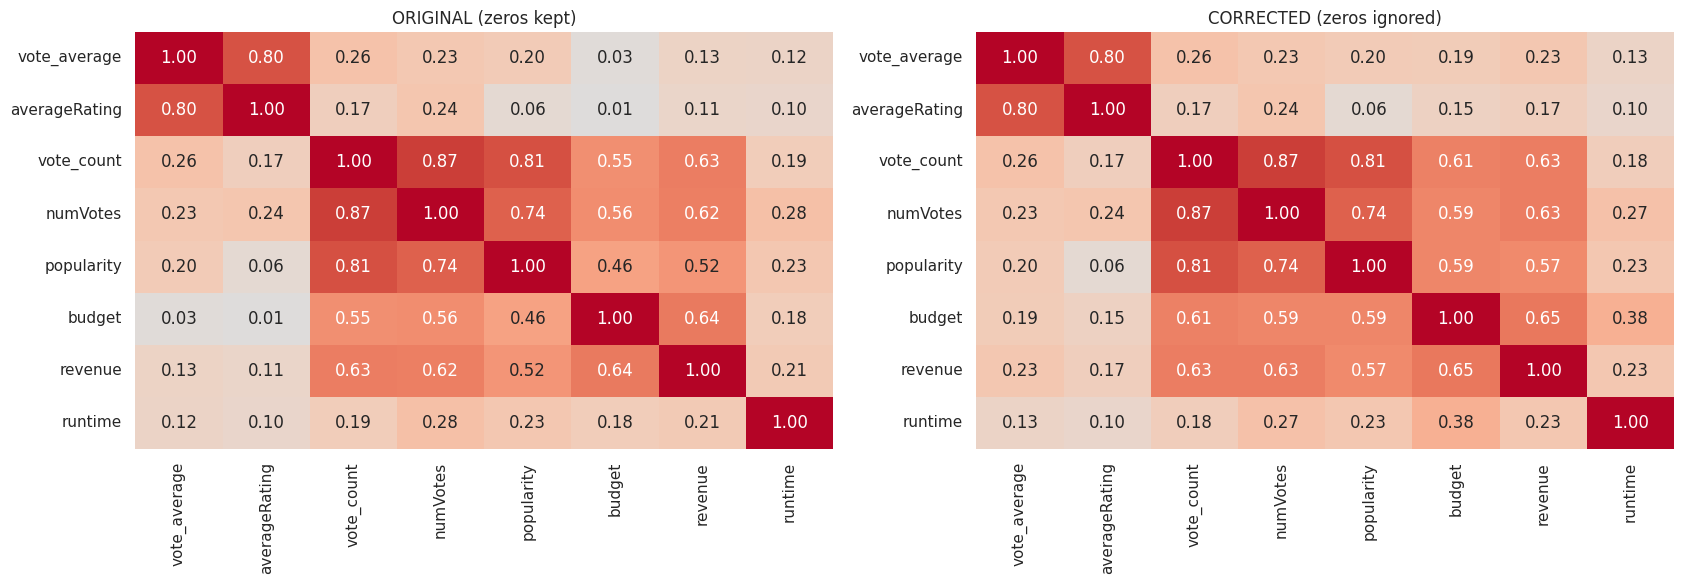

budget vs vote_average : old 0.03 -> new 0.19
budget vs revenue      : old 0.64 -> new 0.65
revenue vs vote_average: old 0.13 -> new 0.23


In [ ]:
# ======================================================================
# ⭐ EXTRA: this cell was added on top of the original EDA notebook (not part of the first version).
#
# Corrected correlation heatmap. In the original heatmap, budget and revenue zeros
# (= 'not recorded') were log-transformed as if they were real values, which hides
# the real relationships. Here we compare the ORIGINAL way (left) with the CORRECTED way
# (right), where missing money values stay NaN and are ignored by the correlation.
# ======================================================================
cols = ["vote_average", "averageRating", "vote_count", "numVotes", "popularity", "budget", "revenue", "runtime"]
log_cols_h = ["vote_count", "numVotes", "popularity", "budget", "revenue"]

def corr_matrix(frame):
    x = frame[cols].copy()
    for c in log_cols_h:
        x[c] = np.log1p(x[c])
    return x.corr()

corr_old = corr_matrix(df)       # zeros kept as zeros
corr_new = corr_matrix(df_ins)   # zeros / tiny values are NaN

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(corr_old, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], cbar=False)
axes[0].set_title("ORIGINAL (zeros kept)")
sns.heatmap(corr_new, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1], cbar=False)
axes[1].set_title("CORRECTED (zeros ignored)")
plt.tight_layout(); plt.show()

print("budget vs vote_average : old %.2f -> new %.2f" % (corr_old.loc["budget", "vote_average"], corr_new.loc["budget", "vote_average"]))
print("budget vs revenue      : old %.2f -> new %.2f" % (corr_old.loc["budget", "revenue"], corr_new.loc["budget", "revenue"]))
print("revenue vs vote_average: old %.2f -> new %.2f" % (corr_old.loc["revenue", "vote_average"], corr_new.loc["revenue", "vote_average"]))


> 💡 **Insight (⭐ extra).** Treating "not recorded" zeros as real values hid the relationships that involve ratings: budget vs rating went from **0.03 to 0.19** and revenue vs rating from **0.13 to 0.23** once zeros were ignored. Budget vs revenue barely changed (0.64 → 0.65) because both columns are zero together. Note that the 0.19 is on *all* movies; among movies with 100+ votes the link between budget and rating disappears (see B5).

In [ ]:
# ======================================================================
# ⭐ EXTRA: this cell was added on top of the original EDA notebook (not part of the first version).
#
# Short films and suspicious money values.
# 1) Compare short films (<40 min) with normal films.
# 2) Count budgets / revenues between 1 and 999 (almost certainly entry errors)
#    and look at a few examples.
# ======================================================================
cmp_short = df_ins.groupby("is_short").agg(
    n=("id", "count"), mean_rating=("vote_average", "mean"),
    median_votes=("vote_count", "median"), median_runtime=("runtime", "median"))
display(cmp_short.round(2))

tiny_b = df[(df["budget"] > 0) & (df["budget"] < MIN_MONEY)]
tiny_r = df[(df["revenue"] > 0) & (df["revenue"] < MIN_MONEY)]
print("Budgets between 1 and 999  :", len(tiny_b))
print("Revenues between 1 and 999 :", len(tiny_r))
display(tiny_b[["title", "release_date", "budget", "revenue"]].head(8))


,n,mean_rating,median_votes,median_runtime
is_short,,,,
False,47025,6.14,36.0,96.0
True,2903,6.39,23.0,11.0


Budgets between 1 and 999  : 179
Revenues between 1 and 999 : 115


,title,release_date,budget,revenue
178,Samurai Wolf,1966-11-19,74,0
1064,Mother's Day,1980-09-19,150,0
1207,The Immortals,1995-10-05,50,83
1288,The Shooter,1995-12-15,11,0
1293,Blade of Fury,1993-07-15,100,100
1356,Angel Town,1990-02-23,855,855810
1574,City Slickers II: The Legend of Curly's Gold,1994-06-10,40,43
1597,Kickboxer 2: The Road Back,1991-01-30,89,1250712


> 💡 **Insight (⭐ extra).** There are **2,903 short films** (median runtime 11 minutes). They get fewer votes (median 23 vs 36) and a higher average rating (6.39 vs 6.14), so they would distort runtime comparisons, which is why they are excluded from A4. Also, **179 budgets and 115 revenues are between 1 and 999 dollars** (for example a budget of $74), which are clearly entry errors and would create absurd return-on-investment values.

> ⭐ **EXTRA note — leakage.** `averageRating` was already removed from the model features in the original notebook. Be aware that `vote_count`, `numVotes`, `popularity` and `revenue` are also **results** of a movie's success, not things known before release. If the goal is to *predict* `vote_average`, consider dropping them too. For these insights (which describe the data, not predict) it is not a problem.

## 3) Insights

### A. Ratings and quality
_All rating insights use `df_rel` (movies with at least 100 votes)._

,n,mean_rating,std_rating,median_popularity,median_votes
genre,,,,,
Documentary,348,7.24,0.65,8.12,181.5
Animation,1120,7.01,0.68,16.87,331.0
History,623,6.98,0.62,12.56,299.0
War,425,6.97,0.68,13.07,329.0
Music,437,6.89,0.72,11.83,273.0
Drama,5844,6.75,0.73,12.01,294.0
TV Movie,276,6.67,0.78,10.72,189.5
Western,224,6.65,0.71,13.42,246.0
Romance,2121,6.62,0.74,12.37,307.0


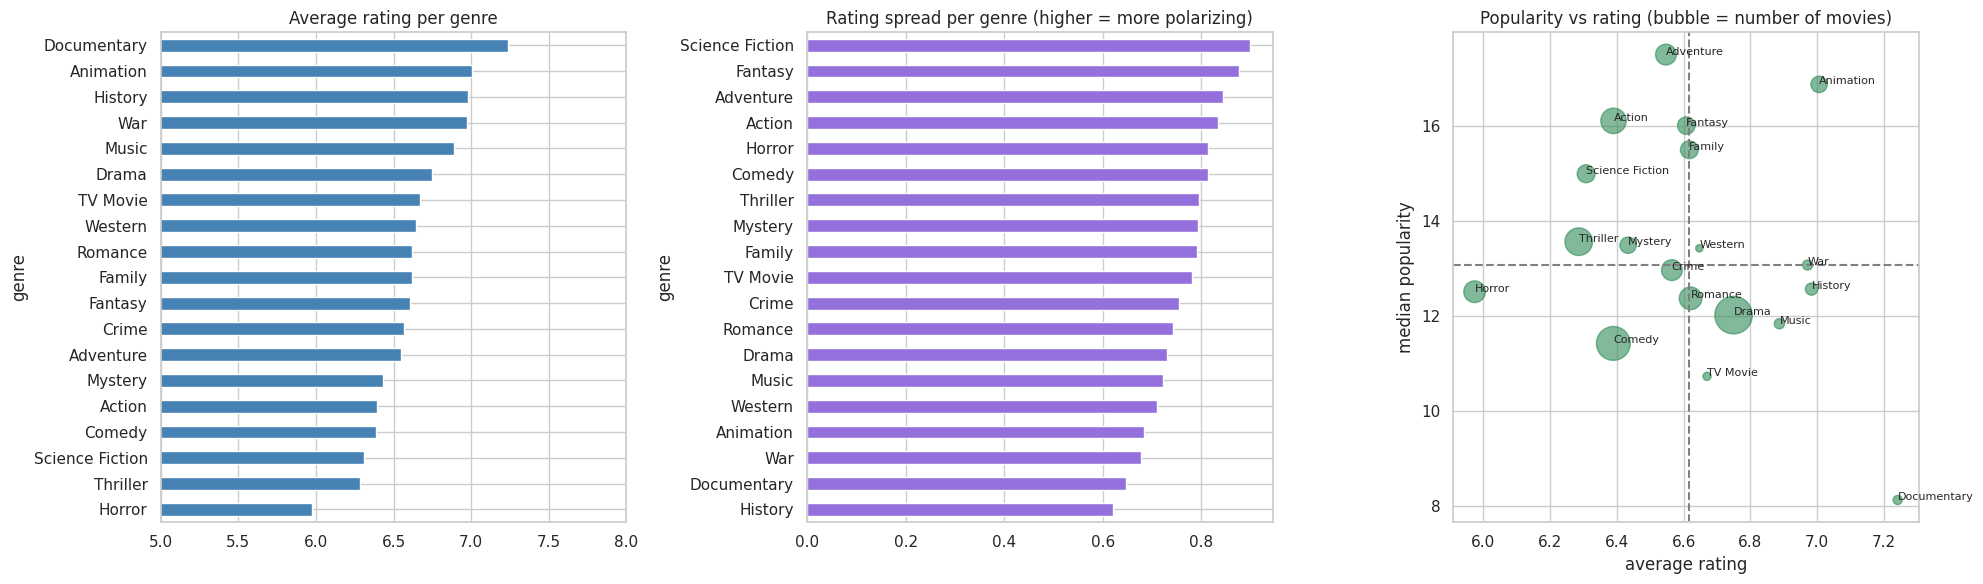

Popular but below-median rating: ['Fantasy', 'Adventure', 'Mystery', 'Action', 'Science Fiction', 'Thriller']


In [ ]:
# ======================================================================
# INSIGHT A1 — Genre report card.
# For each genre: how many movies, the average rating, how much ratings vary inside
# the genre (std = polarizing), and how popular the genre is (median popularity).
# The scatter shows which genres are popular but low-rated (bottom right).
# ======================================================================
g = explode_list(df_rel, "genres", "genre")
genre_stats = g.groupby("genre").agg(
    n=("id", "count"), mean_rating=("vote_average", "mean"), std_rating=("vote_average", "std"),
    median_popularity=("popularity", "median"), median_votes=("vote_count", "median")
).sort_values("mean_rating", ascending=False)
display(genre_stats.round(2))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
genre_stats["mean_rating"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Average rating per genre"); axes[0].set_xlim(5, 8)

genre_stats["std_rating"].sort_values().plot(kind="barh", ax=axes[1], color="mediumpurple")
axes[1].set_title("Rating spread per genre (higher = more polarizing)")

axes[2].scatter(genre_stats["mean_rating"], genre_stats["median_popularity"], s=genre_stats["n"] / 8, alpha=0.6, color="seagreen")
for name, r in genre_stats.iterrows():
    axes[2].annotate(name, (r["mean_rating"], r["median_popularity"]), fontsize=8)
axes[2].axvline(genre_stats["mean_rating"].median(), color="gray", ls="--")
axes[2].axhline(genre_stats["median_popularity"].median(), color="gray", ls="--")
axes[2].set_xlabel("average rating"); axes[2].set_ylabel("median popularity")
axes[2].set_title("Popularity vs rating (bubble = number of movies)")
plt.tight_layout(); plt.show()

pop_low = genre_stats[(genre_stats["median_popularity"] > genre_stats["median_popularity"].median()) &
                      (genre_stats["mean_rating"] < genre_stats["mean_rating"].median())]
print("Popular but below-median rating:", list(pop_low.index))


> 💡 **Insight.**
> - **Highest rated:** Documentary (7.24), Animation (7.01), History (6.98) and War (6.97). **Lowest:** Horror (5.97), Thriller (6.29) and Science Fiction (6.31).
> - **Most polarizing** (biggest rating spread): Science Fiction (0.90), Fantasy (0.88) and Adventure (0.84). The most consistent are History (0.62) and Documentary (0.65).
> - **Popular but below-median rating:** Fantasy, Adventure, Mystery, Action, Science Fiction and Thriller. Audiences watch these a lot but rate them lower.
> - **Animation** is the only genre that is both highly rated and very popular. **Documentary** is the opposite: the best rated, but the least popular genre (median popularity 8.1).

,n,mean_rating,median_rating,mean_imdb
decade,,,,
1920,48,7.34,7.42,7.59
1930,126,7.07,7.11,7.41
1940,175,7.12,7.10,7.38
1950,277,7.15,7.14,7.35
1960,435,7.08,7.11,7.17
1970,568,6.84,6.90,6.95
1980,973,6.55,6.57,6.60
1990,1478,6.47,6.50,6.50
2000,2727,6.36,6.40,6.33


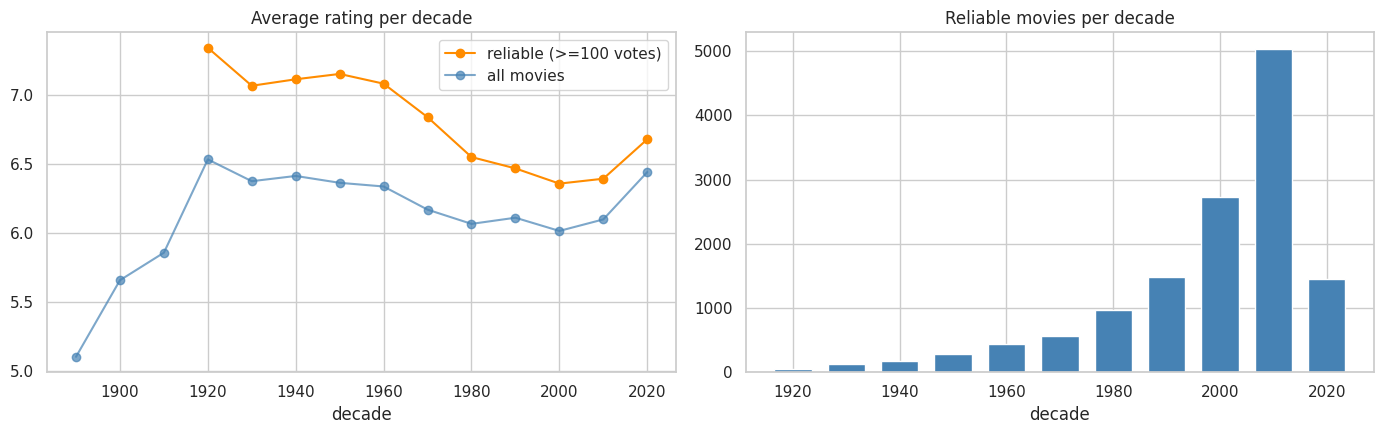

Best decade : 1920 7.34
Worst decade: 2000 6.36


In [ ]:
# ======================================================================
# INSIGHT A2 — Do ratings change over time?
# Average rating per decade. We draw two lines: reliable movies only (>=100 votes)
# and all movies, to show how much the vote filter matters. Decades with fewer than
# 30 movies are skipped.
# ======================================================================
def decade_table(frame):
    t = frame.groupby("decade").agg(n=("id", "count"), mean_rating=("vote_average", "mean"),
                                    median_rating=("vote_average", "median"), mean_imdb=("averageRating", "mean"))
    return t[t["n"] >= 30]

dec_rel, dec_all = decade_table(df_rel), decade_table(df_ins)
display(dec_rel.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(dec_rel.index, dec_rel["mean_rating"], marker="o", label="reliable (>=100 votes)", color="darkorange")
axes[0].plot(dec_all.index, dec_all["mean_rating"], marker="o", label="all movies", color="steelblue", alpha=0.7)
axes[0].set_title("Average rating per decade"); axes[0].set_xlabel("decade"); axes[0].legend()
axes[1].bar(dec_rel.index, dec_rel["n"], width=7, color="steelblue")
axes[1].set_title("Reliable movies per decade"); axes[1].set_xlabel("decade")
plt.tight_layout(); plt.show()

print("Best decade :", int(dec_rel["mean_rating"].idxmax()), round(dec_rel["mean_rating"].max(), 2))
print("Worst decade:", int(dec_rel["mean_rating"].idxmin()), round(dec_rel["mean_rating"].min(), 2))


> 💡 **Insight.** Ratings fall over time: from **7.34** in the 1920s and about **7.1** from the 1930s to the 1960s, down to a low of **6.36** in the 2000s, with a small recovery to **6.68** in the 2020s. Two cautions: (1) old movies that still have 100+ votes are mostly classics that survived, so their ratings are inflated by survivorship; (2) the 2020s recovery comes from TMDB only, since the IMDb average keeps falling (6.23 in the 2010s to 6.03 in the 2020s). See A3.

#### 🎚️ Try it yourself: slide through time
Use the slider below to move **left (older decades) or right (newer decades)**, or press **▶** to watch the decades play one after another. For each decade you will see where it sits on the rating line, how its ratings are spread compared with all movies, its most common genres, and its five best-rated movies.

> ℹ️ The slider needs `ipywidgets` and a live Jupyter / Colab session: run the cell below to activate it (`pip install ipywidgets` if you get an error).

In [ ]:
# ======================================================================
# INTERACTIVE — slide through the decades (follow-up to INSIGHT A2).
# Move the slider left / right (or press ▶ to play) and the charts + numbers update
# for the decade you pick. Needs the package ipywidgets (pip install ipywidgets).
#   Left  : the average-rating line; the red dot is the selected decade, the orange part is the path so far.
#   Right : how the ratings of that decade are spread (orange) compared with all decades together (grey).
# ======================================================================
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None
    print("ipywidgets is not installed -> run:  pip install ipywidgets   (then restart the kernel)")

overall_mean = df_rel["vote_average"].mean()

def show_decade(decade):
    sub = df_rel[df_rel["decade"] == decade]
    mean_now = dec_rel.loc[decade, "mean_rating"]
    prev = dec_rel["mean_rating"].get(decade - 10, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    ax = axes[0]
    ax.plot(dec_rel.index, dec_rel["mean_rating"], color="lightgray", marker="o", lw=2)
    upto = dec_rel[dec_rel.index <= decade]
    ax.plot(upto.index, upto["mean_rating"], color="darkorange", marker="o", lw=3)
    ax.scatter([decade], [mean_now], s=260, color="crimson", zorder=5)
    ax.annotate(f"{decade}s: {mean_now:.2f}", (decade, mean_now), textcoords="offset points", xytext=(0, 16),
                ha="center", fontsize=12, fontweight="bold", color="crimson")
    ax.axhline(overall_mean, color="gray", ls="--", lw=1)
    ax.text(dec_rel.index.max(), overall_mean + 0.02, f"overall average {overall_mean:.2f}", ha="right", va="bottom", color="gray", fontsize=9)
    ax.set_xticks(dec_rel.index); ax.set_xticklabels([f"{d}s" for d in dec_rel.index], rotation=45, fontsize=8)
    ax.set_ylim(dec_rel["mean_rating"].min() - 0.25, dec_rel["mean_rating"].max() + 0.35)
    ax.set_ylabel("average rating"); ax.set_title("Average rating per decade")

    ax = axes[1]
    sns.histplot(df_rel["vote_average"], bins=np.arange(2, 10.01, 0.25), stat="density", color="lightgray", ax=ax, label="all decades")
    sns.histplot(sub["vote_average"], bins=np.arange(2, 10.01, 0.25), stat="density", color="darkorange", alpha=0.65, ax=ax, label=f"{decade}s")
    ax.axvline(overall_mean, color="gray", ls="--"); ax.axvline(sub["vote_average"].mean(), color="crimson", lw=2)
    ax.set_xlabel("rating (vote_average)"); ax.set_ylabel("share of movies (density)")
    ax.set_title(f"How the ratings of the {decade}s are spread (red line = their average)"); ax.legend()
    plt.tight_layout(); plt.show()

    change = "—" if np.isnan(prev) else f"{mean_now - prev:+.2f} vs the previous decade"
    top_g = explode_list(sub, "genres", "genre")["genre"].value_counts().head(3)
    print(f"{decade}s  |  {len(sub)} reliable movies  |  average {mean_now:.2f}  |  median {sub['vote_average'].median():.2f}  |  {change}")
    print("Most common genres:", ", ".join(f"{g} ({n})" for g, n in top_g.items()))
    display(sub.nlargest(5, "vote_average")[["title", "release_year", "vote_average", "vote_count", "genres"]].round(2).reset_index(drop=True))

if widgets is not None:
    dmin, dmax = int(dec_rel.index.min()), int(dec_rel.index.max())
    slider = widgets.IntSlider(value=dmax, min=dmin, max=dmax, step=10, description="Decade:",
                               continuous_update=False, layout=widgets.Layout(width="650px"))
    play = widgets.Play(value=dmax, min=dmin, max=dmax, step=10, interval=1200, description="Play")
    widgets.jslink((play, "value"), (slider, "value"))
    out = widgets.interactive_output(lambda decade: show_decade(decade), {"decade": slider})
    display(widgets.VBox([widgets.HBox([play, slider]), out]))

,n,mean_rating
rt_band,,
40-89,2389,6.33
90-99,3587,6.21
100-109,2906,6.49
110-119,1846,6.70
120-139,1682,6.92
140+,619,7.23


Spearman (runtime vs rating): 0.299


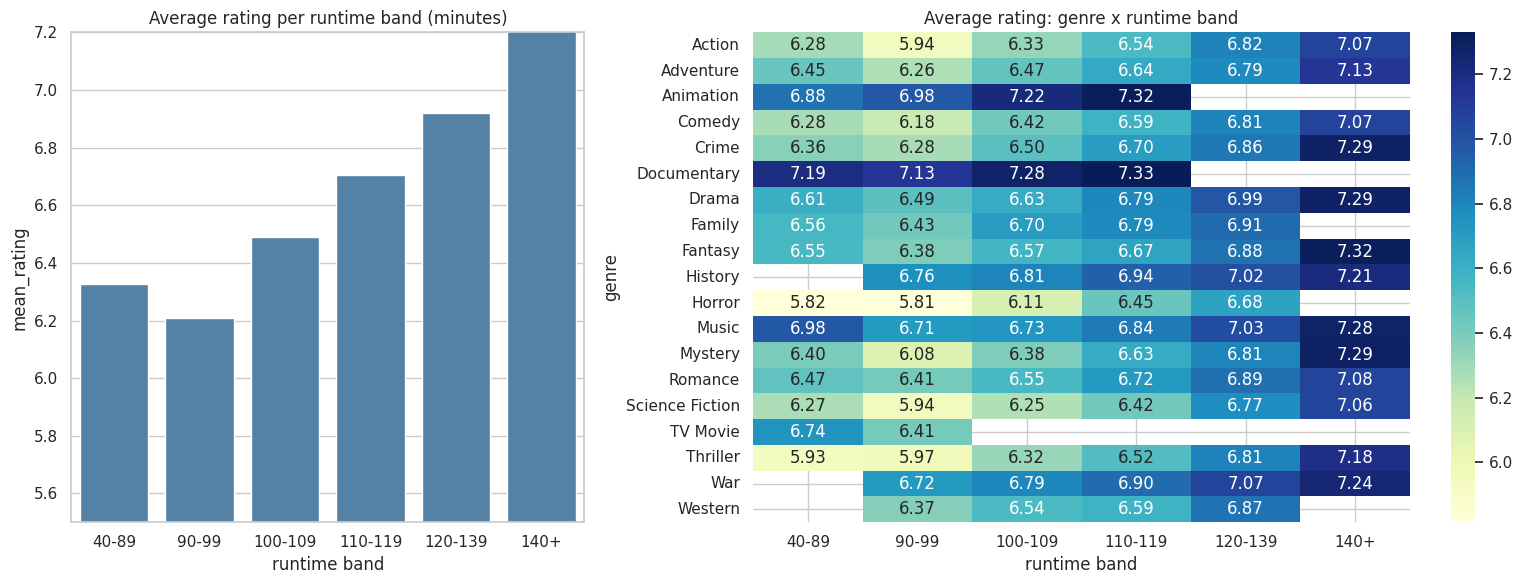

,best_runtime_band,avg_rating_in_best_band
genre,,
Action,140+,7.07
Adventure,140+,7.13
Animation,110-119,7.32
Comedy,140+,7.07
Crime,140+,7.29
Documentary,110-119,7.33
Drama,140+,7.29
Family,120-139,6.91
Fantasy,140+,7.32


In [ ]:
# ======================================================================
# INSIGHT A3 — Runtime vs rating.
# Short films (<40 min) and extreme lengths (>240 min) are removed so they don't distort
# the picture. We group runtime into bands, look at the average rating per band, and
# build a genre x runtime heatmap to find the best runtime band for each genre
# (cells with fewer than 30 movies are hidden).
# ======================================================================
df_rt = df_rel[(df_rel["runtime"] >= SHORT_LIMIT) & (df_rel["runtime"] <= 240)].copy()
rt_bins = [40, 90, 100, 110, 120, 140, 240]
rt_labels = ["40-89", "90-99", "100-109", "110-119", "120-139", "140+"]
df_rt["rt_band"] = pd.cut(df_rt["runtime"], bins=rt_bins, labels=rt_labels, right=False)

rt_tbl = df_rt.groupby("rt_band", observed=True).agg(n=("id", "count"), mean_rating=("vote_average", "mean"))
display(rt_tbl.round(2))
print("Spearman (runtime vs rating):", round(df_rt["runtime"].corr(df_rt["vote_average"], method="spearman"), 3))

g_rt = explode_list(df_rt, "genres", "genre")
heat = g_rt.pivot_table(index="genre", columns="rt_band", values="vote_average", aggfunc="mean", observed=False)
cnt = g_rt.pivot_table(index="genre", columns="rt_band", values="vote_average", aggfunc="count", observed=False)
heat = heat.where(cnt >= 30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.6]})
sns.barplot(x=rt_tbl.index.astype(str), y=rt_tbl["mean_rating"], color="steelblue", ax=axes[0])
axes[0].set_ylim(5.5, 7.2); axes[0].set_title("Average rating per runtime band (minutes)"); axes[0].set_xlabel("runtime band")
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Average rating: genre x runtime band"); axes[1].set_xlabel("runtime band")
plt.tight_layout(); plt.show()

best_band = heat.idxmax(axis=1).rename("best_runtime_band")
display(pd.concat([best_band, heat.max(axis=1).round(2).rename("avg_rating_in_best_band")], axis=1))


> 💡 **Insight.** Longer movies are rated higher: the average rises from **6.21** (90–99 min) to **7.23** for movies over 140 minutes, with a correlation of **0.30**. **13 of the 19 genres** score best in the 140+ band; the exceptions are Animation and Documentary (110–119 min), Family, Horror and Western (120–139 min) and TV Movie (under 90 min).
>
> This is likely a selection effect rather than "longer is better": studios only give 2.5+ hours to ambitious projects, and long movies are more often epics and classics.

### B. Money
_Only movies with a usable budget/revenue (>= 1,000) are included. Values are NOT adjusted for inflation._

,n,min_budget,median_budget,mean_rating
budget_group,,,,
Q1 lowest,1284,3900.0,1200000.0,6.62
Q2,1283,3440000.0,6000000.0,6.46
Q3,1438,9850000.0,15000000.0,6.44
Q4,1189,20170000.0,30000000.0,6.40
Q5 highest,1223,40500000.0,70000000.0,6.52


Movies used (budget vs rating): 6417
Spearman budget vs rating     : -0.057

Movies used (budget vs revenue): 6490
Pearson (log budget vs log revenue): 0.649
Movies with revenue > budget        : 66.5%
Median revenue / budget             : 1.84
Spearman revenue vs rating          : 0.135


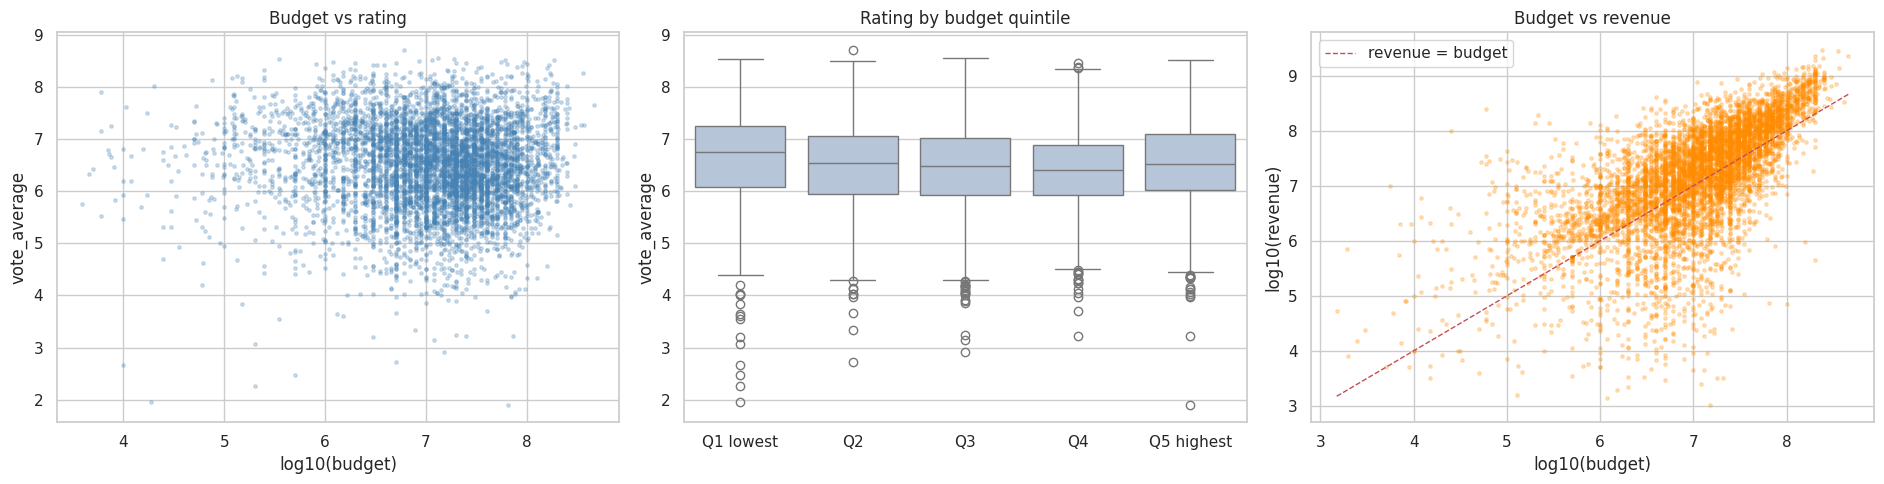

In [ ]:
# ======================================================================
# INSIGHT B1 — Does money buy quality?
# Part 1: budget vs rating (reliable movies with a budget), also by budget quintile.
# Part 2: budget vs revenue (all movies with both), on log scales.
# ======================================================================
bud = df_rel.dropna(subset=["budget"]).copy()
bud["log_budget"] = np.log10(bud["budget"])
bud["budget_group"] = pd.qcut(bud["budget"], 5, labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"])

bud_tbl = bud.groupby("budget_group", observed=True).agg(
    n=("id", "count"), min_budget=("budget", "min"), median_budget=("budget", "median"),
    mean_rating=("vote_average", "mean"))
display(bud_tbl.round(2))
print("Movies used (budget vs rating):", len(bud))
print("Spearman budget vs rating     :", round(bud["budget"].corr(bud["vote_average"], method="spearman"), 3))

br = df_ins.dropna(subset=["budget", "revenue"]).copy()
br["log_budget"], br["log_revenue"] = np.log10(br["budget"]), np.log10(br["revenue"])
print("\nMovies used (budget vs revenue):", len(br))
print("Pearson (log budget vs log revenue):", round(br["log_budget"].corr(br["log_revenue"]), 3))
print("Movies with revenue > budget        :", f"{(br['revenue'] > br['budget']).mean()*100:.1f}%")
print("Median revenue / budget             :", round((br["revenue"] / br["budget"]).median(), 2))
rev_rel = df_rel.dropna(subset=["revenue"])
print("Spearman revenue vs rating          :", round(rev_rel["revenue"].corr(rev_rel["vote_average"], method="spearman"), 3))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].scatter(bud["log_budget"], bud["vote_average"], s=6, alpha=0.25, color="steelblue")
axes[0].set_xlabel("log10(budget)"); axes[0].set_ylabel("vote_average"); axes[0].set_title("Budget vs rating")
sns.boxplot(data=bud, x="budget_group", y="vote_average", color="lightsteelblue", ax=axes[1])
axes[1].set_title("Rating by budget quintile"); axes[1].set_xlabel("")
axes[2].scatter(br["log_budget"], br["log_revenue"], s=6, alpha=0.25, color="darkorange")
lim = [br["log_budget"].min(), br["log_budget"].max()]
axes[2].plot(lim, lim, "r--", lw=1, label="revenue = budget")
axes[2].set_xlabel("log10(budget)"); axes[2].set_ylabel("log10(revenue)"); axes[2].set_title("Budget vs revenue"); axes[2].legend()
plt.tight_layout(); plt.show()


> 💡 **Insight.**
> - **Money does not buy quality.** Budget and rating have almost no relationship (Spearman **-0.06**, 6,417 movies). The *cheapest* fifth of movies (median budget $1.2M) has the highest average rating (**6.62**), while the most expensive fifth (median $70M) averages 6.52.
> - **Money does buy revenue.** Budget and revenue are strongly linked (log correlation **0.65**, 6,490 movies). **66.5%** of movies earn more than their budget, with a median revenue of **1.84×** the budget (note: this ignores marketing and other costs, so it is not profit).
> - **Revenue and rating are only weakly related** (Spearman 0.14): a big hit is not necessarily a well-rated movie.

,n_budget,median_budget,n_revenue,median_revenue,n_both,median_rev_to_budget
decade,,,,,,
1920,39,337000.0,29.0,NaN,23.0,NaN
1930,152,396875.0,86.0,1611000.0,79.0,2.65
1940,139,1300000.0,110.0,2952250.0,94.0,2.69
1950,200,1266000.0,151.0,3900000.0,123.0,3.00
1960,262,1800000.0,200.0,6796000.0,138.0,3.40
1970,411,1800000.0,300.0,14461742.0,221.0,6.01
1980,807,7362000.0,895.0,11604598.0,599.0,2.15
1990,1257,15000000.0,1378.0,14565563.0,996.0,1.53
2000,2681,9800000.0,2367.0,13204291.0,1761.0,1.56


% of movies with a recorded budget, by decade:


decade,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
share_budget,11.6,16.4,10.6,10.6,11.3,13.8,22.4,27.1,28.5,20.5,13.6


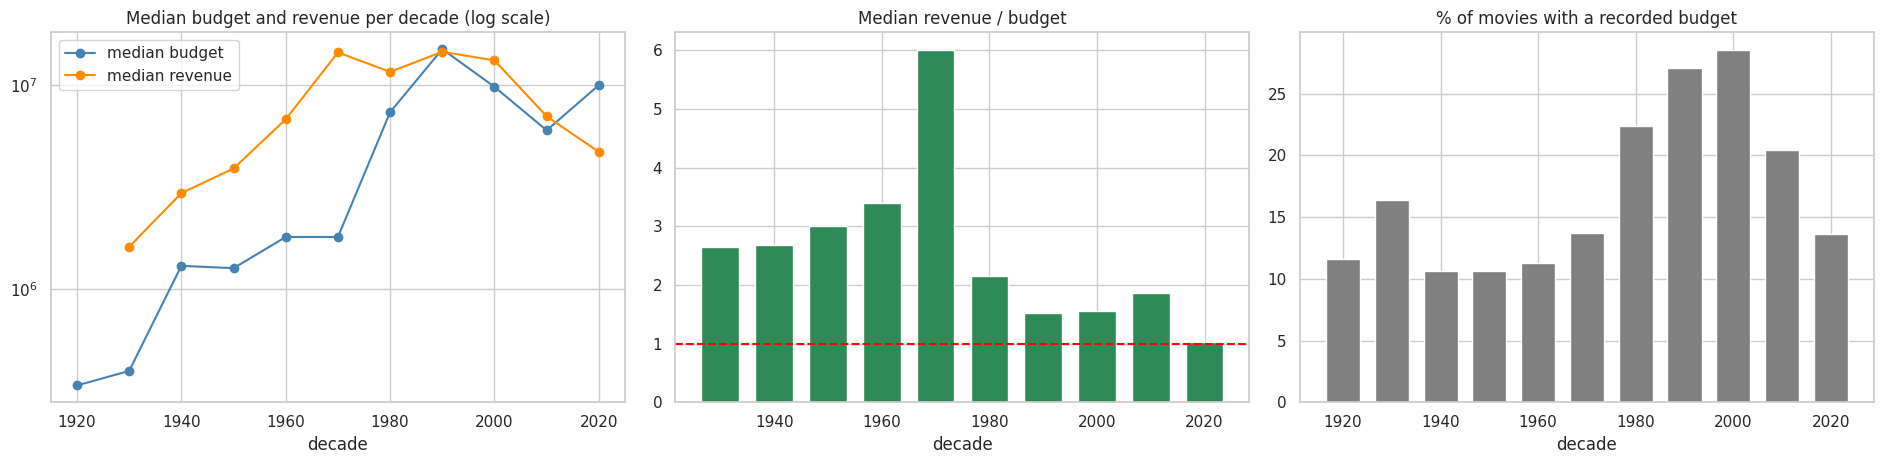

In [ ]:
# ======================================================================
# INSIGHT B2 — Revenue trends.
# Median budget and median revenue per decade (only decades with at least 30 movies
# that have the value), plus the median revenue-to-budget multiple for movies that
# have both. Medians are used because a few blockbusters would distort the mean.
# Note: values are in nominal dollars (not inflation adjusted).
# ======================================================================
b_dec = df_ins.dropna(subset=["budget"]).groupby("decade").agg(n_budget=("id", "count"), median_budget=("budget", "median"))
r_dec = df_ins.dropna(subset=["revenue"]).groupby("decade").agg(n_revenue=("id", "count"), median_revenue=("revenue", "median"))
m_dec = br.assign(ratio=br["revenue"] / br["budget"]).groupby("decade").agg(n_both=("id", "count"), median_rev_to_budget=("ratio", "median"))

money_dec = b_dec.join(r_dec, how="outer").join(m_dec, how="outer")
money_dec.loc[money_dec["n_budget"] < 30, "median_budget"] = np.nan
money_dec.loc[money_dec["n_revenue"] < 30, "median_revenue"] = np.nan
money_dec.loc[money_dec["n_both"] < 30, "median_rev_to_budget"] = np.nan
money_dec = money_dec[money_dec[["median_budget", "median_revenue"]].notna().any(axis=1)]
display(money_dec.round(2))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
axes[0].plot(money_dec.index, money_dec["median_budget"], marker="o", label="median budget", color="steelblue")
axes[0].plot(money_dec.index, money_dec["median_revenue"], marker="o", label="median revenue", color="darkorange")
axes[0].set_yscale("log"); axes[0].set_title("Median budget and revenue per decade (log scale)"); axes[0].set_xlabel("decade"); axes[0].legend()
axes[1].bar(money_dec.index, money_dec["median_rev_to_budget"], width=7, color="seagreen")
axes[1].axhline(1, color="red", ls="--"); axes[1].set_title("Median revenue / budget"); axes[1].set_xlabel("decade")
rec = df_ins.groupby("decade").agg(share_budget=("budget", lambda s: s.notna().mean() * 100))
rec = rec[rec.index >= money_dec.index.min()]
print("% of movies with a recorded budget, by decade:")
display(rec.round(1).T)
axes[2].bar(rec.index, rec["share_budget"], width=7, color="gray")
axes[2].set_title("% of movies with a recorded budget"); axes[2].set_xlabel("decade")
plt.tight_layout(); plt.show()


> 💡 **Insight.** The median budget grew from **$0.3M** (1920s) to **$1.8M** (1960s–70s), **$7.4M** (1980s) and peaked at **$15M** in the 1990s, then *fell* to $9.8M (2000s) and $6M (2010s). The median revenue followed the same shape (about $14.5M in both the 1970s and 1990s, down to $7.0M in the 2010s). The revenue-to-budget multiple dropped from **6.0×** (1970s) to roughly **1.5–1.9×** since the 1990s.
>
> Do not read this as "movies got cheaper": values are not inflation adjusted, and which movies have a recorded budget changed (it rises from about 11–16% before 1980 to 27–28% in the 1990s–2000s, then falls to 20% and 14%). Older decades mostly record only the big hits, which inflates their multiples. The 2020s are also only 2020–2023 and affected by the pandemic.

#### 🎚️ Try it yourself: slide through the money numbers
Same idea for the money insight: slide (or press **▶**) to see the median budget, median revenue and revenue-to-budget multiple of one decade at a time. Remember that the values are not inflation-adjusted.

In [ ]:
# ======================================================================
# INTERACTIVE — slide through the decades (follow-up to INSIGHT B7).
# Move the slider (or press ▶) to see the money numbers of one decade at a time.
#   Left : median budget and median revenue per decade (log scale). The dots mark the selected decade.
#   Right: revenue / budget multiple per decade; the selected decade is highlighted in red.
# ======================================================================
md_vals = money_dec.copy()

def show_money(decade):
    row = md_vals.loc[decade] if decade in md_vals.index else None
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
    ax = axes[0]
    ax.plot(md_vals.index, md_vals["median_budget"], color="lightsteelblue", marker="o", lw=2, label="median budget")
    ax.plot(md_vals.index, md_vals["median_revenue"], color="navajowhite", marker="o", lw=2, label="median revenue")
    if row is not None:
        ax.scatter([decade], [row["median_budget"]], s=200, color="steelblue", zorder=5)
        ax.scatter([decade], [row["median_revenue"]], s=200, color="darkorange", zorder=5)
    ax.set_yscale("log"); ax.set_xticks(md_vals.index); ax.set_xticklabels([f"{d}s" for d in md_vals.index], rotation=45, fontsize=8)
    ax.set_ylabel("dollars (log scale, not inflation-adjusted)"); ax.set_title("Median budget and revenue"); ax.legend()

    ax = axes[1]
    colors = ["crimson" if d == decade else "lightgray" for d in md_vals.index]
    ax.bar(md_vals.index, md_vals["median_rev_to_budget"], width=7, color=colors)
    ax.axhline(1, color="black", ls="--", lw=1); ax.text(md_vals.index.min(), 1.05, "revenue = budget", fontsize=8)
    ax.set_xticks(md_vals.index); ax.set_xticklabels([f"{d}s" for d in md_vals.index], rotation=45, fontsize=8)
    ax.set_ylabel("median revenue ÷ budget"); ax.set_title("How many times does a movie earn back its budget?")
    plt.tight_layout(); plt.show()

    if row is None:
        print(f"{decade}s: not enough movies with a recorded budget/revenue (fewer than 30).")
    else:
        fmt = lambda v: "n/a" if np.isnan(v) else f"${v/1e6:,.1f}M"
        mult = "n/a" if np.isnan(row["median_rev_to_budget"]) else f"{row['median_rev_to_budget']:.1f}x"
        print(f"{decade}s  |  median budget {fmt(row['median_budget'])}  |  median revenue {fmt(row['median_revenue'])}  |  revenue/budget {mult}")
        if decade in rec.index:
            print(f"Only {rec.loc[decade, 'share_budget']:.0f}% of the movies of this decade have a recorded budget (read with care).")

if widgets is not None:
    bmin, bmax = int(md_vals.index.min()), int(md_vals.index.max())
    slider_b = widgets.IntSlider(value=bmax, min=bmin, max=bmax, step=10, description="Decade:",
                                 continuous_update=False, layout=widgets.Layout(width="650px"))
    play_b = widgets.Play(value=bmax, min=bmin, max=bmax, step=10, interval=1200)
    widgets.jslink((play_b, "value"), (slider_b, "value"))
    out_b = widgets.interactive_output(lambda decade: show_money(decade), {"decade": slider_b})
    display(widgets.VBox([widgets.HBox([play_b, slider_b]), out_b]))

### C. People and companies

Directors with >= 5 movies: 681 | Actors with >= 8 movies: 2830


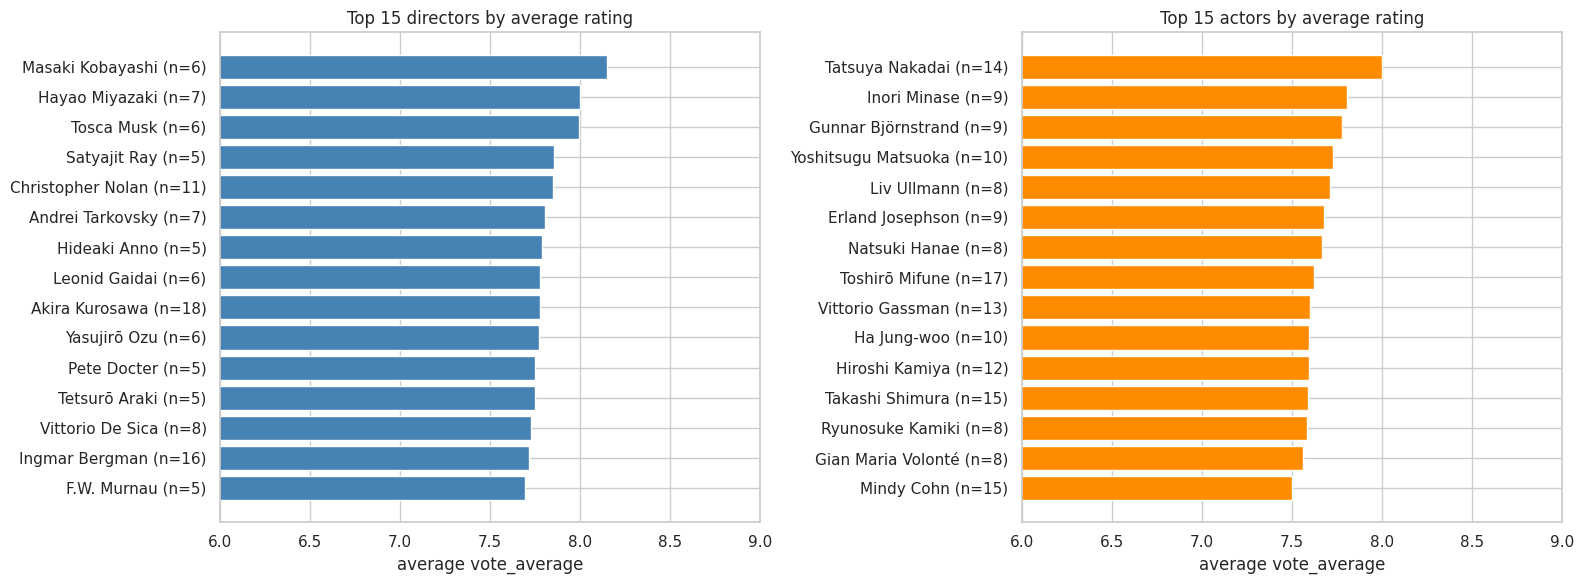

,n,mean_rating,mean_imdb
director,,,
Masaki Kobayashi,6,8.15,8.43
Hayao Miyazaki,7,8.00,7.97
Tosca Musk,6,7.99,6.03
Satyajit Ray,5,7.86,8.14
Christopher Nolan,11,7.85,8.15
Andrei Tarkovsky,7,7.81,7.86
Hideaki Anno,5,7.79,7.46
Leonid Gaidai,6,7.78,8.17
Akira Kurosawa,18,7.78,7.90


,n,mean_rating,mean_imdb
actor,,,
Tatsuya Nakadai,14,8.00,8.16
Inori Minase,9,7.81,7.22
Gunnar Björnstrand,9,7.78,7.88
Yoshitsugu Matsuoka,10,7.73,7.39
Liv Ullmann,8,7.71,7.88
Erland Josephson,9,7.68,7.81
Natsuki Hanae,8,7.67,7.52
Toshirō Mifune,17,7.62,7.72
Vittorio Gassman,13,7.60,7.58


In [ ]:
# ======================================================================
# INSIGHT C1 — Top directors and actors.
# Based on reliable movies (>=100 votes). To be fair, a director needs at least 5 such
# movies and an actor at least 8. We rank by average rating (vote_average).
# ======================================================================
MIN_DIR, MIN_ACT = 5, 8

dirs = explode_list(df_rel, "directors", "director")
dir_stats = dirs.groupby("director").agg(n=("id", "count"), mean_rating=("vote_average", "mean"),
                                         mean_imdb=("averageRating", "mean")).query("n >= @MIN_DIR")
dir_top = dir_stats.sort_values("mean_rating", ascending=False).head(15)

acts = explode_list(df_rel, "cast", "actor")
act_stats = acts.groupby("actor").agg(n=("id", "count"), mean_rating=("vote_average", "mean"),
                                      mean_imdb=("averageRating", "mean")).query("n >= @MIN_ACT")
act_top = act_stats.sort_values("mean_rating", ascending=False).head(15)

print(f"Directors with >= {MIN_DIR} movies: {len(dir_stats)} | Actors with >= {MIN_ACT} movies: {len(act_stats)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, top, title, color in [(axes[0], dir_top, "Top 15 directors", "steelblue"), (axes[1], act_top, "Top 15 actors", "darkorange")]:
    labels_ = [f"{n} (n={int(k)})" for n, k in zip(top.index, top["n"])]
    ax.barh(labels_[::-1], top["mean_rating"].values[::-1], color=color)
    ax.set_xlim(6, 9); ax.set_title(title + " by average rating"); ax.set_xlabel("average vote_average")
plt.tight_layout(); plt.show()

display(dir_top.round(2)); display(act_top.round(2))


> 💡 **Insight.**
> - **Directors:** the top spots go to classic and international auteurs and animation: Masaki Kobayashi (8.15), Hayao Miyazaki (8.00), Satyajit Ray (7.86), Christopher Nolan (7.85, the best-rated mainstream Hollywood director), Andrei Tarkovsky, Akira Kurosawa (7.78, with the most movies, 18) and Ingmar Bergman (7.72).
> - **Actors:** the top list is Japanese classic cinema (Tatsuya Nakadai 8.00, Toshirō Mifune, Takashi Shimura), Bergman's regulars (Gunnar Björnstrand, Liv Ullmann, Erland Josephson) and Japanese anime voice actors (Inori Minase, Yoshitsugu Matsuoka, Natsuki Hanae, Hiroshi Kamiya).
> - **Outlier:** Tosca Musk (7.99 on TMDB but only 6.03 on IMDb) shows how a small, enthusiastic fan base can lift a rating on one platform.
> - The ranking depends on the minimum-movies rule (5 for directors, 8 for actors); a lower threshold would let lucky small samples in.

Movies with a measurable star_power: 42797


,n,median_votes,median_popularity,mean_rating
star_quartile,,,,
Q1 low,10700,27.0,3.61,6.19
Q2,10699,30.0,4.26,6.15
Q3,10699,38.0,5.13,6.08
Q4 high,10699,136.0,9.36,6.24


,n,median_votes,median_popularity
famous_grp,,,
0,22709,28.0,3.88
1,8098,37.0,5.01
2,4397,57.0,6.56
3+,7593,232.0,11.15


,era,n,spearman_vs_votes,spearman_vs_popularity
0,all,42797,0.339,0.373
1,before 1980,8926,0.241,0.375
2,1980-1999,7378,0.373,0.389
3,2000+,26493,0.343,0.356


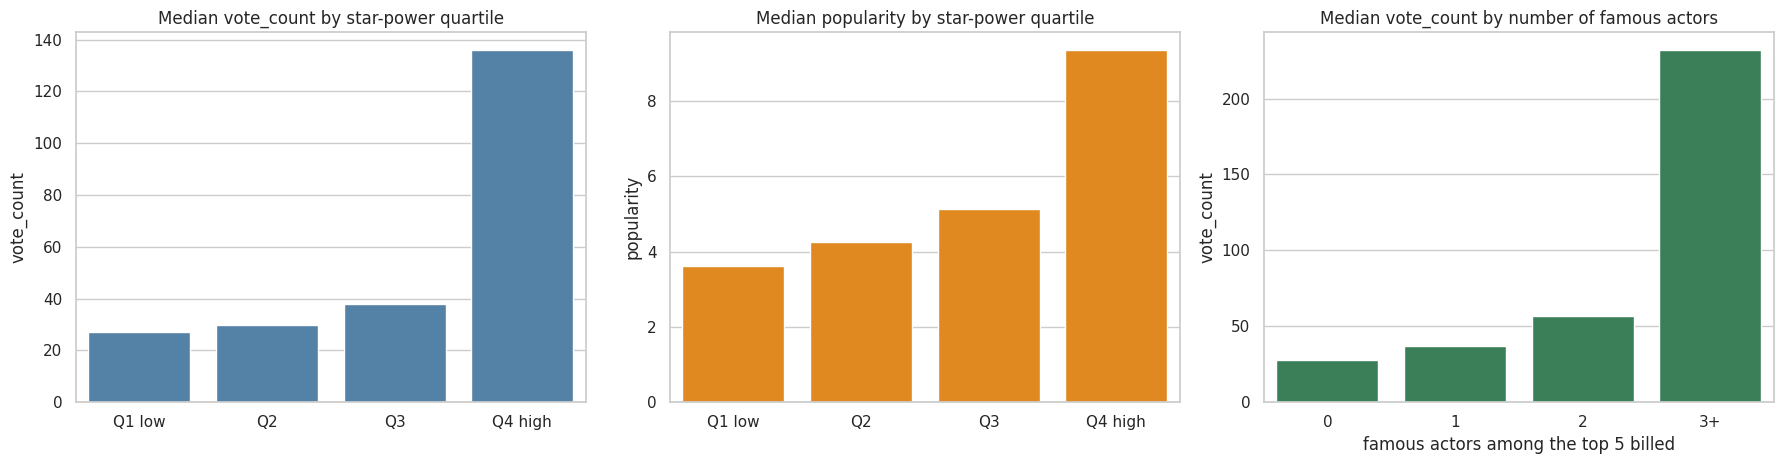

In [ ]:
# ======================================================================
# INSIGHT C2 — Star power test.
# Question: do movies with famous actors get more votes and popularity?
# 'Fame' of an actor = the average log(numVotes) of the OTHER movies he/she appears in
# (leave-one-out, so the movie we are testing never counts towards its own stars' fame).
# We use the first 5 billed actors and need at least 3 other movies to measure fame.
# A movie's star_power = the average fame of its billed actors.
# ======================================================================
cast5 = df_ins[["id", "cast", "numVotes"]].dropna(subset=["cast"]).copy()
cast5["actor"] = cast5["cast"].str.split(", ").str[:5]
credits = cast5.explode("actor")[["id", "actor", "numVotes"]].dropna()
credits["lv"] = np.log1p(credits["numVotes"])

agg = credits.groupby("actor")["lv"].agg(["sum", "count"])
credits = credits.join(agg, on="actor")
credits["other_n"] = credits["count"] - 1
credits["prior_fame"] = np.where(credits["other_n"] >= 3, (credits["sum"] - credits["lv"]) / credits["other_n"].replace(0, np.nan), np.nan)

actor_fame = (agg["sum"] / agg["count"])[agg["count"] >= 4]
famous_cut = actor_fame.quantile(0.75)          # 'famous' = top 25% of actors by average fame
credits["is_famous"] = credits["prior_fame"] >= famous_cut

movie_star = credits.groupby("id").agg(star_power=("prior_fame", "mean"), n_famous=("is_famous", "sum"))
star = df_ins.merge(movie_star, on="id", how="left")
sd = star.dropna(subset=["star_power"]).copy()
sd["star_quartile"] = pd.qcut(sd["star_power"], 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
sd["famous_grp"] = sd["n_famous"].clip(upper=3).astype(int).astype(str).replace({"3": "3+"})
sd["era"] = pd.cut(sd["release_year"], [0, 1979, 1999, 2100], labels=["before 1980", "1980-1999", "2000+"])

print("Movies with a measurable star_power:", len(sd))
tbl_q = sd.groupby("star_quartile", observed=True).agg(n=("id", "count"), median_votes=("vote_count", "median"),
                                                        median_popularity=("popularity", "median"), mean_rating=("vote_average", "mean"))
display(tbl_q.round(2))
tbl_f = sd.groupby("famous_grp").agg(n=("id", "count"), median_votes=("vote_count", "median"), median_popularity=("popularity", "median"))
display(tbl_f.round(2))

rows = []
for era, part in [("all", sd)] + [(e, sd[sd["era"] == e]) for e in sd["era"].cat.categories]:
    rows.append({"era": era, "n": len(part),
                 "spearman_vs_votes": part["star_power"].corr(part["vote_count"], method="spearman"),
                 "spearman_vs_popularity": part["star_power"].corr(part["popularity"], method="spearman")})
display(pd.DataFrame(rows).round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
sns.barplot(data=sd, x="star_quartile", y="vote_count", estimator=np.median, errorbar=None, color="steelblue", ax=axes[0])
axes[0].set_title("Median vote_count by star-power quartile"); axes[0].set_xlabel("")
sns.barplot(data=sd, x="star_quartile", y="popularity", estimator=np.median, errorbar=None, color="darkorange", ax=axes[1])
axes[1].set_title("Median popularity by star-power quartile"); axes[1].set_xlabel("")
sns.barplot(data=sd, x="famous_grp", y="vote_count", order=["0", "1", "2", "3+"], estimator=np.median, errorbar=None, color="seagreen", ax=axes[2])
axes[2].set_title("Median vote_count by number of famous actors"); axes[2].set_xlabel("famous actors among the top 5 billed")
plt.tight_layout(); plt.show()


> 💡 **Insight.** Famous casts attract **attention, not better ratings**.
> - Movies in the top star-power quartile have a median of **136 votes vs 27** in the bottom quartile (about 5×), and a median popularity of **9.4 vs 3.6** (about 2.6×).
> - Movies with **3 or more famous actors** among the top 5 billed have a median of **232 votes vs 28** for movies with none.
> - The link is consistent in every era (correlation with votes 0.24–0.37, with popularity 0.36–0.39), so it is not just an effect of recent movies.
> - But the average rating is flat across quartiles (6.19 → 6.24).
>
> The jump is concentrated in the top quartile, and this shows association, not proof that stars cause the extra votes (big studios both hire stars and promote more).

### D. Content and audience

Keywords with >= 50 reliable movies: 311 | overall mean rating: 6.51


keyword,woman director,based on novel or book,murder,short film,christmas,revenge,biography,new york city,lgbt,gay theme,based on true story,sequel,musical,love,california,france,friendship,england,world war ii,sports
n_movies,2731,2147,1733,1297,912,857,852,827,798,793,789,728,711,702,694,651,616,593,569,567


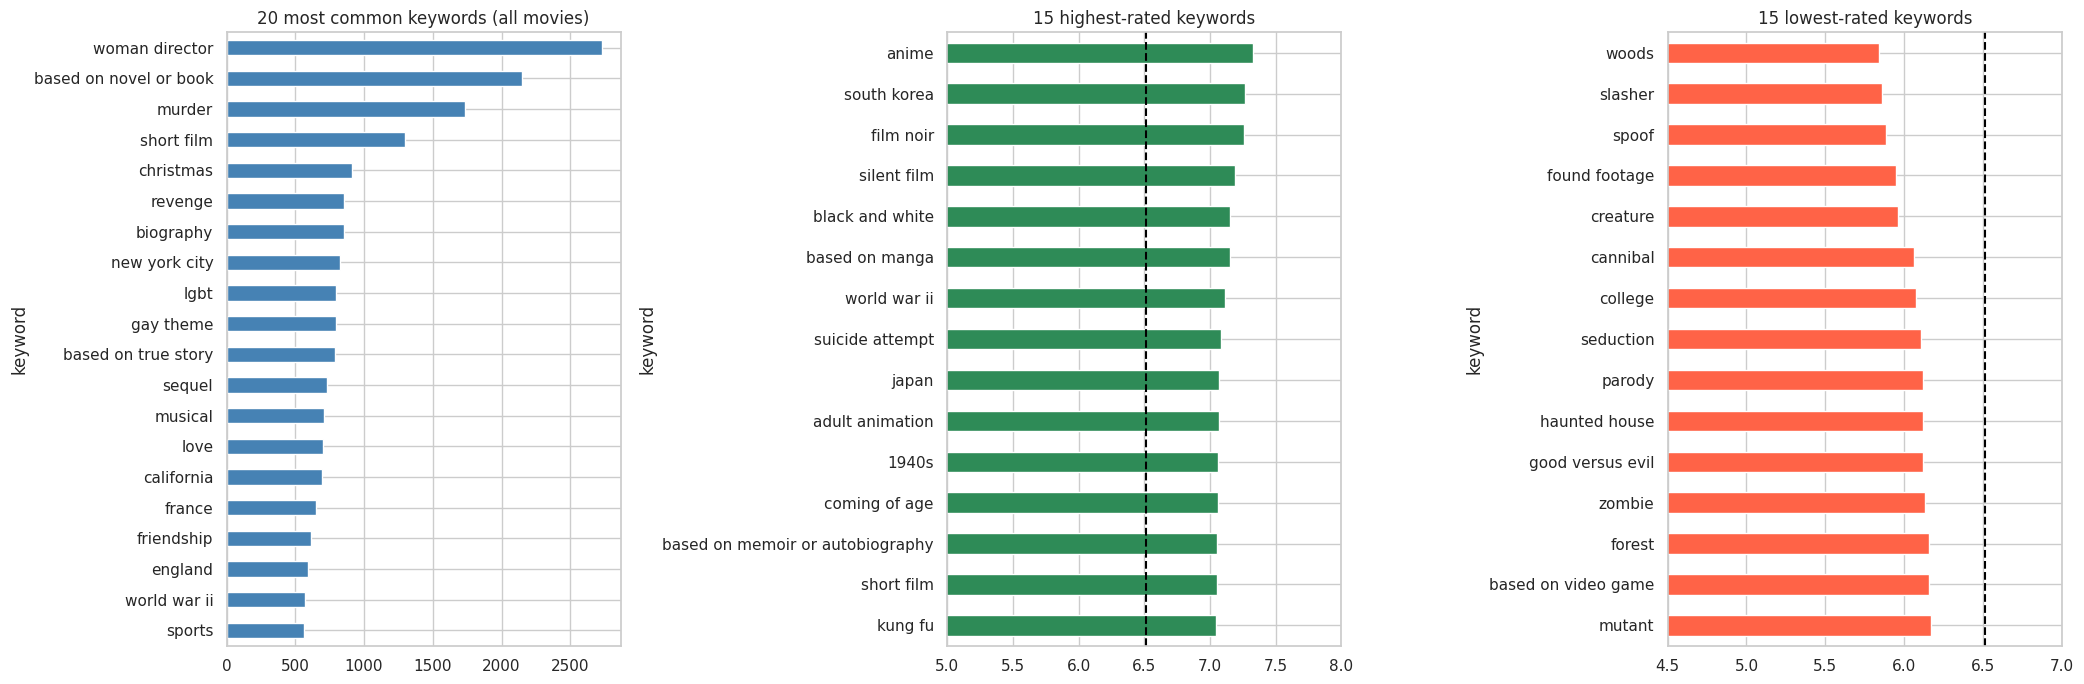

,n,mean_rating
keyword,,
anime,242,7.33
south korea,54,7.26
film noir,87,7.26
silent film,63,7.19
black and white,193,7.16
based on manga,95,7.15
world war ii,194,7.12
suicide attempt,53,7.09
japan,179,7.07


,n,mean_rating
keyword,,
woods,61,5.84
slasher,130,5.86
spoof,57,5.88
found footage,97,5.95
creature,114,5.96
cannibal,54,6.06
college,92,6.07
seduction,56,6.10
parody,81,6.12


In [ ]:
# ======================================================================
# INSIGHT D1 — Keywords and themes.
# Left: the most common keywords over all movies. Middle/right: among reliable movies,
# keywords used in at least 50 movies with the HIGHEST and LOWEST average rating.
# The dashed line is the overall average rating.
# ======================================================================
kw_all = explode_list(df_ins, "keywords", "keyword")
kw_top = kw_all["keyword"].value_counts().head(20)

kw_rel = explode_list(df_rel, "keywords", "keyword")
kw_stats = kw_rel.groupby("keyword").agg(n=("id", "count"), mean_rating=("vote_average", "mean")).query("n >= 50")
kw_hi = kw_stats.sort_values("mean_rating", ascending=False).head(15)
kw_lo = kw_stats.sort_values("mean_rating").head(15)
base = df_rel["vote_average"].mean()
print("Keywords with >= 50 reliable movies:", len(kw_stats), "| overall mean rating:", round(base, 2))
display(kw_top.rename("n_movies").to_frame().T)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
kw_top.sort_values().plot(kind="barh", ax=axes[0], color="steelblue"); axes[0].set_title("20 most common keywords (all movies)")
kw_hi["mean_rating"].sort_values().plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].axvline(base, color="black", ls="--"); axes[1].set_xlim(5, 8); axes[1].set_title("15 highest-rated keywords")
kw_lo["mean_rating"].sort_values(ascending=False).plot(kind="barh", ax=axes[2], color="tomato")
axes[2].axvline(base, color="black", ls="--"); axes[2].set_xlim(4.5, 7); axes[2].set_title("15 lowest-rated keywords")
plt.tight_layout(); plt.show()

display(kw_hi.round(2)); display(kw_lo.round(2))


> 💡 **Insight.** The most common keywords are **woman director (2,731 movies)**, based on novel or book (2,147), murder (1,733), short film (1,297) and Christmas (912).
>
> Highest-rated themes (average of 6.51 overall): **anime (7.33)**, south korea (7.26), film noir (7.26), silent film (7.19), black and white (7.16), based on manga and world war ii (about 7.1). These are heritage, auteur and animation themes. The lowest-rated are low-budget horror and parody styles: **woods (5.84), slasher (5.86), spoof (5.88), found footage (5.95) and creature (5.96)**.

n  median_votes  median_popularity  mean_rating
group                 has                                                       
Homepage\n(2000+)     False  21297          33.0               4.26         6.02
                      True   10285          57.0               6.12         6.36
Homepage\n(all years) False  38995          31.0               4.25         6.09
                      True   10933          58.0               6.24         6.37
Tagline\n(2000+)      False  17338          27.0               3.67         6.19
                      True   14244          74.0               7.19         6.05
Tagline\n(all years)  False  25667          25.0               3.43         6.24
                      True   24261          60.0               6.69         6.07

Share of movies having each item, by decade:


,has_tagline,has_homepage
decade,,
1950,59.1,1.0
1960,52.4,2.8
1970,53.2,3.3
1980,55.3,4.6
1990,56.1,6.1
2000,47.8,20.2
2010,44.0,35.4
2020,43.7,46.5


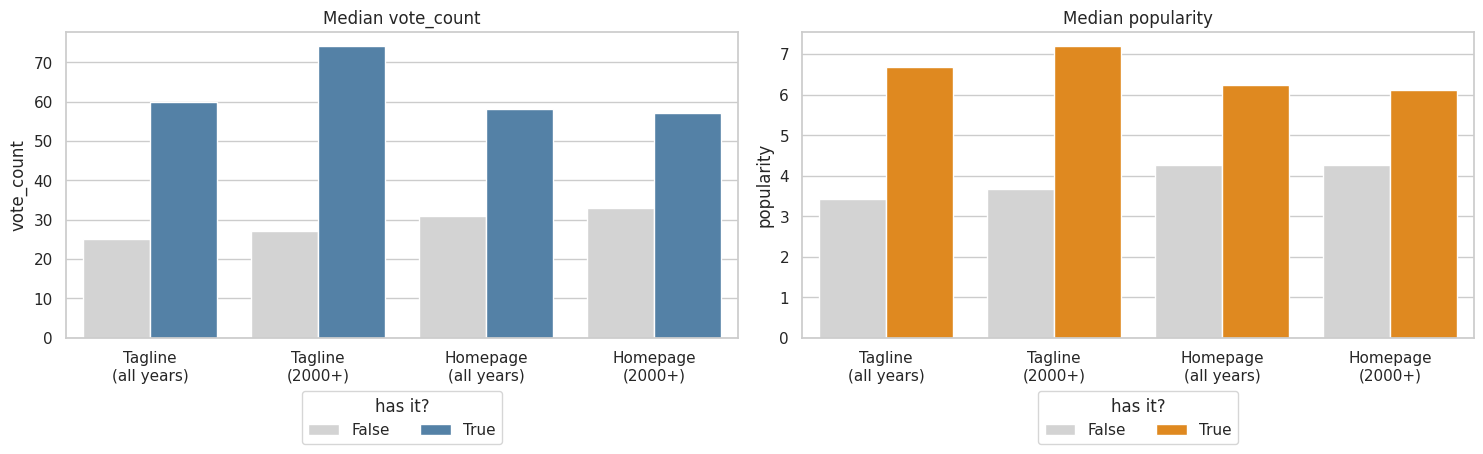

In [ ]:
# ======================================================================
# INSIGHT D2 — Marketing effect.
# Do movies with a tagline or a homepage get more votes and popularity?
# Homepages mostly exist for recent movies, so we also repeat the comparison for movies
# released in 2000 or later, to make the comparison fairer. All movies in df_ins are used
# (no vote filter, because the vote count is what we are measuring).
# ======================================================================
parts = []
for flag, label in [("has_tagline", "Tagline"), ("has_homepage", "Homepage")]:
    for era_name, frame in [("all years", df_ins), ("2000+", df_ins[df_ins["release_year"] >= 2000])]:
        t = frame[["vote_count", "popularity", "vote_average", flag]].rename(columns={flag: "has"})
        t["group"] = f"{label}\n({era_name})"
        parts.append(t)
long = pd.concat(parts)

summary = long.groupby(["group", "has"]).agg(n=("vote_count", "count"), median_votes=("vote_count", "median"),
                                              median_popularity=("popularity", "median"), mean_rating=("vote_average", "mean"))
display(summary.round(2))

print("Share of movies having each item, by decade:")
display((df_ins.groupby("decade")[["has_tagline", "has_homepage"]].mean() * 100).round(1).loc[1950:])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
sns.barplot(data=long, x="group", y="vote_count", hue="has", estimator=np.median, errorbar=None, ax=axes[0], palette=["lightgray", "steelblue"])
axes[0].set_title("Median vote_count"); axes[0].set_xlabel("")
sns.barplot(data=long, x="group", y="popularity", hue="has", estimator=np.median, errorbar=None, ax=axes[1], palette=["lightgray", "darkorange"])
axes[1].set_title("Median popularity"); axes[1].set_xlabel("")
for ax in axes:
    ax.legend(title="has it?", loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout(); plt.show()


> 💡 **Insight.** Movies with a tagline or a homepage get **about twice the attention**.
> - **Tagline:** median votes **60 vs 25** and popularity **6.7 vs 3.4**. Restricting to 2000+ gives the same picture (74 vs 27 votes).
> - **Homepage:** median votes **58 vs 31** and popularity **6.2 vs 4.3**, also similar for 2000+ (57 vs 33). Homepages only became common after 2000 (20% of 2000s movies vs under 7% before 2000), so the 2000+ check matters.
> - Ratings are not helped by marketing: homepage movies average 6.37 vs 6.09, but tagline movies are slightly *lower* (6.07 vs 6.24).
>
> Marketing items go together with attention, but they are not proof of cause: bigger releases tend to have both.

Median popularity (reliable movies): 12.4 | hidden gems found: 442
Top 25 hidden gems:


,title,release_year,genres,directors,vote_average,averageRating,vote_count,popularity
0,The Godfather Trilogy: 1901-1980,1992,"Crime, Drama",Francis Ford Coppola,8.92,9.3,145,9.54
1,Nirvana: Unplugged In New York,1993,"Music, Documentary, TV Movie",Beth McCarthy-Miller,8.72,9.3,106,5.44
2,Queen: Live at Wembley Stadium,1986,Music,Gavin Taylor,8.54,9.1,133,8.46
3,BTS: Permission to Dance on Stage - LA,2022,Music,"Park Jun-soo, Sam Wrench",8.99,8.5,148,11.48
4,Doctor Who: The Day of the Doctor,2013,"Science Fiction, Adventure",Nick Hurran,8.17,9.3,705,8.29
5,Metallica & San Francisco Symphony: S&M2,2019,Music,Wayne Isham,8.76,8.6,110,6.70
6,Break the Silence: The Movie,2020,"Music, Documentary",Park Jun-soo,9.15,8.2,175,7.20
7,O.J.: Made in America,2016,"Documentary, Crime, History",Ezra Edelman,8.42,8.9,203,7.11
8,Taylor Swift: The 1989 World Tour - Live,2015,"Music, Documentary",Jonas Åkerlund,8.60,8.7,127,10.91
9,The Human Condition III: A Soldier's Prayer,1961,"War, Drama, History",Masaki Kobayashi,8.40,8.8,159,8.34


Top 15 hidden gems excluding Music / Documentary / TV Movie (322 such gems):


,title,release_year,genres,directors,vote_average,averageRating,vote_count,popularity
0,The Godfather Trilogy: 1901-1980,1992,"Crime, Drama",Francis Ford Coppola,8.92,9.3,145,9.54
1,Doctor Who: The Day of the Doctor,2013,"Science Fiction, Adventure",Nick Hurran,8.17,9.3,705,8.29
2,The Human Condition III: A Soldier's Prayer,1961,"War, Drama, History",Masaki Kobayashi,8.40,8.8,159,8.34
3,The Chaos Class,1975,"Comedy, Drama",Ertem Eğilmez,7.98,9.1,121,5.97
4,Macario,1960,"Drama, Fantasy",Roberto Gavaldón,8.64,8.3,152,6.96
5,Bo Burnham: Inside,2021,"Comedy, Drama",Bo Burnham,8.15,8.6,395,10.92
6,Duck Amuck,1953,"Animation, Comedy, Family",Chuck Jones,8.10,8.6,206,5.69
7,The Human Condition II: Road to Eternity,1959,"War, Drama, History",Masaki Kobayashi,8.20,8.5,165,11.68
8,Apur Sansar,1959,Drama,Satyajit Ray,8.19,8.4,200,8.47
9,Samurai Rebellion,1967,"Drama, History, Action",Masaki Kobayashi,8.20,8.3,189,11.84


Best hidden gem per genre:


,genre,title,release_year,vote_average,averageRating,vote_count
0,Action,Samurai Rebellion,1967,8.20,8.3,189
1,Adventure,Doctor Who: The Day of the Doctor,2013,8.17,9.3,705
2,Animation,Duck Amuck,1953,8.10,8.6,206
3,Comedy,The Chaos Class,1975,7.98,9.1,121
4,Crime,The Godfather Trilogy: 1901-1980,1992,8.92,9.3,145
5,Documentary,Nirvana: Unplugged In New York,1993,8.72,9.3,106
6,Drama,The Godfather Trilogy: 1901-1980,1992,8.92,9.3,145
7,Family,Duck Amuck,1953,8.10,8.6,206
8,Fantasy,Macario,1960,8.64,8.3,152
9,History,O.J.: Made in America,2016,8.42,8.9,203


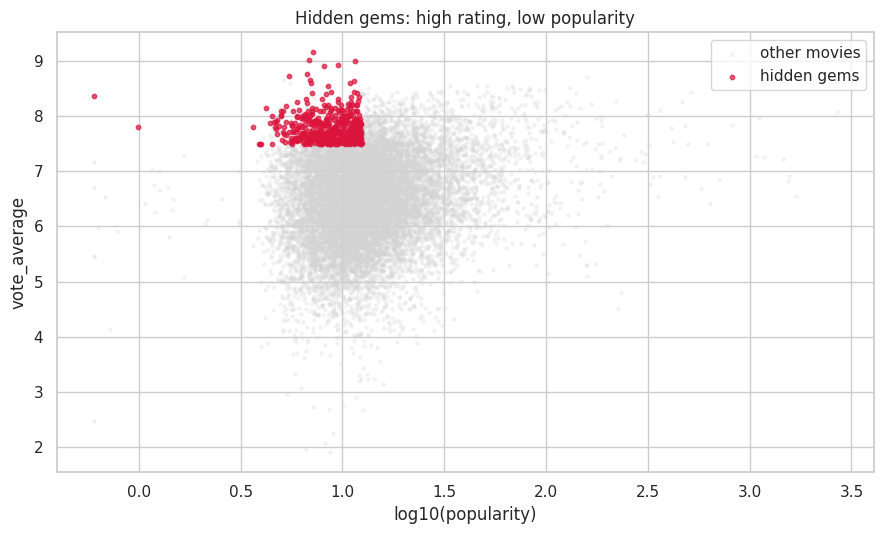

In [ ]:
# ======================================================================
# INSIGHT D3 — Hidden gems.
# Highly rated by BOTH TMDB and IMDb (>= 7.5 each), enough votes to trust the rating
# (>= MIN_VOTES), but LOW popularity (below the median of reliable movies).
# We rank them by the average of the two ratings and also show the best gem per genre.
# Use this as a recommendation list.
# ======================================================================
pop_median = df_rel["popularity"].median()
gems = df_rel[(df_rel["vote_average"] >= 7.5) & (df_rel["averageRating"] >= 7.5) & (df_rel["popularity"] < pop_median)].copy()
gems["gem_score"] = (gems["vote_average"] + gems["averageRating"]) / 2
gems = gems.sort_values("gem_score", ascending=False)
print(f"Median popularity (reliable movies): {pop_median:.1f} | hidden gems found: {len(gems)}")

show = ["title", "release_year", "genres", "directors", "vote_average", "averageRating", "vote_count", "popularity"]
print("Top 25 hidden gems:")
display(gems[show].head(25).round(2).reset_index(drop=True))

non_fiction = ["Music", "Documentary", "TV Movie"]
films_only = gems[~gems["genres"].apply(lambda s: any(g in s.split(", ") for g in non_fiction))]
print(f"Top 15 hidden gems excluding Music / Documentary / TV Movie ({len(films_only)} such gems):")
display(films_only[show].head(15).round(2).reset_index(drop=True))

gg = explode_list(gems, "genres", "genre")
best_per_genre = gg.sort_values("gem_score", ascending=False).groupby("genre").head(1).sort_values("genre")
print("Best hidden gem per genre:")
display(best_per_genre[["genre", "title", "release_year", "vote_average", "averageRating", "vote_count"]].round(2).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(np.log10(df_rel["popularity"]), df_rel["vote_average"], s=5, alpha=0.2, color="lightgray", label="other movies")
ax.scatter(np.log10(gems["popularity"]), gems["vote_average"], s=10, alpha=0.7, color="crimson", label="hidden gems")
ax.set_xlabel("log10(popularity)"); ax.set_ylabel("vote_average"); ax.set_title("Hidden gems: high rating, low popularity"); ax.legend()
plt.tight_layout(); plt.show()


> 💡 **Insight.** **442 hidden gems** meet the rule (7.5+ on both TMDB and IMDb, at least 100 votes, popularity below the median of 12.4). The raw list is dominated by concert films and music documentaries (Nirvana, Queen, BTS, Taylor Swift), which often have very devoted fans, so treat their ratings with some caution. **322 gems remain** after excluding Music, Documentary and TV Movie. The best of those include *Doctor Who: The Day of the Doctor*, *The Human Condition III*, *The Chaos Class*, *Macario*, *Duck Amuck*, *Bo Burnham: Inside*, *Apur Sansar* and *Samurai Rebellion*. Note that *The Godfather Trilogy: 1901-1980* ranks first because it is a compilation release, not a standalone film. The best-per-genre table can serve as a ready recommendation list.

### E. Genre Chemistry & Creative Views
_Which genres work well together, and a few different ways of looking at the data. Every graph here has a short "how to read it" line in its code cell and a written explanation right under it._

Genre pairs with >= 40 movies: 100


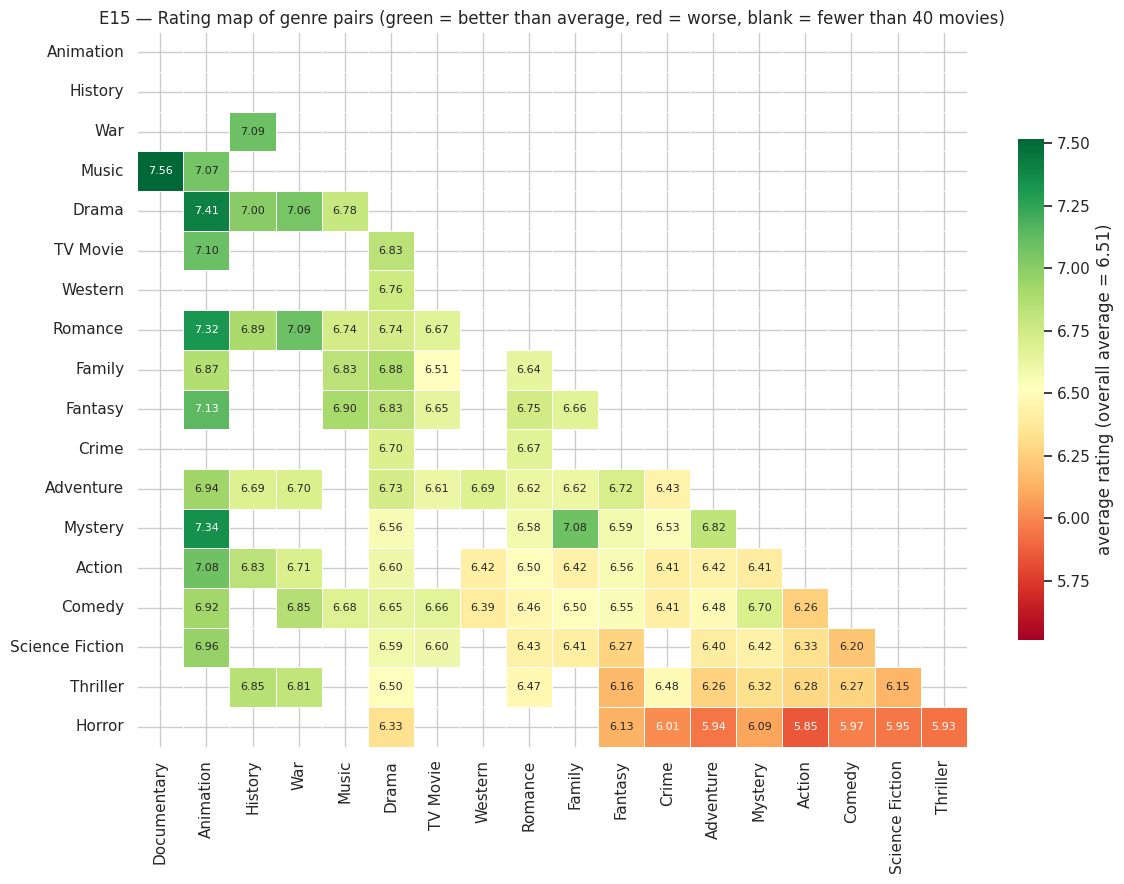

In [ ]:
# ======================================================================
# INSIGHT E1 — Genre combinations (graph 1: the "rating map").
# For every pair of genres that appears together in at least 40 reliable movies we compute
# the average rating of those movies. The heatmap is a map of all pairs:
#   row genre x column genre = average rating of movies that have BOTH genres.
# Green = rated above the overall average, red = below. Blank = fewer than 40 movies.
# Genres are sorted from best-rated (top/left) to worst-rated (bottom/right).
# ======================================================================
single = explode_list(df_rel, "genres", "genre").groupby("genre")["vote_average"].mean()

rows = []
for _, r in df_rel[["genres", "vote_average"]].iterrows():
    gl = sorted(set(r["genres"].split(", ")))
    for a, b in combinations(gl, 2):
        rows.append((a, b, r["vote_average"]))
pairs = pd.DataFrame(rows, columns=["g1", "g2", "rating"])
pair_stats = pairs.groupby(["g1", "g2"]).agg(n=("rating", "count"), mean_rating=("rating", "mean")).query("n >= 40").reset_index()
pair_stats["pair"] = pair_stats["g1"] + " + " + pair_stats["g2"]
pair_stats["expected"] = (pair_stats["g1"].map(single) + pair_stats["g2"].map(single)) / 2
pair_stats["synergy"] = pair_stats["mean_rating"] - pair_stats["expected"]
print("Genre pairs with >= 40 movies:", len(pair_stats))

order = single.sort_values(ascending=False).index.tolist()
mat = pd.DataFrame(np.nan, index=order, columns=order)
for _, r in pair_stats.iterrows():
    mat.loc[r["g1"], r["g2"]] = r["mean_rating"]; mat.loc[r["g2"], r["g1"]] = r["mean_rating"]
mat = mat.iloc[1:, :-1]                                    # drop the empty first row / last column
mask = np.triu(np.ones_like(mat, dtype=bool), k=1) | mat.isna()      # show each pair only once

overall = df_rel["vote_average"].mean()
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(mat, mask=mask, annot=True, fmt=".2f", annot_kws={"size": 8}, cmap="RdYlGn", center=overall,
            vmin=overall - 1, vmax=overall + 1, linewidths=0.5, linecolor="white",
            cbar_kws={"label": f"average rating (overall average = {overall:.2f})", "shrink": 0.7}, ax=ax)
ax.set_title("E15 — Rating map of genre pairs (green = better than average, red = worse, blank = fewer than 40 movies)")
plt.tight_layout(); plt.show()

> 📖 **How to read the rating map.** Pick a genre on the left and another one at the bottom: the cell where they meet is the **average rating of the movies that have both genres**. The number is written inside. **Green = rated higher than the overall average (6.51), red = lower.** Blank cells mean fewer than 40 movies, so we do not trust them. Genres are sorted from best-rated (top/left) to worst-rated (bottom/right), so the green should gather in the top-left corner and the red in the bottom-right.
>
> 🔎 **What it shows.** The greenest cells are in the **Animation column** (Animation + Drama 7.41, + Mystery 7.34, + Romance 7.32) and **Documentary + Music** (7.56). The reddest cells are all in the **Horror row** at the bottom (Action + Horror 5.85, Adventure + Horror 5.94, Horror + Thriller 5.93).

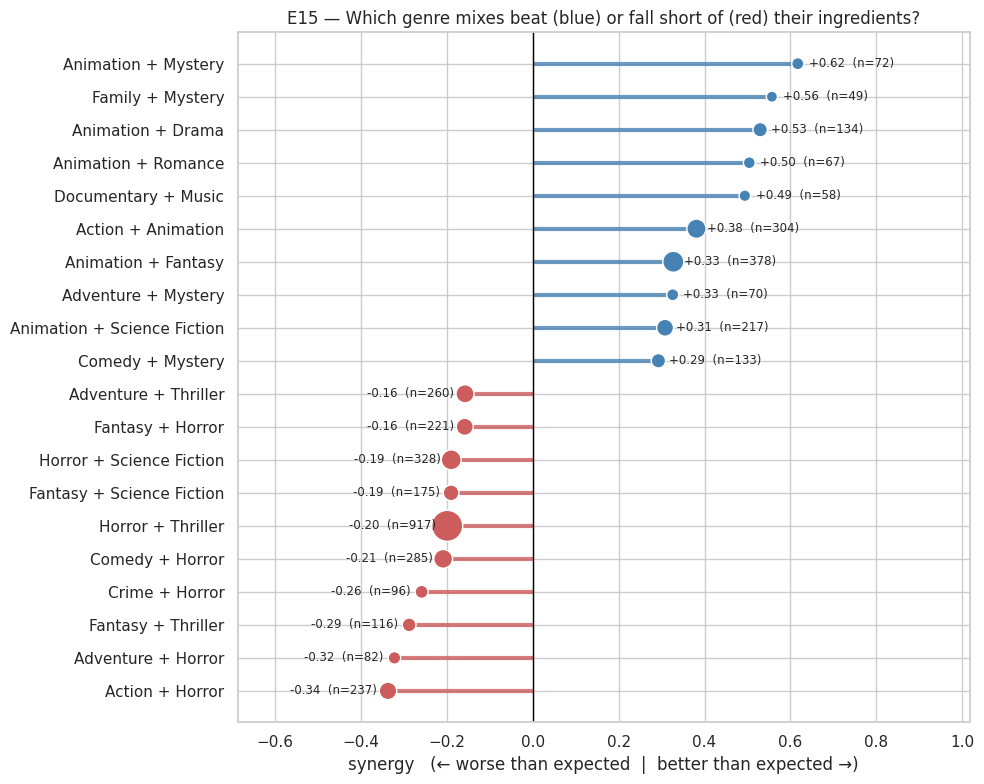

In [ ]:
# ======================================================================
# INSIGHT E2 — Genre combinations (graph 2: "synergy").
# synergy = (average rating of the pair) − (average of the two single-genre ratings).
#   > 0 : the mix is BETTER than you would expect from its two parts (blue)
#   < 0 : the mix is WORSE than expected (red)
# The chart shows the 10 best and 10 worst combinations. n = number of movies behind each dot.
# ======================================================================
top_syn = pair_stats.sort_values("synergy", ascending=False).head(10)
low_syn = pair_stats.sort_values("synergy").head(10)
both = pd.concat([top_syn, low_syn.iloc[::-1]])
both = both.sort_values("synergy")

fig, ax = plt.subplots(figsize=(10, 8))
colors = np.where(both["synergy"] >= 0, "steelblue", "indianred")
ax.hlines(both["pair"], 0, both["synergy"], color=colors, lw=3, alpha=0.8)
ax.scatter(both["synergy"], both["pair"], s=both["n"] / 2 + 40, color=colors, zorder=3, edgecolor="white")
for _, r in both.iterrows():
    ax.text(r["synergy"] + (0.025 if r["synergy"] >= 0 else -0.025), r["pair"], f"{r['synergy']:+.2f}  (n={int(r['n'])})",
            va="center", ha="left" if r["synergy"] >= 0 else "right", fontsize=8.5)
ax.axvline(0, color="black", lw=1)
ax.set_xlim(both["synergy"].min() - 0.35, both["synergy"].max() + 0.4)
ax.set_xlabel("synergy   (← worse than expected  |  better than expected →)")
ax.set_title("E15 — Which genre mixes beat (blue) or fall short of (red) their ingredients?")
plt.tight_layout(); plt.show()

> 📖 **How to read the synergy chart.** *Synergy* answers: "is this mix better or worse than I would guess from its two genres?" We take the average rating of the two genres on their own (the *expected* rating) and compare it with the real rating of the movies that mix them. **Example:** the ratings of Animation and of Mystery on their own average out to 6.72, but Animation + Mystery movies average **7.34**, so the synergy is **+0.62**. A dot to the right (blue) = the mix works better than its parts; to the left (red) = it works worse. The size of the dot and the `n` show how many movies it is based on.
>
> 🔎 **What it shows.** 9 of the 10 best mixes contain **Animation or Mystery** (Animation + Mystery +0.62, Family + Mystery +0.56, Animation + Drama +0.53). **Horror is in 7 of the 10 worst mixes, and the worst is Action + Horror (−0.34)**: adding Horror to another genre tends to pull the rating *below* what you would expect.

In [ ]:
# ======================================================================
# INSIGHT E2 — the tables behind the two graphs.
# ======================================================================
best = pair_stats.sort_values("mean_rating", ascending=False).head(10)
worst = pair_stats.sort_values("mean_rating").head(10)
print("Best-rated pairs:");  display(best[["pair", "n", "mean_rating"]].round(2))
print("Worst-rated pairs:"); display(worst[["pair", "n", "mean_rating"]].round(2))
print("Highest synergy:");   display(pair_stats.sort_values("synergy", ascending=False)[["pair", "n", "mean_rating", "expected", "synergy"]].head(10).round(2))
print("Lowest synergy:");    display(pair_stats.sort_values("synergy")[["pair", "n", "mean_rating", "expected", "synergy"]].head(10).round(2))

Best-rated pairs:


,pair,n,mean_rating
57,Documentary + Music,58,7.56
31,Animation + Drama,134,7.41
35,Animation + Mystery,72,7.34
36,Animation + Romance,67,7.32
33,Animation + Fantasy,378,7.13
38,Animation + TV Movie,49,7.10
85,History + War,147,7.09
96,Romance + War,50,7.09
72,Family + Mystery,49,7.08
1,Action + Animation,304,7.08


Worst-rated pairs:


,pair,n,mean_rating
8,Action + Horror,237,5.85
88,Horror + Thriller,917,5.93
22,Adventure + Horror,82,5.94
87,Horror + Science Fiction,328,5.95
43,Comedy + Horror,285,5.97
53,Crime + Horror,96,6.01
86,Horror + Mystery,388,6.09
76,Fantasy + Horror,221,6.13
98,Science Fiction + Thriller,378,6.15
82,Fantasy + Thriller,116,6.16


Highest synergy:


,pair,n,mean_rating,expected,synergy
35,Animation + Mystery,72,7.34,6.72,0.62
72,Family + Mystery,49,7.08,6.53,0.56
31,Animation + Drama,134,7.41,6.88,0.53
36,Animation + Romance,67,7.32,6.81,0.50
57,Documentary + Music,58,7.56,7.06,0.49
1,Action + Animation,304,7.08,6.70,0.38
33,Animation + Fantasy,378,7.13,6.81,0.33
23,Adventure + Mystery,70,6.82,6.49,0.33
37,Animation + Science Fiction,217,6.96,6.66,0.31
45,Comedy + Mystery,133,6.70,6.41,0.29


Lowest synergy:


,pair,n,mean_rating,expected,synergy
8,Action + Horror,237,5.85,6.18,-0.34
22,Adventure + Horror,82,5.94,6.26,-0.32
82,Fantasy + Thriller,116,6.16,6.45,-0.29
53,Crime + Horror,96,6.01,6.27,-0.26
43,Comedy + Horror,285,5.97,6.18,-0.21
88,Horror + Thriller,917,5.93,6.13,-0.20
80,Fantasy + Science Fiction,175,6.27,6.46,-0.19
87,Horror + Science Fiction,328,5.95,6.14,-0.19
76,Fantasy + Horror,221,6.13,6.29,-0.16
27,Adventure + Thriller,260,6.26,6.42,-0.16


> 💡 **Insight.**
> - **Best pairs:** Documentary + Music (**7.56**), Animation + Drama (7.41), Animation + Mystery (7.34) and Animation + Romance (7.32). **Animation is in 6 of the top 10 pairs**.
> - **Worst pairs:** Action + Horror (**5.85**), Horror + Thriller (5.93, also the most common bad pair with 917 movies) and Adventure + Horror (5.94). **Horror is in 8 of the 10 worst pairs**.
> - **Synergy:** Animation + Mystery scores **0.62 above** the average of its two genres, Family + Mystery 0.56 and Animation + Drama 0.53. The biggest negative synergy is Action + Horror (**-0.34**), meaning that mixing horror with another genre does worse than expected. Mystery combines well with many genres (Animation, Family, Adventure, Comedy).

#### E3 — The genre network (creative plot)

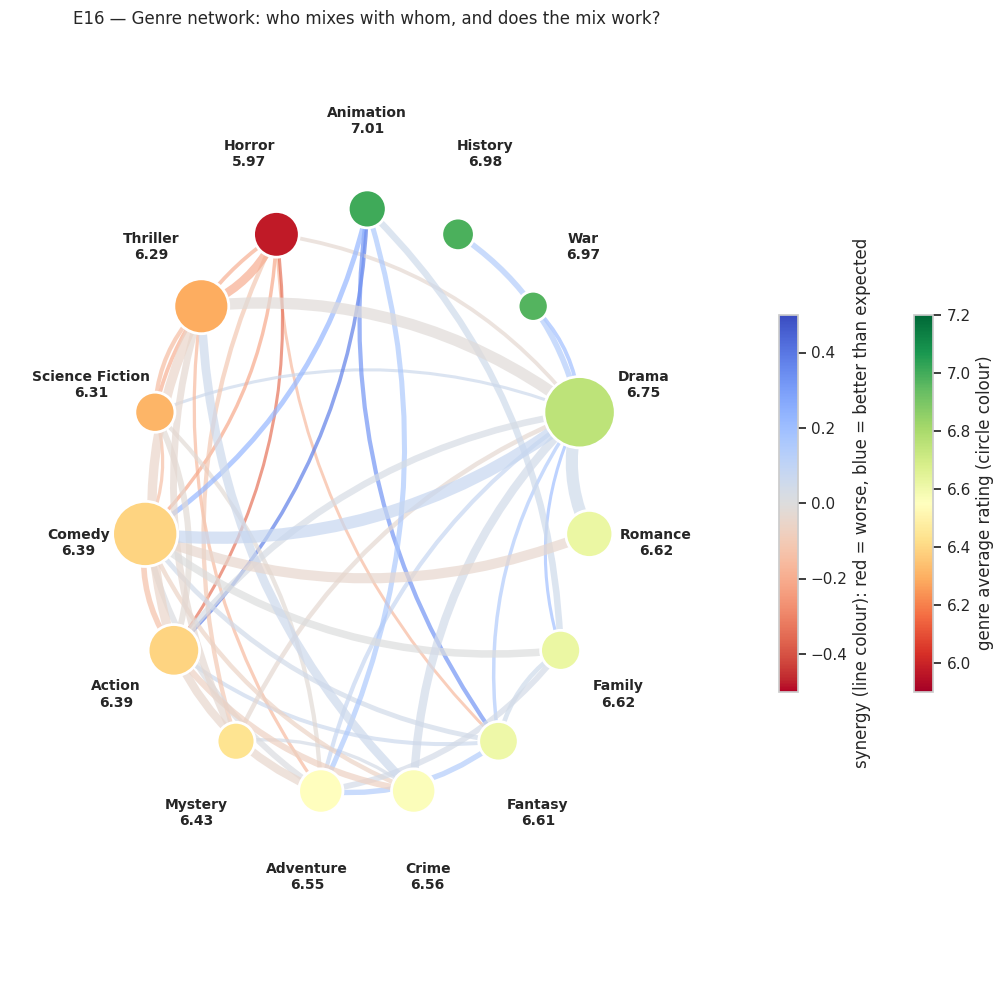

In [ ]:
# ======================================================================
# INSIGHT E3 — The genre network (creative plot).
# Every genre is a circle placed on a ring, ordered from the best-rated genre (top, going clockwise) to the worst-rated one.
# A curved line joins two genres that often appear in the same movie.
#   circle size   = how many reliable movies have that genre
#   circle colour = average rating of the genre (green = high, red = low)
#   line width    = how many movies combine the two genres
#   line colour   = synergy (blue = the mix beats its parts, red = the mix is worse than expected)
# Only the 45 most common pairs are drawn, so the picture stays readable.
# ======================================================================
import networkx as nx
from matplotlib.colors import Normalize
from matplotlib import cm

gstat = explode_list(df_rel, "genres", "genre").groupby("genre").agg(n=("id", "count"), rating=("vote_average", "mean"))
edges = pair_stats.sort_values("n", ascending=False).head(45)

G = nx.Graph()
for _, r in edges.iterrows():
    G.add_edge(r["g1"], r["g2"], n=r["n"], synergy=r["synergy"])
ring = [g_ for g_ in gstat["rating"].sort_values(ascending=False).index if g_ in G.nodes]
angle = {g_: np.pi / 2 - 2 * np.pi * i / len(ring) for i, g_ in enumerate(ring)}      # start at the top, clockwise
pos = {g_: (np.cos(a), np.sin(a)) for g_, a in angle.items()}

fig, ax = plt.subplots(figsize=(11, 10))
elist = sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["n"])                           # thin lines first, thick on top
w_ = np.array([G[u][v]["n"] for u, v in elist]); syn_ = np.array([G[u][v]["synergy"] for u, v in elist])
syn_norm = Normalize(vmin=-0.5, vmax=0.5); rat_norm = Normalize(vmin=5.9, vmax=7.2)
nx.draw_networkx_edges(G, pos, edgelist=elist, ax=ax, width=0.8 + 8 * w_ / w_.max(), edge_color=cm.coolwarm_r(syn_norm(syn_)),
                       alpha=0.7, arrows=True, arrowstyle="-", connectionstyle="arc3,rad=0.2")
nx.draw_networkx_nodes(G, pos, nodelist=ring, ax=ax, node_size=[gstat.loc[g_, "n"] / 2.5 + 300 for g_ in ring],
                       node_color=[gstat.loc[g_, "rating"] for g_ in ring], cmap="RdYlGn", vmin=5.9, vmax=7.2, edgecolors="white", linewidths=2)
for g_ in ring:
    x_, y_ = pos[g_]
    ax.text(x_ * 1.3, y_ * 1.3, f"{g_}\n{gstat.loc[g_, 'rating']:.2f}", ha="center", va="center", fontsize=10, fontweight="bold")
sm1 = cm.ScalarMappable(norm=rat_norm, cmap="RdYlGn"); sm1.set_array([])
sm2 = cm.ScalarMappable(norm=syn_norm, cmap="coolwarm_r"); sm2.set_array([])
fig.colorbar(sm1, ax=ax, shrink=0.4, pad=0.0, label="genre average rating (circle colour)")
fig.colorbar(sm2, ax=ax, shrink=0.4, pad=0.06, label="synergy (line colour): red = worse, blue = better than expected")
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.axis("off")
ax.set_title("E16 — Genre network: who mixes with whom, and does the mix work?")
plt.tight_layout(); plt.show()

> 📖 **How to read it.** Each circle is a genre, placed on a ring from the best-rated one (top, going clockwise) to the worst-rated one. The colour of the circle is its average rating (green = high, red = low) and its size is how many movies it has. A line between two circles means the two genres are often mixed in the same movie: **thick line = many movies, blue line = a mix that works better than expected, red line = a mix that works worse.**
>
> 🔎 **What it shows.** The thickest lines are the classic mixes (**Comedy + Drama** with 1,356 movies, **Drama + Romance** 1,349, **Drama + Thriller** 1,254) and they are almost neutral in colour: they are common but neither better nor worse than expected. **Red lines gather around Horror** (Action + Horror, Horror + Thriller, Comedy + Horror, Horror + Sci-Fi), and the strongest blue lines belong to **Animation** (Animation + Action, Animation + Fantasy). Following the ring clockwise from the top, the circles go from green (Animation, History, War) to red (Horror, just left of the top), so the ring order and the line colours tell the same story.

#### E4 — Streamgraph: the genre mix through time, from the 1920s (creative plot)

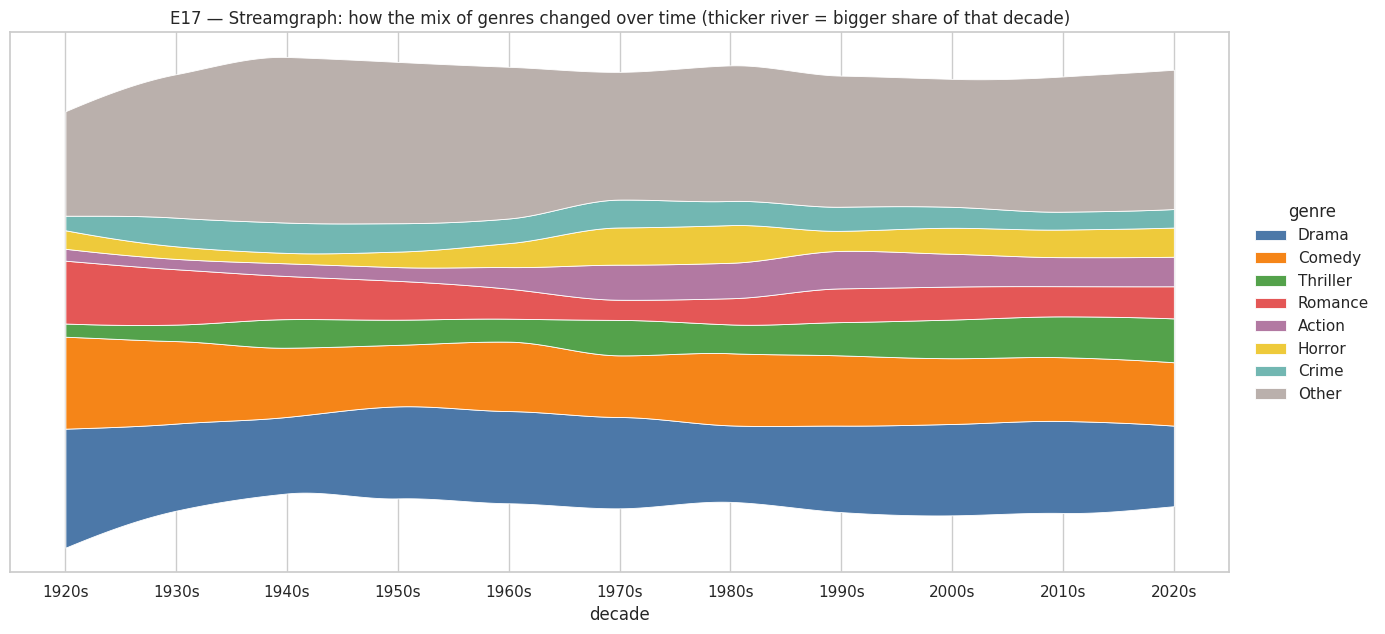

Share (%) of genre tags per decade:


decade,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010,2020
genre,,,,,,,,,,,
Drama,27.3,19.9,17.5,21.1,21.1,20.9,17.5,19.8,20.9,21.1,18.5
Comedy,21.1,18.9,15.9,14.1,15.9,14.1,16.5,16.1,15.1,14.6,14.5
Thriller,3.0,3.8,6.5,5.8,5.3,8.1,6.6,7.6,8.9,9.4,10.1
Romance,14.4,12.7,9.9,8.9,6.9,4.6,6.0,7.7,7.6,6.9,7.4
Action,2.7,2.4,2.9,3.1,4.9,8.0,8.1,8.6,7.5,6.7,6.8
Horror,4.2,2.9,2.4,3.6,5.5,8.5,8.6,4.6,6.0,6.3,6.7
Crime,3.3,6.6,6.9,6.5,5.6,6.4,5.5,5.5,4.8,4.1,4.2
Other,23.9,32.9,37.9,37.0,34.8,29.3,31.1,30.0,29.3,31.0,31.9


In [ ]:
# ======================================================================
# INSIGHT E4 — Streamgraph of genres through time (creative plot).
# Every coloured "river" is a genre; its thickness is the share of all genre tags in that decade
# (so the total thickness is always 100%). A river getting thicker = the genre became more common.
# All movies are used (no vote filter) because this is about what was made, not how it was rated.
# Only decades from the 1920s on (with at least 30 movies) are shown; the 7 biggest genres are named, the rest are grouped as "Other".
# ======================================================================
from scipy.interpolate import PchipInterpolator

gd = explode_list(df_ins, "genres", "genre")
cnt = gd.groupby(["decade", "genre"]).size().unstack(fill_value=0)
cnt = cnt[(df_ins.groupby("decade").size().reindex(cnt.index) >= 30) & (cnt.index >= 1920)]
top_genres = cnt.sum().sort_values(ascending=False).head(7).index.tolist()
cnt["Other"] = cnt.drop(columns=top_genres).sum(axis=1)
cnt = cnt[top_genres + ["Other"]]
share = cnt.div(cnt.sum(axis=1), axis=0) * 100

xs = share.index.values.astype(float)
xf = np.linspace(xs.min(), xs.max(), 300)
smooth = np.vstack([np.clip(PchipInterpolator(xs, share[c].values)(xf), 0, None) for c in share.columns])

palette = ["#4c78a8", "#f58518", "#54a24b", "#e45756", "#b279a2", "#eeca3b", "#72b7b2", "#bab0ac"]
fig, ax = plt.subplots(figsize=(14, 6.5))
ax.stackplot(xf, smooth, baseline="wiggle", colors=palette, labels=share.columns, edgecolor="white", linewidth=0.6)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="genre", frameon=False)
ax.set_xticks(xs); ax.set_xticklabels([f"{int(d)}s" for d in xs])
ax.set_yticks([]); ax.set_xlabel("decade")
ax.set_title("E17 — Streamgraph: how the mix of genres changed over time (thicker river = bigger share of that decade)")
plt.tight_layout(); plt.show()

print("Share (%) of genre tags per decade:")
display(share.round(1).T)

> 📖 **How to read it.** Each coloured "river" is a genre, and its **thickness at a given decade is its share of all the genre tags of that decade** (the table below the graph gives the exact numbers). A river that gets thicker over time = a genre that became more common; thinner = less common.
>
> 🔎 **What it shows.**
> - **Drama stays the biggest genre** in every decade (about 17–27%) and Comedy is second, but both shrink a little: Comedy from 21% in the 1920s to 14.5% in the 2020s.
> - **Romance fades**: from 14.4% of the genre tags in the 1920s to 7.4% in the 2020s.
> - **Thriller keeps growing**: 3% in the 1920s to 10% in the 2020s. **Action** jumps in the 1970s (from 4.9% to 8.0%) and stays between 6.7% and 8.6% afterwards.
> - **Horror peaks in the 1970s–80s** (about 8.5%) dips in the 1990s and then settles at about 6–7%.

#### E5 — Ridgeline: how ratings are spread in each decade (creative plot)

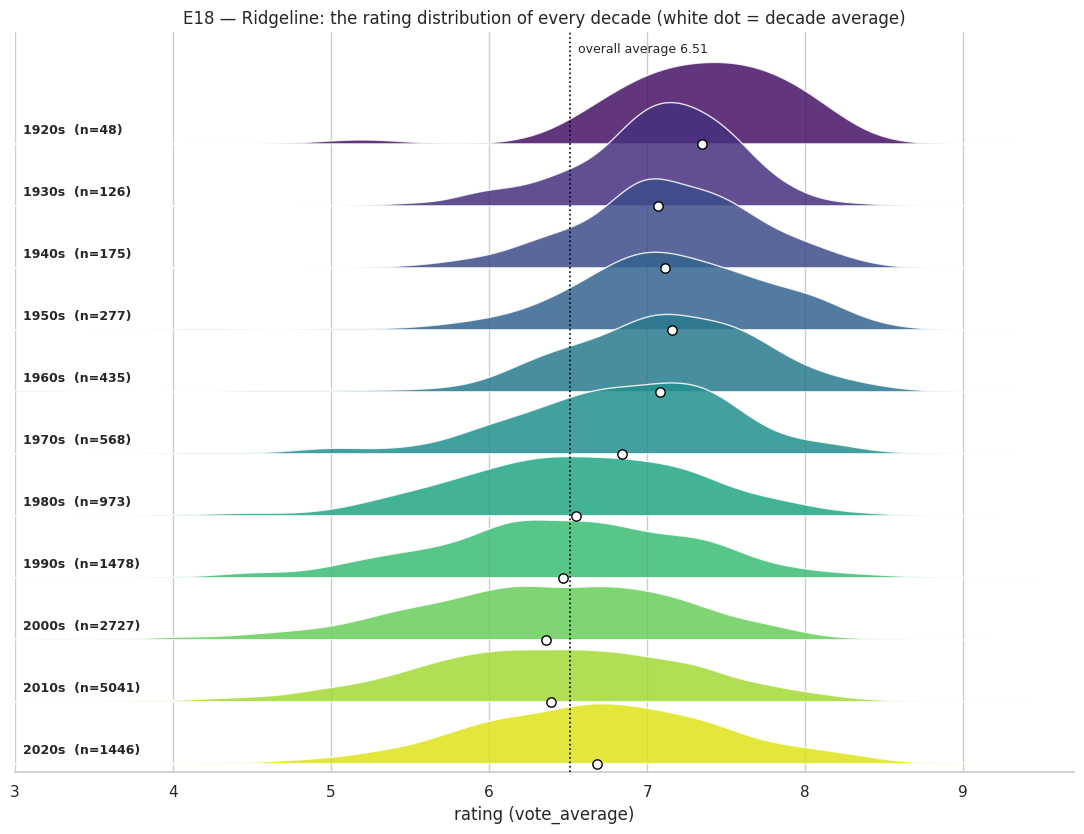

In [ ]:
# ======================================================================
# INSIGHT E5 — Ridgeline plot: how ratings are spread in each decade (creative plot).
# Each "mountain" is one decade (oldest at the top). Its shape shows how the ratings of that
# decade are distributed: a mountain further to the right = higher ratings; a wide mountain = very different
# opinions; a narrow one = ratings close together. The white dot marks the average. Reliable movies only (>=100 votes).
# ======================================================================
from scipy.stats import gaussian_kde

decs = list(dec_rel.index)
x = np.linspace(2, 10, 400)
kdes = {d: gaussian_kde(df_rel.loc[df_rel["decade"] == d, "vote_average"].dropna()) for d in decs}
ymax = max(k(x).max() for k in kdes.values())
step = 0.75
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(decs)))

fig, ax = plt.subplots(figsize=(11, 8.5))
for i, d in enumerate(decs):
    base = (len(decs) - 1 - i) * step
    y = kdes[d](x) / ymax * 1.25
    ax.fill_between(x, base, base + y, color=colors[i], alpha=0.85, zorder=i + 1, edgecolor="white", linewidth=1)
    m = dec_rel.loc[d, "mean_rating"]
    ax.scatter([m], [base], color="white", edgecolor="black", s=45, zorder=len(decs) + 2)
    ax.text(3.05, base + 0.08, f"{d}s  (n={int(dec_rel.loc[d, 'n'])})", fontsize=9, fontweight="bold", va="bottom")
ax.set_yticks([]); ax.set_xlim(3, 9.7); ax.set_xlabel("rating (vote_average)")
ax.axvline(df_rel["vote_average"].mean(), color="black", ls=":", lw=1.2, zorder=len(decs) + 5)
ax.text(df_rel["vote_average"].mean() + 0.05, len(decs) * step + 0.35, f"overall average {df_rel['vote_average'].mean():.2f}", fontsize=9, zorder=len(decs) + 6)
ax.set_ylim(-0.1, len(decs) * step + 0.6)
ax.set_title("E18 — Ridgeline: the rating distribution of every decade (white dot = decade average)")
sns.despine(left=True)
plt.tight_layout(); plt.show()

> 📖 **How to read it.** Every "mountain" is a decade (oldest at the top, newest at the bottom). **The further a mountain sits to the right, the higher the ratings of that decade; the wider it is, the more different the opinions.** The white dot is the average of the decade and the dotted vertical line is the overall average (6.51).
>
> 🔎 **What it shows.**
> - The mountains **slide to the left over time**: the average goes from about 7.1 (1930s–1960s) to a low of 6.36 in the 2000s, then back up to 6.68 in the 2020s (the same story as A2).
> - They also **get wider**: the spread of ratings grows from about 0.5 (1930s) to about 0.85 (2010s). Old movies with 100+ votes are mostly well-known classics, so their ratings are bunched together; modern decades include many more movies, good and bad.
> - The 1920s mountain is bumpy and tall because it only has 48 movies; do not read too much into its shape.

#### E6 — Genre fingerprints (creative plot)

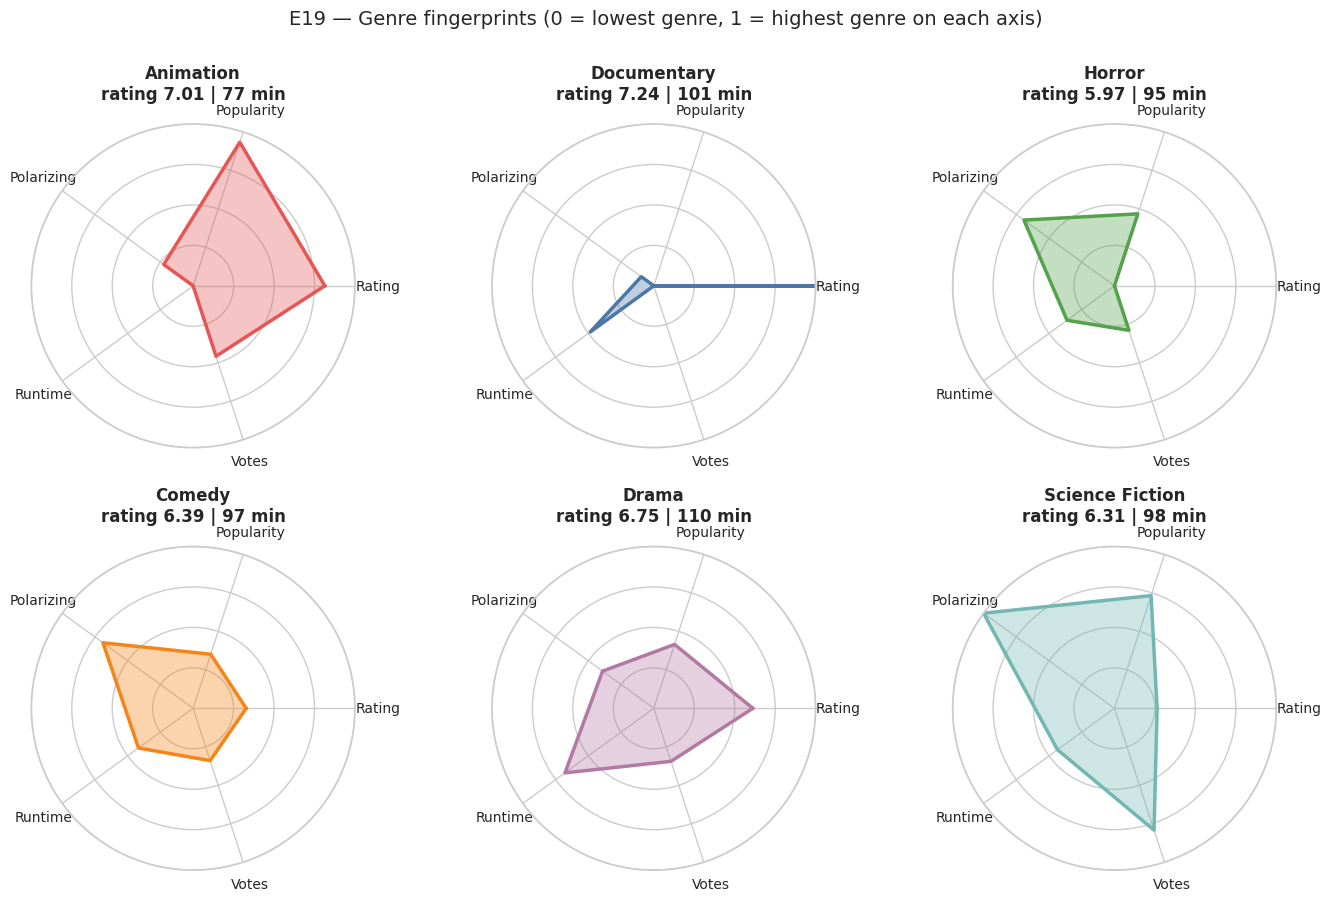

,Rating,Popularity,Polarizing,Runtime,Votes
genre,,,,,
Animation,7.01,16.87,0.68,76.65,331.0
Documentary,7.24,8.12,0.65,100.82,181.5
Horror,5.97,12.51,0.81,94.69,276.0
Comedy,6.39,11.42,0.81,97.43,292.5
Drama,6.75,12.01,0.73,110.43,294.0
Science Fiction,6.31,14.99,0.90,98.32,440.0


In [ ]:
# ======================================================================
# INSIGHT E6 — Genre "fingerprints" (radar charts, creative plot).
# Each genre gets a 5-point star showing its personality, using genre_stats from A1 plus the average runtime.
# Every axis is rescaled from 0 (the lowest genre) to 1 (the highest genre), so shapes are comparable:
#   Rating = average rating | Popularity = median popularity | Polarizing = spread of ratings
#   Runtime = average length | Votes = median number of votes (audience size). Reliable movies only.
# ======================================================================
g_all = explode_list(df_rel, "genres", "genre")
prof = genre_stats[["mean_rating", "median_popularity", "std_rating", "median_votes"]].copy()
prof["runtime"] = g_all.groupby("genre")["runtime"].mean()
prof = prof[["mean_rating", "median_popularity", "std_rating", "runtime", "median_votes"]]
prof.columns = ["Rating", "Popularity", "Polarizing", "Runtime", "Votes"]
norm = (prof - prof.min()) / (prof.max() - prof.min())

chosen = ["Animation", "Documentary", "Horror", "Comedy", "Drama", "Science Fiction"]
colors = ["#e45756", "#4c78a8", "#54a24b", "#f58518", "#b279a2", "#72b7b2"]
angles = np.linspace(0, 2 * np.pi, len(norm.columns), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(14, 9), subplot_kw={"projection": "polar"})
for ax, g_name, col in zip(axes.ravel(), chosen, colors):
    vals = norm.loc[g_name].tolist() + [norm.loc[g_name].iloc[0]]
    ax.plot(angles, vals, color=col, lw=2.5); ax.fill(angles, vals, color=col, alpha=0.35)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(norm.columns, fontsize=10)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0]); ax.set_yticklabels([]); ax.set_ylim(0, 1)
    ax.set_title(f"{g_name}\nrating {prof.loc[g_name, 'Rating']:.2f} | {prof.loc[g_name, 'Runtime']:.0f} min", fontsize=12, fontweight="bold", pad=18)
fig.suptitle("E19 — Genre fingerprints (0 = lowest genre, 1 = highest genre on each axis)", fontsize=14, y=1.0)
plt.tight_layout(); plt.show()
display(prof.loc[chosen].round(2))

> 📖 **How to read it.** Each star is the "personality" of one genre on five axes. The **further a corner reaches toward the outer ring, the higher that genre ranks on this axis compared with all the other genres** (0 = lowest genre, 1 = highest genre). Compare the *shapes*, not only the size.
>
> 🔎 **What it shows.**
> - **Documentary:** a single long spike on *Rating* (the best-rated genre, 7.24) with everything else near zero: the best-rated genre is also the **least popular and has the fewest votes**.
> - **Animation:** high rating (7.01), high popularity, **the shortest runtime of all genres (77 minutes)** and low polarization: the all-round crowd-pleaser.
> - **Horror:** the lowest rating of all genres (5.97) with high polarization.
> - **Science Fiction:** the **most polarizing genre** (rating spread 0.90), with high popularity and many votes but a below-average rating (6.31).
> - **Drama:** the longest runtime of these six (110 minutes) and a solid rating (6.75); **Comedy** is middling on most axes.

#### E7 — The release calendar as a circle (creative plot)

               Jan     Feb     Mar     Apr     May      Jun     Jul      Aug      Sep      Oct     Nov      Dec
share_%       8.40    7.10     8.2    7.60    7.30     7.20    6.50     7.90    10.80    10.90     8.9     9.10
avg_rating    6.38    6.44     6.5    6.42    6.52     6.51    6.48     6.45     6.57     6.53     6.6     6.67
n_reliable  825.00  951.00  1117.0  980.00  939.00  1006.00  966.00  1153.00  1515.00  1424.00  1114.0  1328.00


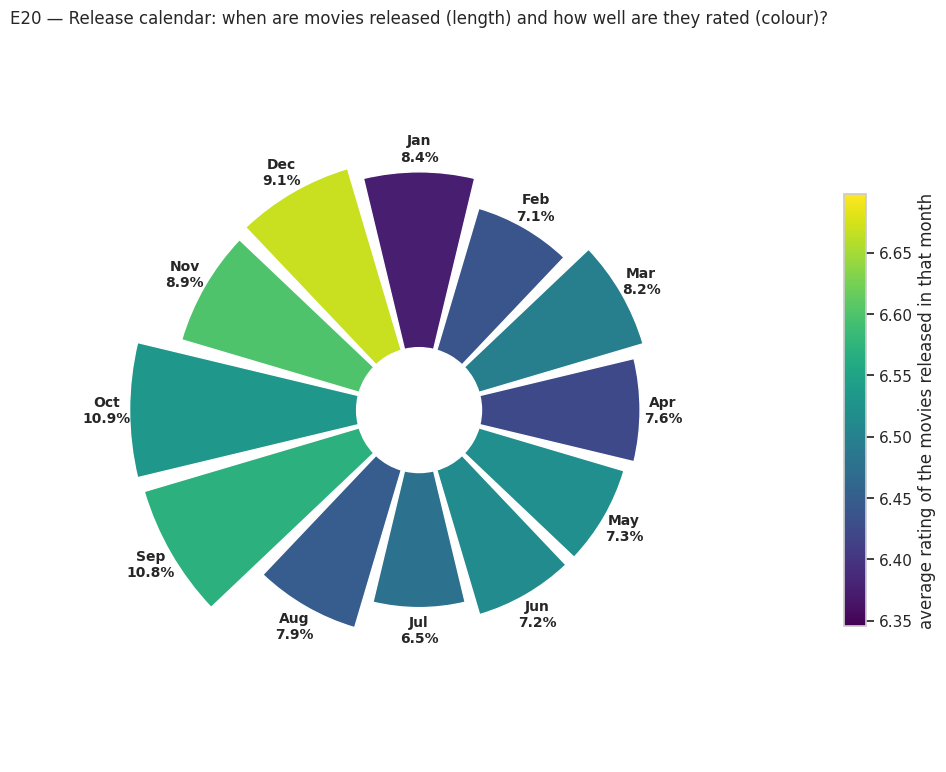

In [ ]:
# ======================================================================
# INSIGHT E7 — The release calendar as a circle (creative plot).
# Each bar is one month (January at the top, clockwise).
#   bar length = share of all movies released in that month
#   bar colour = average rating of the reliable movies (>=100 votes) released in that month
# Movies with no release month are ignored.
# ======================================================================
from matplotlib import cm
from matplotlib.colors import Normalize

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
m_all = df_ins["release_date"].dt.month.dropna().astype(int).value_counts().sort_index()
m_share = m_all / m_all.sum() * 100
m_rate = df_rel.assign(m=df_rel["release_date"].dt.month).dropna(subset=["m"]).groupby("m")["vote_average"].agg(["mean", "count"])
print(pd.DataFrame({"share_%": m_share.round(1), "avg_rating": m_rate["mean"].round(2), "n_reliable": m_rate["count"]}).set_index(pd.Index(months)).T)

theta = np.linspace(0, 2 * np.pi, 12, endpoint=False)
norm_c = Normalize(vmin=m_rate["mean"].min() - 0.03, vmax=m_rate["mean"].max() + 0.03)
fig = plt.figure(figsize=(9.5, 9))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
bars = ax.bar(theta, m_share.values, width=2 * np.pi / 12 * 0.9, bottom=3, color=cm.viridis(norm_c(m_rate["mean"].values)), edgecolor="white")
for t, s, m in zip(theta, m_share.values, months):
    ax.text(t, 3 + s + 1.1, f"{m}\n{s:.1f}%", ha="center", va="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 3 + m_share.max() + 3); ax.set_yticks([]); ax.set_xticks([]); ax.spines["polar"].set_visible(False); ax.grid(False)
sm = cm.ScalarMappable(norm=norm_c, cmap="viridis"); sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.08, label="average rating of the movies released in that month")
ax.set_title("E20 — Release calendar: when are movies released (length) and how well are they rated (colour)?", pad=25)
plt.tight_layout(); plt.show()

> 📖 **How to read it.** The circle is a year: January at the top, going clockwise to December. **The longer the bar, the more movies are released in that month; the brighter (yellow-green) the colour, the higher the average rating of those movies.** The share of movies is written under each month name.
>
> 🔎 **What it shows.**
> - **September and October are the busiest months** (10.8% and 10.9%, together 21.7% of all releases) and **July is the quietest** (6.5%).
> - **Movies released in November and December are rated highest** (6.60 and 6.67), while **January** (6.38) and April (6.42) are the lowest. The differences are small (about 0.3 points between the best and worst month), but they are consistent with the idea that stronger movies are released at the end of the year. This is only a pattern in the data, not proof of why.

## 4) Key findings

**Ratings and quality**
- Documentary, Animation, History and War are the best-rated genres; Horror, Thriller and Sci-Fi the worst. Animation is the only genre that is both top-rated and very popular.
- Average ratings fall from about 7.1–7.3 in early decades to about 6.4 in the 2000s–2010s (partly survivorship of old classics).
- TMDB and IMDb agree strongly (0.86) but TMDB has become more generous for recent movies (+0.65 in the 2020s).
- Longer movies are rated higher (7.23 for 140+ minutes vs 6.21 for 90–99), probably because long movies are more ambitious projects.
- The TMDB–IMDb gap flips with time: IMDb is higher for old movies (about −0.2 to −0.3), TMDB for recent ones (+0.16 in the 2010s, +0.65 in the 2020s).

**Money**
- Budget does not predict rating (Spearman -0.06), but it does predict revenue (0.65). Two out of three movies earn more than their budget.
- Medians peaked in the 1990s and the revenue multiple has dropped from about 6× (1970s) to about 1.5–1.9×, but recording bias and no inflation adjustment make this a trend to read carefully.

**People and content**
- Top-rated directors and actors are mostly classic international auteurs, their regular actors and anime voice actors.
- Famous casts bring 5× to 8× more votes and about 2.6× more popularity, but no higher rating.
- Anime, film noir, silent and black-and-white themes score highest; slasher, found footage, spoof and creature themes score lowest.
- Taglines and homepages go with about twice the median votes and popularity, even among recent movies.

**Recommendations and combinations**
- 322 hidden fiction/non-music gems are available as a recommendation list (442 including music and documentaries).
- Animation mixes well with other genres; mixing Horror with anything pulls ratings down.

**Creative views (section E)**
- Genre network and rating map: the thickest links are the classic mixes (Comedy + Drama, Drama + Romance); the red links all gather around Horror, the blue ones around Animation.
- Streamgraph: Drama is the biggest genre in every decade; Romance fades (14% to 7%) while Thriller grows (3% to 10%).
- Ridgeline: rating distributions slide left over time and get wider (spread about 0.5 in the 1930s vs 0.85 in the 2010s).
- Genre fingerprints: Documentary is the best rated but the least popular; Animation is the short, popular crowd-pleaser; Sci-Fi is the most polarizing.
- Release calendar: September and October are the busiest months (22% of releases) and November/December releases are rated highest (6.60–6.67).

**Data caveats**
- Only 27% of movies have 100+ votes; budget and revenue are recorded for only about 20% and are not inflation adjusted.
- Everything here is association, not causation.
- If this data is later used to *predict* ratings, remember that vote counts, popularity and revenue are outcomes (see the leakage note in section 2).

# Preprocessing

initial cols to drop


In [ ]:
# save the lookup table, then drop what the models shouldn't see
meta = df[["id", "tconst", "title", "poster_path"]].copy()
df["has_homepage"] = df.homepage.notna().astype(int)
df = df.drop(columns=["id", "tconst", "backdrop_path", "poster_path", "homepage"])

# drop columns that became constant after filtering
df = df.drop(columns="status")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49928 entries, 0 to 49927
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 49928 non-null  object 
 1   vote_average          49928 non-null  float64
 2   vote_count            49928 non-null  int64  
 3   release_date          49928 non-null  object 
 4   revenue               49928 non-null  int64  
 5   runtime               49928 non-null  int64  
 6   adult                 49928 non-null  bool   
 7   budget                49928 non-null  int64  
 8   original_language     49928 non-null  object 
 9   original_title        49928 non-null  object 
 10  overview              49928 non-null  object 
 11  popularity            49928 non-null  float64
 12  tagline               24261 non-null  object 
 13  genres                49928 non-null  object 
 14  production_companies  45162 non-null  object 
 15  production_countrie

**Dealing with missing values**

In [ ]:
# spoken_languages from original_language
single = df[df.spoken_languages.notna() & ~df.spoken_languages.str.contains(",", na=False)]
lang_map = single.groupby("original_language").spoken_languages.agg(lambda s: s.mode().iat[0])

m = df.spoken_languages.isna()
df.loc[m, "spoken_languages"] = df.loc[m, "original_language"].map(lang_map)

In [ ]:
# production_countries from companies
known = df.dropna(subset=["production_companies", "production_countries"])
pairs = (known.assign(company=known.production_companies.str.split(", "))
              .explode("company")[["company", "production_countries"]])
comp2country = pairs.groupby("company").production_countries.agg(lambda s: s.mode().iat[0])

def fill_country(companies):
    votes = pd.Series([comp2country.get(c) for c in companies.split(", ")]).dropna()
    return votes.mode().iat[0] if len(votes) else np.nan

m = df.production_countries.isna() & df.production_companies.notna()
df.loc[m, "production_countries"] = df.loc[m, "production_companies"].map(fill_country)

In [ ]:
#kNN: keywords from similar movies
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from collections import Counter
df = df.reset_index(drop=True)                  # keep X and df aligned (do this after ALL row filtering)

X = TfidfVectorizer(stop_words="english", min_df=3, max_features=50000).fit_transform(
        df.overview.fillna("") + " " + df.genres.fillna(""))

has  = df.keywords.notna().to_numpy()
miss = np.where(~has)[0]
print("rows to impute:", len(miss))

if len(miss):
    nn = NearestNeighbors(n_neighbors=15, metric="cosine").fit(X[has])
    kw_known = df.keywords[has].str.split(", ").tolist()

    def impute_keywords(rows, top=5, batch=2000):
        out = []
        for s in range(0, len(rows), batch):
            dist, idx = nn.kneighbors(X[rows[s:s + batch]])
            for d, ix in zip(dist, idx):
                c = Counter()
                for dd, i in zip(d, ix):
                    for k in kw_known[i]:
                        c[k] += 1 - dd                    # similarity-weighted vote
                out.append(", ".join(k for k, _ in c.most_common(top)))
        return out

    df["keywords_imputed"] = (~has).astype(int)
    kw = df["keywords"].to_numpy(dtype=object)
    kw[miss] = impute_keywords(miss)
    df["keywords"] = kw

rows to impute: 12960


In [ ]:
df["has_tagline"] = df.tagline.notna().astype(int)
df["tagline_len"] = df.tagline.fillna("").str.split().str.len()      # 0 when missing
df["text"] = (df.overview.fillna("") + " " + df.tagline.fillna("") + " "
                 + df.keywords.fillna("").str.replace(",", " ")).str.strip()

In [ ]:
print(df.groupby("has_tagline")[["vote_average", "vote_count", "budget"]].median())

             vote_average  vote_count  budget
has_tagline                                  
0                   6.300        25.0     0.0
1                   6.167        60.0     0.0


In [ ]:
print((df.overview.str.split().str.len() < 5).sum())

17


In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_day'] = df['release_date'].dt.day
df['release_month'] = df['release_date'].dt.month
df['release_year'] = df['release_date'].dt.year
df.drop(columns='release_date',inplace=True)

# some Extra cleaning for the cols before embedding

In [ ]:
import os, numpy as np, pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

df = df[~df["adult"]].reset_index(drop=True)          # do ALL row filtering before this line

tag_cols = ["genres", "keywords", "production_companies", "production_countries",
            "spoken_languages", "cast", "writers", "directors"]
for c in tag_cols:                                    # missing = empty string (never "unknown")
    df[c] = df[c].replace({"unknown": np.nan}).fillna("").astype(str)
for c in ["title", "overview", "tagline"]:
    df[c] = df[c].fillna("").astype(str)
for c in ["budget", "revenue", "runtime"]:            # 0 means "unknown" in this kind of data
    df[c] = df[c].where(df[c] > 0)

labels = df.title + " (" + df.release_year.astype("Int64").astype(str) + ")"
labels = labels.where(~labels.duplicated(keep=False), labels + " #" + df.index.astype(str))

def tok(s):                                           # "Tim Robbins, Morgan Freeman" -> ["tim_robbins", "morgan_freeman"]
    return [t.strip().lower().replace(" ", "_") for t in s.split(",") if t.strip()]

# A safe version of semantic text embedding (SBERT)

In [ ]:
real_kw = df.keywords.where(df.keywords_imputed == 0, "")       # exclude guessed keywords
sbert_text = (df.title + ". " + df.tagline + " " + df.overview
              + " Keywords: " + real_kw.str.replace(",", ", ")).str.strip()

CACHE = "E_text_minilm.npy"
if os.path.exists(CACHE) and len(np.load(CACHE, mmap_mode="r")) == len(df):
    E_text = np.load(CACHE)  # loading the results first to aboide rerunning it again
else:
    try:
        from sentence_transformers import SentenceTransformer
        E_text = SentenceTransformer("all-MiniLM-L6-v2").encode(
            sbert_text.tolist(), batch_size=64, normalize_embeddings=True, show_progress_bar=True).astype("float32")
        np.save(CACHE, E_text)
    except ImportError:
        print("sentence-transformers missing -> using TF-IDF + SVD fallback")
        X = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5, max_df=0.5,
                            sublinear_tf=True, max_features=50000).fit_transform(sbert_text)
        E_text = normalize(TruncatedSVD(128, random_state=42).fit_transform(X)).astype("float32")

weak = ((df.overview + " " + df.tagline).str.split().str.len() < 8).to_numpy()
E_text[weak] *= 0.5    # lines where words <8 take half of the weight
print("rows with weak text:", weak.sum())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/779 [00:00<?, ?it/s]

rows with weak text: 97


# tag and people blocks
**TF-IDF over whole tokens**

In [ ]:
def tag_embedding(series, dims, min_df): #dims is the maximum dimention of the vector , min_df it's used to remove all the samples that occured less than it
    X = TfidfVectorizer(tokenizer=tok, token_pattern=None, lowercase=False, min_df=min_df).fit_transform(series)
    Z = TruncatedSVD(max(2, min(dims, X.shape[1] - 1)), random_state=42).fit_transform(X)
    return normalize(Z).astype("float32")             # rows with no tokens stay all-zero -> no fake similarity

cast5 = df.cast.map(lambda s: ", ".join(s.split(",")[:5]))      # top-5 billed
E_kw   = tag_embedding(df.keywords,             64, 5)
E_kw[df.keywords_imputed.to_numpy() == 1] *= 0.5                # imputed keywords count half
E_cast = tag_embedding(cast5,                   64, 3)
E_dir  = tag_embedding(df.directors,            32, 2)
E_wr   = tag_embedding(df.writers,              32, 2)
E_co   = tag_embedding(df.production_companies, 32, 20)

E_gen = normalize(CountVectorizer(tokenizer=tok, token_pattern=None, lowercase=False, binary=True)
                  .fit_transform(df.genres).toarray().astype("float32"))

# meta block
**for reducing similarity and standardization**

In [ ]:
def z(x):                                             # NaN -> 0 = neutral (adds no similarity)
    x = np.asarray(x, float)
    return np.nan_to_num((x - np.nanmean(x)) / np.nanstd(x), nan=0.0)

lang = df.original_language.fillna("other")
lang = lang.where(lang.map(lang.value_counts()) >= 200, "other")
E_meta = normalize(np.column_stack([z(df.release_year), z(np.log1p(df.runtime)), z(np.log1p(df.budget)),
                                    pd.get_dummies(lang).to_numpy(float)])).astype("float32")

# weighted fusion

In [ ]:
blocks = dict(text=E_text, genres=E_gen, keywords=E_kw, cast=E_cast,
              directors=E_dir, writers=E_wr, companies=E_co, meta=E_meta)
W = dict(text=.37, genres=.15, keywords=.15, cast=.10, directors=.10, writers=.03, companies=.05, meta=.05)
                    #They sum to 1, so each weight reads as a share of the similarity.

def fuse(W):             # sqrt: dot products scale with weight², so this gives a weighted sum of cosines
    return normalize(np.hstack([np.sqrt(W[k]) * blocks[k] for k in blocks if W.get(k, 0) > 0])).astype("float32")

E = fuse(W)
print(E.shape, f"{E.nbytes / 1e6:.0f} MB")
np.save("E_hybrid.npy", E); labels.to_csv("labels.csv", index=False)   # reuse in the app

(49853, 651) 130 MB


# final recommender

In [ ]:
v, R = df.vote_count.fillna(0), df.vote_average.fillna(0)
C, m = R[v > 0].mean(), 100
wr = ((v / (v + m)) * R + (m / (v + m)) * C).to_numpy()          # weighted rating (shrinks low-vote scores)
wr_n = (wr - wr.min()) / (wr.max() - wr.min()); votes = v.to_numpy()

def find(title, year=None):
    t = df.title.str.lower()
    mask = t.eq(title.lower())
    if year: mask &= df.release_year.eq(year)
    if not mask.any(): mask = t.str.contains(title.lower(), regex=False)
    idx = np.where(mask.to_numpy())[0]
    if not len(idx): raise KeyError(title)
    return int(idx[np.argmax(votes[idx])])                       # most-voted match wins

def why(seeds, j, top=2):
    c = {k: W[k] * float(np.mean([blocks[k][i] @ blocks[k][j] for i in seeds])) for k in blocks}
    return ", ".join(f"{k} {s:.2f}" for k, s in sorted(c.items(), key=lambda x: -x[1])[:top])

def recommend(liked, k=10, min_votes=100, beta=0.0, mmr_lambda=None, pool=200):
    seeds = [find(*t) if isinstance(t, tuple) else find(t) for t in liked]    # ("Fargo", 1996) or "Fargo"
    q = normalize(E[seeds].mean(axis=0, keepdims=True))                       # user profile = mean of liked titles
    s = (E @ q.T).ravel() + beta * wr_n                                       # beta > 0 adds the quality prior
    s[votes < min_votes] = -np.inf; s[seeds] = -np.inf
    cand = np.argpartition(-s, pool)[:pool]; cand = cand[np.argsort(-s[cand])]
    if mmr_lambda:                                                            # diversity re-ranking (MMR)
        sim = E[cand] @ E[cand].T
        rel = s[cand]; rel = (rel - rel.min()) / (rel.max() - rel.min() + 1e-9)
        chosen = [0]
        while len(chosen) < k:
            sc = mmr_lambda * rel - (1 - mmr_lambda) * sim[:, chosen].max(axis=1)
            sc[chosen] = -np.inf; chosen.append(int(np.argmax(sc)))
        top = cand[chosen]
    else:
        top = cand[:k]
    return pd.DataFrame({"title": labels.iloc[top].values, "rating": df.vote_average.iloc[top].values,
                         "genres": df.genres.iloc[top].values, "why": [why(seeds, j) for j in top]},
                        index=np.arange(1, len(top) + 1))

recommend(["Inception"])
recommend(["The Dark Knight", "Interstellar", "Prisoners"], k=10, beta=0.05, mmr_lambda=0.75)

,title,rating,genres,why
1,Batman Begins (2005),7.701,"Action, Crime, Drama","text 0.12, genres 0.09"
2,Tenet (2020),7.191,"Action, Thriller, Science Fiction","text 0.13, genres 0.06"
3,The Prestige (2006),8.203,"Drama, Mystery, Science Fiction","text 0.10, cast 0.08"
4,Insomnia (2002),6.900,"Thriller, Crime","text 0.10, genres 0.08"
5,The Brave One (2007),6.519,"Crime, Drama, Thriller","genres 0.11, text 0.11"
6,Joker (2019),8.168,"Crime, Thriller, Drama","text 0.12, genres 0.11"
7,The Punisher (2004),6.331,"Action, Crime, Drama","text 0.11, genres 0.09"
8,Murder at 1600 (1997),6.062,"Action, Drama, Mystery, Thriller, Crime","text 0.10, genres 0.10"
9,Inception (2010),8.364,"Action, Science Fiction, Adventure","text 0.12, directors 0.06"
10,Collateral (2004),7.213,"Drama, Crime, Thriller","genres 0.11, text 0.10"


# Saving everything for the app
**Added for the dashboard / chatbot. Nothing above this point was changed.**

In [ ]:
# Fix the alignment of `meta`: the first one was taken before the adult filter and reset_index,
# so its rows no longer match df / E. df_ins still holds every column in the pre-filter order,
# so we apply the same adult filter to it.
meta = df_ins.loc[~df_ins["adult"], ["id", "tconst", "title", "poster_path"]].reset_index(drop=True)
assert len(meta) == len(df) == len(E), (len(meta), len(df), len(E))
assert (meta["title"].fillna("").astype(str) == df["title"]).all(), "meta and df are not aligned"

# release_year: missing or impossible years become <NA>. We do not drop those rows because
# that would shift every row of E; the app just ignores them when a year filter is used.
year = df["release_year"]
bad_year = year.isna() | ~year.between(1880, pd.Timestamp.today().year)
print("movies with a missing / impossible release_year:", int(bad_year.sum()))
year = year.where(~bad_year).astype("Int64")

movies with a missing / impossible release_year: 0


In [ ]:
# One metadata table for the app, same row order as E.
LANG_NAMES = {
    "en": "English", "fr": "French", "es": "Spanish", "de": "German", "it": "Italian", "ja": "Japanese",
    "ko": "Korean", "zh": "Chinese", "cn": "Cantonese", "hi": "Hindi", "ru": "Russian", "pt": "Portuguese",
    "sv": "Swedish", "da": "Danish", "no": "Norwegian", "nb": "Norwegian", "fi": "Finnish", "nl": "Dutch",
    "pl": "Polish", "tr": "Turkish", "ar": "Arabic", "he": "Hebrew", "fa": "Persian", "th": "Thai",
    "id": "Indonesian", "ms": "Malay", "tl": "Tagalog", "vi": "Vietnamese", "cs": "Czech", "sk": "Slovak",
    "hu": "Hungarian", "ro": "Romanian", "bg": "Bulgarian", "el": "Greek", "uk": "Ukrainian", "sr": "Serbian",
    "hr": "Croatian", "sl": "Slovenian", "bn": "Bengali", "ta": "Tamil", "te": "Telugu", "ml": "Malayalam",
    "kn": "Kannada", "mr": "Marathi", "pa": "Punjabi", "ur": "Urdu", "is": "Icelandic", "et": "Estonian",
    "lv": "Latvian", "lt": "Lithuanian", "ca": "Catalan", "eu": "Basque", "gl": "Galician", "la": "Latin",
    "sq": "Albanian", "ka": "Georgian", "hy": "Armenian", "mk": "Macedonian", "bs": "Bosnian",
    "af": "Afrikaans", "sw": "Swahili", "mn": "Mongolian", "ne": "Nepali", "kk": "Kazakh", "xx": "No language"}
language = df.original_language.map(LANG_NAMES).fillna(df.original_language.str.upper())
print("language codes without a name:", sorted(df.original_language[~df.original_language.isin(LANG_NAMES)].unique()))

def to_list(s):          # "Tim Robbins, Morgan Freeman" -> ["tim robbins", "morgan freeman"]
    return [t.strip().lower() for t in s.split(",") if t.strip()]

app = pd.DataFrame({
    "title": df.title, "label": labels, "year": year, "language": language, "overview": df.overview,
    "genres": df.genres, "cast": df.cast, "directors": df.directors,                     # text, for display
    "genres_l": df.genres.map(to_list), "cast_l": df.cast.map(to_list), "directors_l": df.directors.map(to_list),
    "languages_l": df.spoken_languages.map(to_list), "countries_l": df.production_countries.map(to_list),   # lists, for filters
    "poster_path": meta.poster_path, "tconst": meta.tconst, "id": meta.id,
    "vote_average": df.vote_average, "vote_count": df.vote_count, "wr": wr})
assert len(app) == len(E)
app.to_pickle("app_meta.pkl")          # pickle keeps the list columns as real lists (csv would turn them into text)
app.head(3)

language codes without a name: ['ak', 'am', 'as', 'ay', 'bm', 'bo', 'cy', 'dz', 'eo', 'ff', 'gu', 'iu', 'jv', 'kl', 'km', 'ku', 'ky', 'li', 'ln', 'lo', 'mi', 'mo', 'mt', 'qu', 'rw', 'sc', 'sh', 'si', 'sn', 'st', 'wo', 'yi', 'yo', 'zu']


,title,label,year,language,overview,genres,cast,directors,genres_l,cast_l,directors_l,languages_l,countries_l,poster_path,tconst,id,vote_average,vote_count,wr
0,Life of an American Fireman,Life of an American Fireman (1903),1903,English,Porter's sequential continuity editing links s...,Action,"Vivian Vaughan, Arthur White","George S. Fleming, Edwin S. Porter",[action],"[vivian vaughan, arthur white]","[george s. fleming, edwin s. porter]","[english, no language]",[united states of america],/fEGJ6hwsjwB844f9CMRjzHjZF0P.jpg,tt0000447,44341,6.123,106,6.138044
1,Attack on a China Mission,Attack on a China Mission (1900),1900,English,The titles tell us this film is based on an in...,"Action, Drama, History, War","Mr. James, Mr. Lepard, Florence Williamson",James Williamson,"[action, drama, history, war]","[mr. james, mr. lepard, florence williamson]",[james williamson],[no language],[united kingdom],/2zzTE2p1tEAQmy9ppYP2Da10nQF.jpg,tt0000273,179546,5.100,23,5.956903
2,Tarzan of the Apes,Tarzan of the Apes (1918),1918,English,A female ape takes to mothering the orphaned b...,"Action, Adventure","Elmo Lincoln, Enid Markey, Gordon Griffith, Tr...",Scott Sidney,"[action, adventure]","[elmo lincoln, enid markey, gordon griffith, t...",[scott sidney],[no language],[united states of america],/jj7Jjd4Q4LaKXmhmprxumesSLbn.jpg,tt0009682,76951,5.200,19,6.001673


**Actor / director index and fuzzy search**

In [ ]:
# name -> row numbers of their movies (rows of E / app), so searching by person is instant.
def build_index(col):
    s = app[col].explode().dropna()
    return {name: np.unique(rows) for name, rows in s.groupby(s).groups.items()}

def display_names(col):                  # lowercase name -> name as written in the data
    s = df[col].str.split(",").explode().str.strip()
    s = s[s != ""]
    return dict(zip(s.str.lower(), s))

actor_idx, director_idx = build_index("cast_l"), build_index("directors_l")
actor_names, director_names = display_names("cast"), display_names("directors")
print(len(actor_idx), "actors |", len(director_idx), "directors")

top = max(actor_idx, key=lambda k: len(actor_idx[k]))
print("most frequent actor:", actor_names[top], "->", app.title.iloc[actor_idx[top][:5]].tolist())

169444 actors | 24153 directors
most frequent actor: Mel Blanc -> ['Drip-Along Daffy', 'Scalawag', 'Jungle Jitters', "She Was an Acrobat's Daughter", 'Clean Pastures']


In [ ]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.7 MB/s eta 0:00:00


In [ ]:
# Fuzzy matching, because users misspell titles and names (pip install rapidfuzz).
from rapidfuzz import process, fuzz

titles_l = df.title.str.lower().tolist()

def search_title(query, n=5, cutoff=70):
    hits = process.extract(query.lower(), titles_l, scorer=fuzz.WRatio, limit=n * 3, score_cutoff=cutoff)
    out = pd.DataFrame(hits, columns=["match", "score", "row"])
    out["votes"] = votes[out["row"].to_numpy(dtype=int)]               # same score -> the more voted movie first
    out = out.sort_values(["score", "votes"], ascending=False).head(n)
    out["label"] = labels.iloc[out["row"].to_numpy(dtype=int)].values
    return out[["label", "score", "row"]].reset_index(drop=True)

def search_person(query, role="actor", n=5, cutoff=75):
    idx, names = (actor_idx, actor_names) if role == "actor" else (director_idx, director_names)
    hits = process.extract(query.lower(), list(idx), scorer=fuzz.WRatio, limit=n, score_cutoff=cutoff)
    return pd.DataFrame([(names[h], s, len(idx[h])) for h, s, _ in hits], columns=["name", "score", "n_movies"])

display(search_title("teh dark nite"))
display(search_person("tom hankss"))

,label,score,row
0,It (2017),90.0,41422
1,It (1927),90.0,23673
2,Transformers: Dark of the Moon (2011),85.5,3231
3,Under Siege 2: Dark Territory (1995),85.5,1208
4,Yu-Gi-Oh!: The Dark Side of Dimensions (2016),85.5,5841


,name,score,n_movies
0,Tom Hanks,94.736842,63
1,Shine Tom Chacko,85.500000,9
2,Tom Aksel Mathisen,85.500000,1
3,Tom Angelripper,85.500000,1
4,Tom Barber-Duffy,85.500000,1


**Blocks and fitted objects** (so the app can embed a new input, not only reuse the saved vectors)

In [ ]:
%%writefile recsys_utils.py
# Helpers shared by the notebook and the app (the saved vectorizers point to tok in this file).
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize

def tok(s):                       # same tokenizer as the notebook
    return [t.strip().lower().replace(" ", "_") for t in s.split(",") if t.strip()]

def embed_svd(vec, svd, series):  # TF-IDF -> SVD -> unit length (tags, people and the TF-IDF text fallback)
    return normalize(svd.transform(vec.transform(series))).astype("float32")

def embed_genres(cv, series):
    return normalize(cv.transform(series).toarray().astype("float32"))

def _z(x, mu, sd):
    return np.nan_to_num((np.asarray(x, float) - mu) / sd, nan=0.0)

def embed_meta(f, p):             # f needs release_year, runtime, budget, original_language
    lang = f["original_language"].fillna("other")
    lang = lang.where(lang.isin(p["lang_cols"]), "other")
    cols = [_z(f["release_year"], *p["year"]), _z(np.log1p(f["runtime"]), *p["runtime"]),
            _z(np.log1p(f["budget"]), *p["budget"])]
    cols += [(lang == l).to_numpy(float) for l in p["lang_cols"]]
    return normalize(np.column_stack(cols)).astype("float32")

Writing recsys_utils.py


In [ ]:
# Save every block on its own (the dashboard can re-weight them) + the fitted objects.
# Same settings and random_state as above, so the refitted objects give the same vectors as the blocks.
import joblib
import recsys_utils as ru

def fit_svd(vec, texts, dims):
    X = vec.fit_transform(texts)
    return vec, TruncatedSVD(max(2, min(dims, X.shape[1] - 1)), random_state=42).fit(X)

def fit_tag(series, dims, min_df):
    return fit_svd(TfidfVectorizer(tokenizer=ru.tok, token_pattern=None, lowercase=False, min_df=min_df), series, dims)

fitted = {"keywords": fit_tag(df.keywords, 64, 5), "cast": fit_tag(cast5, 64, 3),
          "directors": fit_tag(df.directors, 32, 2), "writers": fit_tag(df.writers, 32, 2),
          "companies": fit_tag(df.production_companies, 32, 20)}
fitted["genres"] = CountVectorizer(tokenizer=ru.tok, token_pattern=None, lowercase=False, binary=True).fit(df.genres)

if E_text.shape[1] == 384:                           # SBERT was used -> only the model name is needed
    fitted["text"] = "all-MiniLM-L6-v2"
else:                                                # TF-IDF + SVD fallback
    fitted["text"] = fit_svd(TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5, max_df=0.5,
                                             sublinear_tf=True, max_features=50000), sbert_text, 128)

x_meta = df[["release_year", "runtime", "budget"]].astype(float)          # numbers used to standardize meta
meta_params = {"year": (x_meta.release_year.mean(), x_meta.release_year.std(ddof=0)),
               "runtime": (np.log1p(x_meta.runtime).mean(), np.log1p(x_meta.runtime).std(ddof=0)),
               "budget": (np.log1p(x_meta.budget).mean(), np.log1p(x_meta.budget).std(ddof=0)),
               "lang_cols": list(pd.get_dummies(lang).columns)}
fitted["meta"] = meta_params

# sanity check: the saved objects must reproduce the saved blocks (cosine close to 1)
def agree(new, old):
    nz = np.linalg.norm(old, axis=1) > 0
    return float(((new[nz] * old[nz]).sum(1) / (np.linalg.norm(new[nz], axis=1) * np.linalg.norm(old[nz], axis=1))).mean())

for k, s in [("keywords", df.keywords), ("cast", cast5), ("directors", df.directors),
             ("writers", df.writers), ("companies", df.production_companies)]:
    print(f"{k:10s} agreement with block: {agree(ru.embed_svd(*fitted[k], s), blocks[k]):.4f}")
print("genres     agreement with block:", round(agree(ru.embed_genres(fitted['genres'], df.genres), E_gen), 4))
if isinstance(fitted["text"], tuple):
    print("text       agreement with block:", round(agree(ru.embed_svd(*fitted["text"], sbert_text), E_text), 4))
print("meta       max difference      :", float(np.abs(ru.embed_meta(df, meta_params) - E_meta).max()))

np.savez_compressed("blocks.npz", **blocks)
fitted["weights"] = W                                # default weights, the dashboard can change them
joblib.dump(fitted, "fitted.joblib")

keywords   agreement with block: 1.0000
cast       agreement with block: 1.0000
directors  agreement with block: 1.0000
writers    agreement with block: 1.0000
companies  agreement with block: 1.0000
genres     agreement with block: 1.0
meta       max difference      : 0.0


['fitted.joblib']

In [ ]:
df.info()
print()
print("E:", E.shape, "| blocks:", {k: v.shape for k, v in blocks.items()})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49853 entries, 0 to 49852
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   title                 49853 non-null  object 
 1   vote_average          49853 non-null  float64
 2   vote_count            49853 non-null  int64  
 3   revenue               9673 non-null   float64
 4   runtime               49574 non-null  float64
 5   adult                 49853 non-null  bool   
 6   budget                10341 non-null  float64
 7   original_language     49853 non-null  object 
 8   original_title        49853 non-null  object 
 9   overview              49853 non-null  object 
 10  popularity            49853 non-null  float64
 11  tagline               49853 non-null  object 
 12  genres                49853 non-null  object 
 13  production_companies  49853 non-null  object 
 14  production_countries  49853 non-null  object 
 15  spoken_languages   

# Recommendation models ( added section)

Everything above this line is **unchanged**. The cells below only *add* things:
1. flag duplicated / compilation movies so they are never recommended,
2. check which text embedding is in use (SBERT or the fallback),
3. train ML re-rankers (**XGBoost**, **KNN** and a **stacked model**) on top of the hybrid embedding,
4. a new `recommend_v2` with filters (actor / director / genre / language / year), free-text search, a popularity fallback and a simple "why" text,
5. save the trained models for the dashboard / chatbot.

**Why re-rankers?** The hybrid embedding finds similar movies with fixed, hand-written weights. The models below *learn* which signals matter from data.

In [ ]:
# ======================================================================
#  ADDED: flag rows that should never be recommended. Nothing is dropped,
# so the rows of df / E / app stay aligned; we only build a boolean mask.
#  - duplicates: same title + year (the most voted copy is kept)
#  - compilations: trilogy / box set / collection releases (e.g. "The Godfather Trilogy")
# ======================================================================
key = df.title.str.lower().str.strip() + "|" + df.release_year.astype("Int64").astype(str)
dup = key.loc[df.vote_count.sort_values(ascending=False).index].duplicated().reindex(df.index)
compil = df.title.str.contains(r"trilogy|quadrilogy|box set|double feature|(?:complete|movie|film) (?:saga|series|collection)",
                               case=False, regex=True)
ok_mask = ~(dup | compil).to_numpy()

print("duplicates:", int(dup.sum()), "| compilations:", int(compil.sum()), "| usable movies:", int(ok_mask.sum()))
print(df.title[compil].head(8).tolist())

duplicates: 100 | compilations: 6 | usable movies: 49747
['The Godfather Trilogy: 1901-1980', 'Empire of Dreams: The Story of the Star Wars Trilogy', 'The Beaver Trilogy', 'The Terence Davies Trilogy', 'Trilogy of Terror', 'Trilogy of Terror II']


In [ ]:
# ======================================================================
#  ADDED: which text embedding is the text block using? 384 columns = SBERT.
# To switch to SBERT: pip install sentence-transformers, then re-run the embedding
# cell and everything after it (the file E_text_minilm.npy is cached on the first run).
# ======================================================================
print("text block:", "SBERT (all-MiniLM-L6-v2)" if E_text.shape[1] == 384 else "TF-IDF + SVD fallback (weaker on free text)")

text block: SBERT (all-MiniLM-L6-v2)


## Training data for the models

There is no "right answer" for a recommendation, so we build a **weak label**: for a seed movie and a candidate movie, the label is 1 if they share a **director** or one of the **top-3 actors**, **and** at least one genre (so the models do not learn to jump to a different kind of movie just because the same actor is in it).

To avoid cheating, the models never see the cast / directors / writers blocks (they are what the label is made of). They only see text, genres, keywords, companies, meta and a few simple numbers, and learn which of these predict "same creative team".

In [ ]:
# ======================================================================
#  ADDED: build the training pairs (seed movie, candidate movie).
# Candidates = the 30 nearest movies to each seed using the blocks WITHOUT people
# (a KNN search), restricted to the reliable movies (not flagged, 100+ votes).
# ======================================================================
from sklearn.neighbors import NearestNeighbors
rng = np.random.default_rng(42)

feat_blocks = ["text", "genres", "keywords", "companies", "meta"]          # no cast / directors / writers
E_nt = fuse({b: W[b] for b in feat_blocks})                                # same fuse() as before, fewer blocks
pool_rows = np.where(ok_mask & (votes >= 100))[0]

dir_set  = [set(l) for l in app.directors_l]
cast_set = [set(l[:3]) for l in app.cast_l]                                # top-3 billed actors
gen_set  = [set(l) for l in app.genres_l]
def same_team(i, j): return bool(dir_set[i] & dir_set[j]) or bool(cast_set[i] & cast_set[j])
def good_pair(i, j): return same_team(i, j) and bool(gen_set[i] & gen_set[j])      # the weak label

N_SEEDS, N_CAND = 4000, 30
has_people = np.array([bool(dir_set[i]) and bool(cast_set[i]) for i in pool_rows])
seeds_all = rng.choice(pool_rows[has_people], min(N_SEEDS, int(has_people.sum())), replace=False)

nn_pool = NearestNeighbors(n_neighbors=N_CAND + 1, metric="cosine", algorithm="brute").fit(E_nt[pool_rows])
_, nb = nn_pool.kneighbors(E_nt[seeds_all])
cand = np.array([[j for j in pool_rows[r] if j != s][:N_CAND] for s, r in zip(seeds_all, nb)])

# simple numbers for every (seed, candidate) pair
yr, rt, lang_arr = df.release_year.to_numpy(float), np.log1p(df.runtime.to_numpy(float)), df.original_language.to_numpy()
FEATS = feat_blocks + ["year_gap", "runtime_gap", "same_lang", "cand_wr", "cand_logvotes"]

def pair_features(si, cj, step=20000):
    cols = [np.concatenate([np.einsum("ij,ij->i", blocks[b][si[a:a + step]], blocks[b][cj[a:a + step]])
                            for a in range(0, len(si), step)]) for b in feat_blocks]      # cosine of each block
    year_gap = np.nan_to_num(np.abs(yr[si] - yr[cj]), nan=15.0)                           # missing -> typical gap
    run_gap  = np.nan_to_num(np.abs(rt[si] - rt[cj]), nan=0.3)
    return np.column_stack(cols + [year_gap, run_gap, (lang_arr[si] == lang_arr[cj]).astype(float),
                                   wr_n[cj], np.log1p(votes[cj])])

si, cj = np.repeat(seeds_all, N_CAND), cand.ravel()
X_pairs = pair_features(si, cj)
y_pairs = np.array([good_pair(i, j) for i, j in zip(si, cj)]).astype(int)
grp = np.repeat(np.arange(len(seeds_all)), N_CAND)                          # which seed each pair belongs to

# split by SEED movie (20% of the seeds are held out), so no movie is in both train and test
test_seed = rng.random(len(seeds_all)) < 0.2
tr, te = ~test_seed[grp], test_seed[grp]
print("pairs:", X_pairs.shape, "| positive rate: %.1f%%" % (y_pairs.mean() * 100), "| test seeds:", int(test_seed.sum()))

pairs: (120000, 10) | positive rate: 3.9% | test seeds: 833


## Models: XGBoost, KNN and a stack

- **XGBoost** learns non-linear combinations of the signals.
- **KNN** (on the standardized pair features) says "pairs that look like this one were usually the same team".
- **Logistic regression** is a simple linear baseline.
- The **stack** feeds the out-of-fold predictions of the three into a final logistic regression. The folds are grouped by seed movie, so the same seed never appears on both sides.

In [ ]:
# ======================================================================
#  ADDED: train XGBoost alone and the stacked model on the training seeds.
# ======================================================================
from xgboost import XGBClassifier
from sklearn.base import clone
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
                    colsample_bytree=0.8, eval_metric="logloss", random_state=42, n_jobs=-1)
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1))
lr  = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

folds = list(GroupKFold(n_splits=5).split(X_pairs[tr], y_pairs[tr], grp[tr]))
stack = StackingClassifier([("xgb", xgb), ("knn", knn), ("lr", lr)], final_estimator=LogisticRegression(),
                           cv=folds, stack_method="predict_proba")

xgb_only = clone(xgb).fit(X_pairs[tr], y_pairs[tr])
stack.fit(X_pairs[tr], y_pairs[tr])

print("What XGBoost relies on:")
display(pd.Series(xgb_only.feature_importances_, index=FEATS).sort_values(ascending=False).round(3).to_frame("importance"))

What XGBoost relies on:


,importance
text,0.254
companies,0.242
same_lang,0.132
meta,0.103
genres,0.057
cand_wr,0.057
year_gap,0.054
cand_logvotes,0.037
runtime_gap,0.034
keywords,0.030


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## Evaluation on held-out movies

For every held-out seed movie we take its 30 candidates, rank them with each method and keep the top 10. Two simple scores (higher is better):
- **team & genre hit @10**: how many of the 10 share a director / top-3 actor **and** a genre with the seed (the label the models learned),
- **genre overlap @10**: average Jaccard overlap of genres. This one was **not** used for training, so it is a fairer check.

The last row (the full hybrid `E`) uses cast and directors in its similarity, so it is naturally favoured on *team & genre hit*; look at *genre overlap* when comparing it with the others.

In [ ]:
# ======================================================================
#  ADDED: compare the rankers on the held-out seeds.
# ======================================================================
test_ids = np.where(test_seed)[0]

def minmax(x, axis=None):                       # rescale to 0-1 (used here and in recommend_v2)
    lo, hi = x.min(axis=axis, keepdims=True), x.max(axis=axis, keepdims=True)
    return (x - lo) / (hi - lo + 1e-9)

def seed_scores(seed, js):                      # label hit and genre overlap for one list of 10 movies
    team = np.mean([good_pair(seed, j) for j in js])
    gen = np.mean([len(gen_set[seed] & gen_set[j]) / max(1, len(gen_set[seed] | gen_set[j])) for j in js])
    return team, gen

def eval_pool(score):                           # score = one number per pair, aligned with X_pairs
    out = []
    for s in test_ids:
        order = np.argsort(-score[s * N_CAND:(s + 1) * N_CAND])[:10]
        out.append(seed_scores(seeds_all[s], cand[s][order]))
    return np.mean(out, axis=0)

cos_rank = np.tile(np.linspace(1, 0, N_CAND), (len(seeds_all), 1))                  # candidates are already sorted by cosine
p_xgb   = xgb_only.predict_proba(X_pairs)[:, 1].reshape(-1, N_CAND)
p_stack = stack.predict_proba(X_pairs)[:, 1].reshape(-1, N_CAND)

res = {"random order": eval_pool(rng.random(len(X_pairs))),
       "cosine (no people blocks)": eval_pool(cos_rank.ravel()),
       "XGBoost": eval_pool(p_xgb.ravel()),
       "Stack (XGB + KNN + LR)": eval_pool(p_stack.ravel()),
       "Blend 70% cosine + 30% stack": eval_pool((0.7 * cos_rank + 0.3 * minmax(p_stack, axis=1)).ravel()),
       "Blend 50% cosine + 50% stack": eval_pool((0.5 * cos_rank + 0.5 * minmax(p_stack, axis=1)).ravel())}

# reference: the full hybrid E (it sees cast / directors)
te_seeds = seeds_all[test_seed]
sims = E[te_seeds] @ E[pool_rows].T
sims[np.arange(len(te_seeds)), np.searchsorted(pool_rows, te_seeds)] = -np.inf
top10 = pool_rows[np.argsort(-sims, axis=1)[:, :10]]
res["hybrid E (reference)"] = np.mean([seed_scores(s, js) for s, js in zip(te_seeds, top10)], axis=0)

display(pd.DataFrame(res, index=["team & genre hit @10", "genre overlap @10"]).T.round(3))

,team & genre hit @10,genre overlap @10
random order,0.036,0.675
cosine (no people blocks),0.061,0.718
XGBoost,0.075,0.673
Stack (XGB + KNN + LR),0.074,0.673
Blend 70% cosine + 30% stack,0.064,0.714
Blend 50% cosine + 50% stack,0.068,0.710
hybrid E (reference),0.161,0.675


## `recommend_v2` (new, the old `recommend` is untouched)

One function for every way a user can search. **Every path goes through the hybrid embedding and the models**, so "I want a comedy" is not just a sort by rating:

1. **Filters** (actors / directors / genres / languages / years) decide which movies are allowed.
2. **Profile**: what the user wants, as movies.
   - liked movies -> those movies,
   - a free text ("a detective investigates a murder") -> the 5 movies that best match the text,
   - only filters (e.g. "comedy") -> the 10 best-rated movies inside the filters.
3. **Hybrid search**: the allowed movies nearest to the profile (cosine on the fused embedding, the KNN step).
4. **Models**: the stacked model re-ranks them. `mode="hybrid"` skips the models, `mode="model"` uses only the models, `mode="both"` mixes the two.
5. **Quality**: a small push for well-rated movies (more when the user gave no liked movies).
6. **Diversity** (optional): `mmr_lambda`.

With no input at all, it returns the top movies by weighted rating. Duplicates and compilations are always excluded.

In [ ]:
# ======================================================================
#  ADDED: filters, free-text embedding and the simple "why" text.
# Filter rule: ANY of the given actors / directors, ALL of the given genres.
# ======================================================================
def filter_mask(actors=None, directors=None, genres=None, languages=None, year_from=None, year_to=None):
    mask = np.ones(len(app), bool)
    def rows_of(index, names):                   # movies of any of these people
        out = np.zeros(len(app), bool)
        for n in names: out[np.asarray(index.get(n.lower(), []), dtype=int)] = True
        return out
    if actors:    mask &= rows_of(actor_idx, actors)
    if directors: mask &= rows_of(director_idx, directors)
    if genres:
        want = {g.lower() for g in genres}
        mask &= app.genres_l.map(lambda l: want <= set(l)).to_numpy(dtype=bool)
    if languages: mask &= app.language.isin(languages).to_numpy(dtype=bool)
    if year_from: mask &= (app.year >= year_from).fillna(False).to_numpy(dtype=bool)
    if year_to:   mask &= (app.year <= year_to).fillna(False).to_numpy(dtype=bool)
    return mask

_sbert = {}
def embed_text(txt):                             # a free text -> one row in the same space as E_text
    if isinstance(fitted["text"], tuple):        # TF-IDF + SVD fallback
        return ru.embed_svd(*fitted["text"], pd.Series([txt]))
    from sentence_transformers import SentenceTransformer
    if "m" not in _sbert: _sbert["m"] = SentenceTransformer(fitted["text"])
    return _sbert["m"].encode([txt], normalize_embeddings=True).astype("float32")

PHRASE = {"text": "a similar story", "genres": "the same genres", "keywords": "similar themes", "cast": "a similar cast",
          "directors": "a similar director", "writers": "similar writers", "companies": "the same studios",
          "meta": "a similar era and length"}

def why_simple(seeds, j, weights=None, top=2):
    # plain-English reason: the 2 blocks that contribute most, with real names when there are shared ones
    w = weights or W
    contrib = {b: w[b] * np.mean([blocks[b][i] @ blocks[b][j] for i in seeds]) for b in blocks if w.get(b, 0) > 0}
    parts = []
    for b in sorted(contrib, key=contrib.get, reverse=True)[:top]:
        shared = []
        if b == "genres":    shared = sorted(gen_set[j] & set().union(*[gen_set[i] for i in seeds]))
        if b == "cast":      shared = [actor_names.get(n, n) for n in set(app.cast_l.iloc[j][:5]) & set().union(*[set(app.cast_l.iloc[i][:5]) for i in seeds])]
        if b == "directors": shared = [director_names.get(n, n) for n in dir_set[j] & set().union(*[dir_set[i] for i in seeds])]
        parts.append(PHRASE[b] + (f" ({', '.join(shared[:3])})" if shared else ""))
    return " and ".join(parts)

In [ ]:
# ======================================================================
#  ADDED: the new recommender (profile -> hybrid search -> models -> quality -> diversity).
#  mode: "hybrid" = cosine only | "model" = stacked model only | "both" = 50% / 50%
#  quality: weight of the weighted rating in the final score (default 0 with liked movies, 0.3 without)
#  weights: optional block weights (e.g. from a dashboard slider); they change the hybrid part
# ======================================================================
MODES = {"hybrid": 0.0, "model": 1.0, "both": 0.5}          # share of the stacked model in the score

def recommend_v2(liked=None, text=None, actors=None, directors=None, genres=None, languages=None,
                 year_from=None, year_to=None, k=10, min_votes=100, mode="both", quality=None,
                 mmr_lambda=None, pool=100, weights=None):
    E_use = fuse(weights) if weights else E
    liked_rows = [find(*t) if isinstance(t, tuple) else find(t) for t in (liked or [])]
    has_filter = any(x for x in (actors, directors, genres, languages, year_from, year_to))

    allowed = filter_mask(actors, directors, genres, languages, year_from, year_to) & ok_mask & (votes >= min_votes)
    allowed[liked_rows] = False
    n_allowed = int(allowed.sum())

    def best(values, n):                                     # best n allowed rows by some score
        return list(np.argsort(-np.where(allowed, values, -np.inf))[:min(n, n_allowed)])

    def table(rows, why):
        return pd.DataFrame({"title": labels.iloc[rows].values, "year": app.year.iloc[rows].values,
                             "rating": df.vote_average.iloc[rows].values, "genres": df.genres.iloc[rows].values,
                             "why": why}, index=np.arange(1, len(rows) + 1))

    if n_allowed == 0:
        return table([], [])
    if not (liked_rows or text or has_filter):               # nothing given -> best by weighted rating
        rows = best(wr_n, k)
        return table(rows, ["top rated"] * len(rows))

    # 1) profile: the movies that describe what the user wants
    txt_cos = None
    if liked_rows:
        profile = liked_rows
    elif text:
        txt_cos = E_text @ embed_text(text)[0]
        profile = best(txt_cos, 5)                           # the 5 best matches of the text
    else:
        profile = best(wr_n, 10)                             # the 10 best rated inside the filters

    # 2) hybrid search: allowed movies nearest to the profile
    s = (E_use @ normalize(E_use[profile].mean(axis=0, keepdims=True)).T).ravel()
    if txt_cos is not None: s = 0.5 * s + 0.5 * txt_cos      # the text itself also counts
    s = np.where(allowed, s, -np.inf)
    n = min(pool, n_allowed)
    rows = np.argpartition(-s, n - 1)[:n]
    rows = rows[np.argsort(-s[rows])]
    score = minmax(s[rows])

    # 3) models: the stack scores every (profile movie, candidate) pair, then we average over the profile
    gamma = MODES[mode]
    if gamma > 0:
        prob = np.mean([stack.predict_proba(pair_features(np.full(len(rows), p), rows))[:, 1] for p in profile], axis=0)
        score = (1 - gamma) * score + gamma * minmax(prob)

    # 4) quality prior
    qw = quality if quality is not None else (0.0 if liked_rows else 0.3)
    score = (1 - qw) * score + qw * minmax(wr_n[rows])

    # 5) pick k movies: plain top-k or MMR (relevance minus similarity to what is already chosen)
    if mmr_lambda and len(rows) > k:
        sim = E_use[rows] @ E_use[rows].T
        chosen = [int(np.argmax(score))]
        while len(chosen) < k:
            sc = mmr_lambda * score - (1 - mmr_lambda) * sim[:, chosen].max(axis=1)
            sc[chosen] = -np.inf
            chosen.append(int(np.argmax(sc)))
    else:
        chosen = list(np.argsort(-score)[:k])
    top_rows = rows[chosen]

    if liked_rows: why = [why_simple(liked_rows, j, weights) for j in top_rows]
    elif text:     why = ["matches your description"] * len(top_rows)
    else:          why = ["a top pick for your filters"] * len(top_rows)
    return table(top_rows, why)

In [ ]:
# ======================================================================
#  ADDED: quick tests, one per use case.
# ======================================================================
# "I want a comedy": the three modes side by side (hybrid only, models only, both)
for mode_ in ["hybrid", "model", "both"]:
    print("mode =", mode_)
    display(recommend_v2(genres=["comedy"], mode=mode_))

display(recommend_v2(genres=["comedy"], year_from=2000, languages=["English"], mmr_lambda=0.8))   # more filters + diversity
display(recommend_v2(["Inception"]))                                                       # similar to one movie
display(recommend_v2(["The Dark Knight", "Interstellar", "Prisoners"], mmr_lambda=0.75))   # taste profile + diversity
display(recommend_v2(actors=["Tom Hanks"], genres=["Drama"], year_from=1990))              # favourite actor + genre
display(recommend_v2(["Fargo"], languages=["English"], year_from=2000))                    # liked movie + filters
display(recommend_v2(text="a detective investigates a mysterious murder in a small town"))  # cold start from a description
display(recommend_v2(text="a funny movie for the whole family", genres=["comedy"]))        # description + filter
display(recommend_v2())                                                                    # nothing given -> top by wr

mode = hybrid


,title,year,rating,genres,why
1,Forrest Gump (1994),1994,8.477,"Comedy, Drama, Romance",a top pick for your filters
2,Modern Times (1936),1936,8.293,"Comedy, Drama",a top pick for your filters
3,Life Is Beautiful (1997),1997,8.455,"Comedy, Drama",a top pick for your filters
4,Parasite (2019),2019,8.515,"Comedy, Thriller, Drama",a top pick for your filters
5,The Kid (1921),1921,8.195,"Comedy, Drama",a top pick for your filters
6,The Great Dictator (1940),1940,8.332,"Comedy, War",a top pick for your filters
7,A Dog's Will (2000),2000,8.394,"Comedy, Drama, Fantasy",a top pick for your filters
8,Back to the Future (1985),1985,8.314,"Adventure, Comedy, Science Fiction",a top pick for your filters
9,Anomalisa (2015),2015,7.128,"Animation, Drama, Romance, Comedy",a top pick for your filters
10,Amarcord (1973),1973,7.908,"Comedy, Drama",a top pick for your filters


mode = model


,title,year,rating,genres,why
1,The Great Dictator (1940),1940,8.332,"Comedy, War",a top pick for your filters
2,Modern Times (1936),1936,8.293,"Comedy, Drama",a top pick for your filters
3,Forrest Gump (1994),1994,8.477,"Comedy, Drama, Romance",a top pick for your filters
4,Dilwale Dulhania Le Jayenge (1995),1995,8.552,"Comedy, Drama, Romance",a top pick for your filters
5,Life Is Beautiful (1997),1997,8.455,"Comedy, Drama",a top pick for your filters
6,Parasite (2019),2019,8.515,"Comedy, Thriller, Drama",a top pick for your filters
7,Back to the Future (1985),1985,8.314,"Adventure, Comedy, Science Fiction",a top pick for your filters
8,Puss in Boots: The Last Wish (2022),2022,8.266,"Animation, Family, Fantasy, Adventure, Comedy,...",a top pick for your filters
9,Coco (2017),2017,8.222,"Family, Animation, Fantasy, Music, Comedy, Adv...",a top pick for your filters
10,A Dog's Will (2000),2000,8.394,"Comedy, Drama, Fantasy",a top pick for your filters


mode = both


...

,title,year,rating,genres,why
1,The Man Who Wasn't There (2001),2001,7.550,"Crime, Drama","the same genres (crime, drama) and a similar s..."
2,Collateral (2004),2004,7.213,"Drama, Crime, Thriller","a similar story and the same genres (crime, dr..."
3,Cold Comes the Night (2013),2013,5.471,"Crime, Drama, Thriller","a similar story and the same genres (crime, dr..."
4,No Country for Old Men (2007),2007,7.933,"Crime, Drama, Thriller","the same genres (crime, drama, thriller) and a..."
5,Heaven (2002),2002,6.420,"Drama, Thriller, Romance, Crime","the same genres (crime, drama, thriller) and a..."
6,Knockaround Guys (2001),2001,5.950,"Crime, Thriller","a similar story and the same genres (crime, th..."
7,Closed Circuit (2013),2013,5.900,"Mystery, Drama, Crime, Thriller","the same genres (crime, drama, thriller) and a..."
8,Drive (2011),2011,7.572,"Drama, Thriller, Crime","a similar story and the same genres (crime, dr..."
9,7 Seconds (2005),2005,5.505,"Action, Crime, Thriller",a similar story and similar themes
10,Shot Caller (2017),2017,6.931,"Crime, Drama, Thriller","a similar story and the same genres (crime, dr..."


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,title,year,rating,genres,why
1,Murder She Said (1961),1961,7.258,"Comedy, Crime, Drama, Mystery",matches your description
2,Manhattan Murder Mystery (1993),1993,7.275,"Comedy, Mystery",matches your description
3,It Happened in Broad Daylight (1958),1958,7.326,"Crime, Thriller",matches your description
4,Hunting Season (2010),2010,7.024,"Mystery, Crime, Thriller",matches your description
5,Evidence (2013),2013,5.620,"Horror, Thriller, Mystery",matches your description
6,Murder at the Gallop (1963),1963,6.960,"Comedy, Crime, Drama, Mystery, Thriller",matches your description
7,Murder Ahoy (1964),1964,7.050,"Drama, Thriller, Crime, Mystery, Comedy",matches your description
8,Murder Most Foul (1964),1964,6.900,"Comedy, Crime, Drama, Mystery, Thriller",matches your description
9,Crimes and Misdemeanors (1989),1989,7.477,"Comedy, Drama",matches your description
10,A Shot in the Dark (1964),1964,7.264,"Comedy, Crime, Mystery",matches your description


,title,year,rating,genres,why
1,Time for Loving (1983),1983,6.376,"Romance, Comedy",matches your description
2,The Addams Family 2 (2021),2021,7.012,"Animation, Adventure, Comedy, Family, Fantasy,...",matches your description
3,Happy Family (2010),2010,6.457,Comedy,matches your description
4,A Madea Family Funeral (2019),2019,5.888,Comedy,matches your description
5,Men & Chicken (2015),2015,6.600,"Comedy, Drama",matches your description
6,The Addams Family (2019),2019,6.613,"Family, Animation, Comedy, Fantasy",matches your description
7,Instant Family (2018),2018,7.537,Comedy,matches your description
8,Father There Is Only One (2019),2019,7.682,Comedy,matches your description
9,The House (2022) #8293,2022,7.032,"Animation, Drama, Comedy, Horror, Fantasy",matches your description
10,It's Such a Beautiful Day (2012),2012,7.900,"Drama, Animation, Comedy",matches your description


,title,year,rating,genres,why
1,The Godfather (1972),1972,8.707,"Drama, Crime",top rated
2,Spirited Away (2001),2001,8.539,"Animation, Family, Fantasy",top rated
3,12 Angry Men (1957),1957,8.540,Drama,top rated
4,The Dark Knight (2008),2008,8.512,"Drama, Action, Crime, Thriller",top rated
5,Parasite (2019),2019,8.515,"Comedy, Thriller, Drama",top rated
6,Dilwale Dulhania Le Jayenge (1995),1995,8.552,"Comedy, Drama, Romance",top rated
7,The Green Mile (1999),1999,8.507,"Fantasy, Drama, Crime",top rated
8,Your Name. (2016),2016,8.514,"Romance, Animation, Drama",top rated
9,Pulp Fiction (1994),1994,8.488,"Thriller, Crime",top rated
10,Forrest Gump (1994),1994,8.477,"Comedy, Drama, Romance",top rated


In [ ]:
# ======================================================================
#  ADDED: save the trained models and the mask for the dashboard / chatbot.
# The dashboard loads these next to blocks.npz, fitted.joblib and app_meta.pkl.
# ======================================================================
joblib.dump({"stack": stack, "xgb": xgb_only, "features": FEATS, "feat_blocks": feat_blocks}, "ranker.joblib")
np.save("ok_mask.npy", ok_mask)
print("saved: ranker.joblib, ok_mask.npy")

saved: ranker.joblib, ok_mask.npy
